# Reproducible Notebook for PINN, XPINN, and QA-PINN PDE Experiments

This notebook recreates the complete computational part of the report: model definitions, Burgers finite-difference reference generation, PINN/XPINN/QA-PINN training, metrics, and every final plot used in the LaTeX report. It is self-contained for Google Colab: run the cells from top to bottom after uploading the notebook.


## 1. Install Colab Dependencies

The report experiments use NumPy, Matplotlib, PyTorch, and PennyLane. Colab normally includes PyTorch already, but the command below installs or updates all required libraries.


In [1]:
!pip -q install numpy scipy matplotlib torch pennylane tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 58.2 MB/s eta 0:00:00


## 2. Runtime Setup

The report timings were produced on CPU. The line below keeps the notebook on CPU for the closest match to the reported setup; remove it before the imports if you intentionally want to try GPU acceleration.


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")


'/tmp/numba'

## 3. Generate Conceptual Report Figures

These are the explanatory figures used in the report for the PINN workflow, XPINN splits, QA-PINN circuit, and Bloch sphere. They are generated directly in the notebook so the report figures can be reproduced from code.


In [3]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle

FIGDIR = Path('report_figures')
FIGDIR.mkdir(exist_ok=True)

def save_pinn_workflow():
    fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
    ax.set_axis_off()
    labels = ['Collocation\npoints', 'Neural network\n$u_\\theta$', 'Automatic\ndifferentiation', 'PDE + data\nloss', 'Optimizer\nupdate']
    xs = np.linspace(0.08, 0.92, len(labels))
    for i, (x, label) in enumerate(zip(xs, labels)):
        box = Rectangle((x-0.085, 0.36), 0.17, 0.28, facecolor='#f4f7fb', edgecolor='#355070', lw=1.6)
        ax.add_patch(box)
        ax.text(x, 0.50, label, ha='center', va='center', fontsize=11)
        if i < len(labels)-1:
            ax.add_patch(FancyArrowPatch((x+0.09, 0.50), (xs[i+1]-0.09, 0.50), arrowstyle='-|>', mutation_scale=16, lw=1.5, color='#355070'))
    ax.text(0.5, 0.18, r'$\mathcal{L}=\mathcal{L}_{PDE}+\lambda_b\mathcal{L}_{BC}+\lambda_i\mathcal{L}_{IC}$', ha='center', fontsize=15)
    fig.savefig(FIGDIR/'pinn_workflow.png', dpi=220)
    plt.close(fig)

def save_xpinn_splits():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    for ax, title in zip(axes, ['Burgers time split', 'Burgers space split']):
        ax.set_xlim(-1, 1); ax.set_ylim(0, 1); ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title(title)
        ax.set_facecolor('#fbfbfb')
    colors = ['#d9ed92', '#99d98c', '#52b69a']
    for i, (a, b) in enumerate([(0, 1/3), (1/3, 2/3), (2/3, 1)]):
        axes[0].add_patch(Rectangle((-1, a), 2, b-a, facecolor=colors[i], alpha=0.82, edgecolor='white'))
        axes[0].text(0, (a+b)/2, fr'$\Omega_{i+1}$', ha='center', va='center', fontsize=14)
    for i, (a, b) in enumerate([(-1, -0.2), (-0.2, 0.2), (0.2, 1)]):
        axes[1].add_patch(Rectangle((a, 0), b-a, 1, facecolor=colors[i], alpha=0.82, edgecolor='white'))
        axes[1].text((a+b)/2, 0.5, fr'$\Omega_{i+1}$', ha='center', va='center', fontsize=14)
    fig.savefig(FIGDIR/'xpinn_splits.png', dpi=220)
    plt.close(fig)

def save_qapinn_circuit():
    fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
    ax.set_axis_off()
    y = [0.72, 0.50, 0.28]
    for k, yy in enumerate(y):
        ax.plot([0.08, 0.92], [yy, yy], color='#273043', lw=1.5)
        ax.text(0.04, yy, f'q{k}', va='center', fontsize=11)
        for x, label in [(0.18, r'$R_y(x)$'), (0.34, r'$R_z(t)$'), (0.58, r'$R_y(\phi)$'), (0.78, r'$\langle Z\rangle$')]:
            ax.add_patch(Rectangle((x-0.045, yy-0.04), 0.09, 0.08, facecolor='#eef2ff', edgecolor='#3949ab', lw=1.2))
            ax.text(x, yy, label, ha='center', va='center', fontsize=10)
    for x in [0.46, 0.68]:
        ax.plot([x, x], [y[-1], y[0]], color='#d1495b', lw=2)
        for yy in y:
            ax.add_patch(Circle((x, yy), 0.018, color='#d1495b'))
    ax.text(0.18, 0.88, 'Angle embedding', ha='center', fontsize=12)
    ax.text(0.58, 0.88, 'Trainable entangling layers', ha='center', fontsize=12)
    ax.text(0.82, 0.88, 'Quantum features', ha='center', fontsize=12)
    fig.savefig(FIGDIR/'qapinn_circuit.png', dpi=220)
    plt.close(fig)

def save_bloch_sphere():
    fig = plt.figure(figsize=(5.5, 5.2), constrained_layout=True)
    ax = fig.add_subplot(111, projection='3d')
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 40)
    xs = np.outer(np.cos(u), np.sin(v)); ys = np.outer(np.sin(u), np.sin(v)); zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color='#bde0fe', alpha=0.24, linewidth=0)
    ax.plot([-1,1],[0,0],[0,0], color='#555'); ax.plot([0,0],[-1,1],[0,0], color='#555'); ax.plot([0,0],[0,0],[-1,1], color='#555')
    theta, phi = np.pi/3, np.pi/4
    vec = [np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)]
    ax.quiver(0,0,0,*vec, color='#d1495b', linewidth=3, arrow_length_ratio=0.12)
    ax.text(0,0,1.12,r'$|0\rangle$', ha='center'); ax.text(0,0,-1.18,r'$|1\rangle$', ha='center')
    ax.text(*[1.1*v for v in vec], r'$|\psi\rangle$', color='#d1495b')
    ax.set_box_aspect([1,1,1]); ax.set_axis_off(); ax.view_init(22, 38)
    fig.savefig(FIGDIR/'bloch_sphere.png', dpi=220)
    plt.close(fig)

save_pinn_workflow()
save_xpinn_splits()
save_qapinn_circuit()
save_bloch_sphere()
print(f'Generated conceptual figures in {FIGDIR.resolve()}')


Generated conceptual figures in /content/report_figures


## Burgers Models

The next cell writes `burgers_models.py` inside the Colab runtime. Keeping the source as a notebook cell makes the implementation visible, editable, and runnable for verification.


In [4]:
%%writefile burgers_models.py
"""Neural models for the Burgers and Poisson comparisons."""

from __future__ import annotations

import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")

import numpy as np
import torch
import torch.nn as nn


def set_seed(seed: int = 1234) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


class MLP(nn.Module):
    def __init__(self, in_dim: int = 2, out_dim: int = 1, width: int = 64, depth: int = 4):
        super().__init__()
        layers: list[nn.Module] = []
        last = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(last, width))
            layers.append(nn.Tanh())
            last = width
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, xt: torch.Tensor) -> torch.Tensor:
        return self.net(xt)


class QAPINN(nn.Module):
    """Hybrid quantum-assisted PINN.

    A small classical preprocessing layer maps (x,t) to qubit angles.  A
    parameterized quantum circuit produces Pauli-Z expectation values, then a
    classical head maps those quantum features to u(x,t).
    """

    def __init__(
        self,
        n_qubits: int = 3,
        q_layers: int = 2,
        hidden: int = 24,
        head_depth: int = 2,
    ):
        super().__init__()
        try:
            import pennylane as qml
        except Exception as exc:  # pragma: no cover - exercised only if env lacks PennyLane
            raise RuntimeError(
                "PennyLane could not be imported. Set NUMBA_CACHE_DIR to a writable "
                "directory or install pennylane."
            ) from exc

        dev = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(dev, interface="torch", diff_method="backprop")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.encoder = nn.Sequential(nn.Linear(2, n_qubits), nn.Tanh())
        self.quantum = qml.qnn.TorchLayer(circuit, {"weights": (q_layers, n_qubits)})
        head_layers: list[nn.Module] = []
        last = n_qubits
        for _ in range(head_depth):
            head_layers.append(nn.Linear(last, hidden))
            head_layers.append(nn.Tanh())
            last = hidden
        head_layers.append(nn.Linear(last, 1))
        self.head = nn.Sequential(*head_layers)
        self.head.apply(MLP._init)
        self.encoder.apply(MLP._init)

    def forward(self, xt: torch.Tensor) -> torch.Tensor:
        angles = np.pi * self.encoder(xt)
        q_features = self.quantum(angles)
        if q_features.ndim == 1:
            q_features = q_features.unsqueeze(0)
        return self.head(q_features)


class XPINN(nn.Module):
    """Three-network XPINN with either time or space domain decomposition."""

    def __init__(
        self,
        split: str,
        cuts: tuple[float, float],
        width: int = 48,
        depth: int = 3,
    ):
        super().__init__()
        if split not in {"time", "space"}:
            raise ValueError("split must be 'time' or 'space'")
        self.split = split
        self.cuts = cuts
        self.subnets = nn.ModuleList([MLP(width=width, depth=depth) for _ in range(3)])

    def subnet_index(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        coord = t if self.split == "time" else x
        c1, c2 = self.cuts
        return torch.where(coord < c1, 0, torch.where(coord < c2, 1, 2)).long().squeeze(-1)

    def forward(self, xt: torch.Tensor) -> torch.Tensor:
        x = xt[:, :1]
        t = xt[:, 1:2]
        idx = self.subnet_index(x, t)
        out = torch.empty((xt.shape[0], 1), dtype=xt.dtype, device=xt.device)
        for k, net in enumerate(self.subnets):
            mask = idx == k
            if torch.any(mask):
                out[mask] = net(xt[mask])
        return out

    def eval_subnet(self, k: int, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.subnets[k](torch.cat([x, t], dim=1))


def burgers_residual(model: nn.Module, x: torch.Tensor, t: torch.Tensor, nu: float) -> torch.Tensor:
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)
    u = model(torch.cat([x, t], dim=1))
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t + u * u_x - nu * u_xx


def subnet_residual(model: XPINN, k: int, x: torch.Tensor, t: torch.Tensor, nu: float):
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)
    u = model.eval_subnet(k, x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    f = u_t + u * u_x - nu * u_xx
    return f, u, u_x, u_t


def tt_svd_compress_vector(vec: np.ndarray, max_rank: int = 8) -> tuple[np.ndarray, int, float]:
    """Compress a length-2^n vector with tensor-train SVD and reconstruct it."""

    vec = np.asarray(vec, dtype=np.float64).ravel()
    n = int(np.log2(vec.size))
    if 2**n != vec.size:
        raise ValueError("TT-SVD helper expects vector length to be a power of two")
    tensor = vec.reshape([2] * n)
    ranks = [1]
    cores = []
    unfolding = tensor
    for site in range(n - 1):
        unfolding = unfolding.reshape(ranks[-1] * 2, -1)
        u, s, vh = np.linalg.svd(unfolding, full_matrices=False)
        r = min(max_rank, s.size)
        cores.append((u[:, :r]).reshape(ranks[-1], 2, r))
        unfolding = np.diag(s[:r]) @ vh[:r, :]
        ranks.append(r)
    cores.append(unfolding.reshape(ranks[-1], 2, 1))

    rec = cores[0]
    for core in cores[1:]:
        rec = np.tensordot(rec, core, axes=([-1], [0]))
    rec = rec.reshape(vec.shape)
    rel_err = float(np.linalg.norm(rec - vec) / max(np.linalg.norm(vec), 1e-12))
    return rec, max(ranks), rel_err


Writing burgers_models.py


## Burgers Reference

The next cell writes `burgers_reference.py` inside the Colab runtime. Keeping the source as a notebook cell makes the implementation visible, editable, and runnable for verification.


In [5]:
%%writefile burgers_reference.py
"""Reference utilities for the viscous Burgers equation.

Problem used throughout the thesis project:

    u_t + u u_x - nu u_xx = 0,   x in [-1, 1], t in [0, 1]
    u(x, 0) = -sin(pi x)
    u(-1, t) = u(1, t) = 0

The common PINN benchmark does not use a simple elementary closed form for
this initial-boundary-value problem.  We therefore generate a high-resolution
finite-difference reference and compare all learned/surrogate methods against
that same reference.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np


@dataclass(frozen=True)
class BurgersDomain:
    x_min: float = -1.0
    x_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 1.0
    nu: float = 0.01 / np.pi


def initial_condition(x: np.ndarray) -> np.ndarray:
    return -np.sin(np.pi * x)


def boundary_condition(t: np.ndarray) -> np.ndarray:
    return np.zeros_like(t)


def solve_burgers_fd(
    x: np.ndarray,
    t_eval: np.ndarray,
    nu: float = 0.01 / np.pi,
    cfl: float = 0.35,
    diffusion_safety: float = 0.20,
) -> np.ndarray:
    """Solve Burgers on a fixed uniform grid using an explicit stable scheme.

    The nonlinear convection term is discretized with first-order upwinding and
    the diffusion term with a centered second derivative.  The routine evolves
    once and stores the solution at all requested times, so it is much faster
    than restarting from t=0 for every time slice.
    """

    x = np.asarray(x, dtype=np.float64).ravel()
    t_eval = np.asarray(t_eval, dtype=np.float64).ravel()
    if x.ndim != 1 or t_eval.ndim != 1:
        raise ValueError("x and t_eval must be one-dimensional arrays")
    if len(x) < 3:
        raise ValueError("x grid must contain at least three points")
    dx = float(x[1] - x[0])
    if not np.allclose(np.diff(x), dx, rtol=1e-8, atol=1e-10):
        raise ValueError("solve_burgers_fd expects a uniform x grid")

    order = np.argsort(t_eval)
    t_sorted = t_eval[order]
    u = initial_condition(x).astype(np.float64)
    u[0] = 0.0
    u[-1] = 0.0

    snapshots = np.empty((x.size, t_eval.size), dtype=np.float64)
    current_t = 0.0
    next_slot = 0

    while next_slot < t_sorted.size and np.isclose(t_sorted[next_slot], 0.0):
        snapshots[:, order[next_slot]] = u
        next_slot += 1

    while next_slot < t_sorted.size:
        target_t = float(t_sorted[next_slot])
        while current_t < target_t - 1e-14:
            umax = max(1e-8, float(np.max(np.abs(u))))
            dt_conv = cfl * dx / umax
            dt_diff = diffusion_safety * dx * dx / max(float(nu), 1e-12)
            dt = min(dt_conv, dt_diff, target_t - current_t)

            old = u.copy()
            old[0] = 0.0
            old[-1] = 0.0

            dudx = np.zeros_like(old)
            center = old[1:-1]
            left = old[:-2]
            right = old[2:]
            dudx[1:-1] = np.where(center >= 0.0, (center - left) / dx, (right - center) / dx)
            d2udx2 = (right - 2.0 * center + left) / (dx * dx)

            u[1:-1] = center - dt * center * dudx[1:-1] + nu * dt * d2udx2
            u[0] = 0.0
            u[-1] = 0.0
            current_t += dt

        snapshots[:, order[next_slot]] = u
        next_slot += 1

    return snapshots


def grid_metrics(u_true: np.ndarray, u_pred: np.ndarray) -> dict[str, float]:
    diff = np.asarray(u_pred) - np.asarray(u_true)
    mse = float(np.mean(diff**2))
    mae = float(np.mean(np.abs(diff)))
    linf = float(np.max(np.abs(diff)))
    rel_l2 = float(np.linalg.norm(diff.ravel()) / max(np.linalg.norm(np.asarray(u_true).ravel()), 1e-12))
    return {"mse": mse, "mae": mae, "linf": linf, "rel_l2": rel_l2}


def make_reference_grid(nx: int = 128, nt: int = 81, domain: BurgersDomain = BurgersDomain()):
    x = np.linspace(domain.x_min, domain.x_max, nx)
    t = np.linspace(domain.t_min, domain.t_max, nt)
    u = solve_burgers_fd(x, t, nu=domain.nu)
    return x, t, u


def save_reference(path: str | Path, nx: int = 128, nt: int = 81) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    domain = BurgersDomain()
    x, t, u = make_reference_grid(nx=nx, nt=nt, domain=domain)
    np.savez(path, x=x, t=t, u=u, nu=domain.nu)
    return path


Writing burgers_reference.py


## Run Burgers Experiments

The next cell writes `run_burgers_experiments.py` inside the Colab runtime. Keeping the source as a notebook cell makes the implementation visible, editable, and runnable for verification.


In [6]:
%%writefile run_burgers_experiments.py
"""Run the full Burgers-equation comparison.

Outputs are written to:
  results/burgers_metrics.json
  results/burgers_predictions.npz
  results/figures/*.png
  results/models/*.pt

The defaults are intentionally CPU-friendly.  Increase --epochs and point
counts for final thesis-quality runs.
"""

from __future__ import annotations

import argparse
import json
import os
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")

import matplotlib.pyplot as plt
import numpy as np
import torch

from burgers_models import MLP, QAPINN, XPINN, burgers_residual, set_seed, subnet_residual
from burgers_reference import BurgersDomain, grid_metrics, initial_condition, make_reference_grid


def tensor(x, device):
    return torch.as_tensor(x, dtype=torch.float32, device=device)


def count_parameters(model: torch.nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def sample_pinn_batch(n_f: int, n_i: int, n_b: int, domain: BurgersDomain, device):
    x_f = domain.x_min + (domain.x_max - domain.x_min) * torch.rand(n_f, 1, device=device)
    t_f = domain.t_min + (domain.t_max - domain.t_min) * torch.rand(n_f, 1, device=device)
    x_i = domain.x_min + (domain.x_max - domain.x_min) * torch.rand(n_i, 1, device=device)
    t_i = torch.zeros_like(x_i)
    u_i = -torch.sin(torch.pi * x_i)
    t_b = domain.t_min + (domain.t_max - domain.t_min) * torch.rand(n_b, 1, device=device)
    half = n_b // 2
    x_b = torch.cat([
        torch.full((half, 1), domain.x_min, device=device),
        torch.full((n_b - half, 1), domain.x_max, device=device),
    ])
    u_b = torch.zeros_like(x_b)
    return x_f, t_f, x_i, t_i, u_i, x_b, t_b, u_b


def train_pinn_like(model, label: str, args, domain: BurgersDomain, device, epochs: int | None = None):
    epochs = int(args.epochs if epochs is None else epochs)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=args.lr)
    hist = {"loss_total": [], "loss_pde": [], "loss_ic": [], "loss_bc": []}
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        batch = sample_pinn_batch(args.n_f, args.n_i, args.n_b, domain, device)
        x_f, t_f, x_i, t_i, u_i, x_b, t_b, u_b = batch
        f = burgers_residual(model, x_f, t_f, domain.nu)
        loss_pde = torch.mean(f**2)
        loss_ic = torch.mean((model(torch.cat([x_i, t_i], dim=1)) - u_i) ** 2)
        loss_bc = torch.mean((model(torch.cat([x_b, t_b], dim=1)) - u_b) ** 2)
        loss = loss_pde + args.data_weight * (loss_ic + loss_bc)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        for key, value in [
            ("loss_total", loss),
            ("loss_pde", loss_pde),
            ("loss_ic", loss_ic),
            ("loss_bc", loss_bc),
        ]:
            hist[key].append(float(value.detach().cpu()))
        if epoch == 1 or epoch % args.print_every == 0 or epoch == epochs:
            print(f"{label:18s} epoch {epoch:5d}/{epochs} loss={hist['loss_total'][-1]:.3e}")
    hist["wall_time_sec"] = time.perf_counter() - start
    hist["epochs"] = epochs
    return hist


def xpinn_ranges(split: str, cuts: tuple[float, float], domain: BurgersDomain):
    c1, c2 = cuts
    if split == "time":
        return [
            ((domain.x_min, domain.x_max), (domain.t_min, c1)),
            ((domain.x_min, domain.x_max), (c1, c2)),
            ((domain.x_min, domain.x_max), (c2, domain.t_max)),
        ]
    return [
        ((domain.x_min, c1), (domain.t_min, domain.t_max)),
        ((c1, c2), (domain.t_min, domain.t_max)),
        ((c2, domain.x_max), (domain.t_min, domain.t_max)),
    ]


def sample_rect(n, xr, tr, device):
    x = xr[0] + (xr[1] - xr[0]) * torch.rand(n, 1, device=device)
    t = tr[0] + (tr[1] - tr[0]) * torch.rand(n, 1, device=device)
    return x, t


def train_xpinn(split: str, cuts: tuple[float, float], args, domain: BurgersDomain, device):
    model = XPINN(split=split, cuts=cuts, width=args.xpinn_width, depth=args.xpinn_depth).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=args.lr)
    hist = {"loss_total": [], "loss_pde": [], "loss_data": [], "loss_interface": []}
    ranges = xpinn_ranges(split, cuts, domain)
    start = time.perf_counter()

    for epoch in range(1, args.xpinn_epochs + 1):
        loss_pde = torch.zeros((), device=device)
        loss_data = torch.zeros((), device=device)
        loss_interface = torch.zeros((), device=device)

        for k, (xr, tr) in enumerate(ranges):
            x_f, t_f = sample_rect(args.n_f // 3, xr, tr, device)
            f, _, _, _ = subnet_residual(model, k, x_f, t_f, domain.nu)
            loss_pde = loss_pde + torch.mean(f**2)

            n_i_local = max(8, args.n_i // 3)
            if split == "time" and k == 0:
                x_i = domain.x_min + (domain.x_max - domain.x_min) * torch.rand(n_i_local, 1, device=device)
                t_i = torch.zeros_like(x_i)
                u_i = -torch.sin(torch.pi * x_i)
                loss_data = loss_data + torch.mean((model.eval_subnet(k, x_i, t_i) - u_i) ** 2)
            if split == "space":
                x_i, t_i = sample_rect(n_i_local, xr, (domain.t_min, domain.t_min), device)
                u_i = -torch.sin(torch.pi * x_i)
                loss_data = loss_data + torch.mean((model.eval_subnet(k, x_i, t_i) - u_i) ** 2)

            n_b_local = max(8, args.n_b // 6)
            if split == "time" or (split == "space" and k == 0):
                t_b = tr[0] + (tr[1] - tr[0]) * torch.rand(n_b_local, 1, device=device)
                x_b = torch.full_like(t_b, domain.x_min)
                loss_data = loss_data + torch.mean(model.eval_subnet(k, x_b, t_b) ** 2)
            if split == "time" or (split == "space" and k == 2):
                t_b = tr[0] + (tr[1] - tr[0]) * torch.rand(n_b_local, 1, device=device)
                x_b = torch.full_like(t_b, domain.x_max)
                loss_data = loss_data + torch.mean(model.eval_subnet(k, x_b, t_b) ** 2)

        for j, cut in enumerate(cuts):
            if split == "time":
                x_int = domain.x_min + (domain.x_max - domain.x_min) * torch.rand(args.n_interface, 1, device=device)
                t_int = torch.full_like(x_int, cut)
            else:
                t_int = domain.t_min + (domain.t_max - domain.t_min) * torch.rand(args.n_interface, 1, device=device)
                x_int = torch.full_like(t_int, cut)
            f_l, u_l, ux_l, ut_l = subnet_residual(model, j, x_int, t_int, domain.nu)
            f_r, u_r, ux_r, ut_r = subnet_residual(model, j + 1, x_int, t_int, domain.nu)
            derivative_jump = ux_l - ux_r if split == "space" else ut_l - ut_r
            loss_interface = loss_interface + torch.mean((u_l - u_r) ** 2)
            loss_interface = loss_interface + 0.1 * torch.mean(derivative_jump**2)
            loss_interface = loss_interface + 0.1 * torch.mean((f_l - f_r) ** 2)

        loss = loss_pde + args.data_weight * loss_data + args.interface_weight * loss_interface
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

        hist["loss_total"].append(float(loss.detach().cpu()))
        hist["loss_pde"].append(float(loss_pde.detach().cpu()))
        hist["loss_data"].append(float(loss_data.detach().cpu()))
        hist["loss_interface"].append(float(loss_interface.detach().cpu()))
        if epoch == 1 or epoch % args.print_every == 0 or epoch == args.xpinn_epochs:
            print(f"XPINN-{split:5s}       epoch {epoch:5d}/{args.xpinn_epochs} loss={hist['loss_total'][-1]:.3e}")

    hist["wall_time_sec"] = time.perf_counter() - start
    hist["epochs"] = int(args.xpinn_epochs)
    return model, hist


@torch.no_grad()
def predict_grid(model, x: np.ndarray, t: np.ndarray, device, batch_size: int = 8192) -> np.ndarray:
    xx, tt = np.meshgrid(x, t, indexing="ij")
    xt = np.stack([xx.ravel(), tt.ravel()], axis=1).astype(np.float32)
    outs = []
    model.eval()
    for i in range(0, len(xt), batch_size):
        pred = model(tensor(xt[i : i + batch_size], device)).cpu().numpy()
        outs.append(pred)
    return np.concatenate(outs, axis=0).reshape(len(x), len(t))


def save_figures(outdir: Path, x, t, u_ref, predictions, histories, metrics):
    figdir = outdir / "figures"
    figdir.mkdir(parents=True, exist_ok=True)
    tt, xx = np.meshgrid(t, x)

    for name, u_pred in predictions.items():
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
        im0 = axes[0].pcolormesh(tt, xx, u_ref, shading="auto", cmap="seismic")
        axes[0].set_title("Reference")
        im1 = axes[1].pcolormesh(tt, xx, u_pred, shading="auto", cmap="seismic")
        axes[1].set_title(name)
        im2 = axes[2].pcolormesh(tt, xx, np.abs(u_pred - u_ref), shading="auto", cmap="magma")
        axes[2].set_title("|error|")
        for ax in axes:
            ax.set_xlabel("t")
            ax.set_ylabel("x")
        fig.colorbar(im0, ax=axes[:2], shrink=0.85)
        fig.colorbar(im2, ax=axes[2], shrink=0.85)
        fig.savefig(figdir / f"{name.lower().replace(' ', '_')}_field_error.png", dpi=220)
        plt.close(fig)

    slices = [0.25, 0.50, 0.75, 1.00]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for ax, ts in zip(axes.ravel(), slices):
        j = int(np.argmin(np.abs(t - ts)))
        ax.plot(x, u_ref[:, j], "k-", lw=2.5, label="Reference")
        for name, u_pred in predictions.items():
            ax.plot(x, u_pred[:, j], lw=1.4, label=name)
        ax.set_title(f"t = {t[j]:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("u")
        ax.grid(alpha=0.25)
    axes[0, 0].legend(fontsize=8, ncol=2)
    fig.savefig(figdir / "time_slice_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
    for name, hist in histories.items():
        ax.semilogy(hist["loss_total"], label=name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total training loss")
    ax.set_title("Training loss comparison")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.savefig(figdir / "loss_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
    labels = list(metrics)
    values = [metrics[k]["rel_l2"] for k in labels]
    ax.bar(labels, values, color=["#39568C", "#1F968B", "#73D055", "#DCE319", "#D65F5F"][: len(labels)])
    ax.set_ylabel("Relative L2 error")
    ax.set_title("Model error against finite-difference reference")
    ax.tick_params(axis="x", rotation=20)
    fig.savefig(figdir / "relative_l2_bar.png", dpi=220)
    plt.close(fig)

    metric_names = ["mse", "mae", "linf", "rel_l2"]
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    labels = list(metrics)
    for ax, metric in zip(axes.ravel(), metric_names):
        ax.bar(labels, [metrics[k][metric] for k in labels])
        ax.set_title(metric.upper())
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
    fig.savefig(figdir / "all_error_metrics_bar.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    for ax, key, title, ylabel in [
        (axes[0], "wall_time_sec", "Training time", "seconds"),
        (axes[1], "params", "Trainable parameters", "parameters"),
        (axes[2], "epochs", "Epoch budget", "epochs"),
    ]:
        ax.bar(labels, [metrics[k][key] for k in labels])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
    fig.savefig(figdir / "cost_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
    for name, u_pred in predictions.items():
        mse_t = np.mean((u_pred - u_ref) ** 2, axis=0)
        ax.semilogy(t, mse_t, label=name)
    ax.set_xlabel("t")
    ax.set_ylabel("MSE over x")
    ax.set_title("Burgers error by time")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.savefig(figdir / "mse_vs_time.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    axes = axes.ravel()
    tt, xx = np.meshgrid(t, x)
    im = axes[0].pcolormesh(tt, xx, u_ref, shading="auto", cmap="seismic")
    axes[0].set_title("Reference")
    for ax, (name, pred) in zip(axes[1:], predictions.items()):
        ax.pcolormesh(tt, xx, pred, shading="auto", cmap="seismic")
        ax.set_title(name)
    for ax in axes:
        ax.set_xlabel("t")
        ax.set_ylabel("x")
    fig.colorbar(im, ax=axes.tolist(), shrink=0.8)
    fig.savefig(figdir / "prediction_montage.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(12, 2.2), constrained_layout=True)
    rows = [
        [
            name,
            f"{metrics[name]['rel_l2']:.4f}",
            f"{metrics[name]['mse']:.3e}",
            f"{metrics[name]['wall_time_sec']:.1f}",
            f"{metrics[name]['epochs']}",
            f"{metrics[name]['params']:,}",
        ]
        for name in labels
    ]
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["Model", "Rel L2", "MSE", "Time (s)", "Epochs", "Params"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    fig.savefig(figdir / "summary_table.png", dpi=220)
    plt.close(fig)


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--outdir", default="results")
    p.add_argument("--seed", type=int, default=1234)
    p.add_argument("--nx", type=int, default=128)
    p.add_argument("--nt", type=int, default=81)
    p.add_argument("--epochs", type=int, default=800)
    p.add_argument("--xpinn-epochs", type=int, default=800)
    p.add_argument("--qapinn-shallow-epochs", type=int, default=1200)
    p.add_argument("--qapinn-deep-epochs", type=int, default=1200)
    p.add_argument("--n-f", type=int, default=768)
    p.add_argument("--n-i", type=int, default=192)
    p.add_argument("--n-b", type=int, default=192)
    p.add_argument("--n-interface", type=int, default=192)
    p.add_argument("--lr", type=float, default=1e-3)
    p.add_argument("--data-weight", type=float, default=30.0)
    p.add_argument("--interface-weight", type=float, default=15.0)
    p.add_argument("--pinn-width", type=int, default=48)
    p.add_argument("--pinn-depth", type=int, default=3)
    p.add_argument("--xpinn-width", type=int, default=40)
    p.add_argument("--xpinn-depth", type=int, default=3)
    p.add_argument("--qapinn-qubits", type=int, default=3)
    p.add_argument("--qapinn-shallow-layers", type=int, default=1)
    p.add_argument("--qapinn-deep-layers", type=int, default=3)
    p.add_argument("--qapinn-shallow-hidden", type=int, default=24)
    p.add_argument("--qapinn-deep-hidden", type=int, default=48)
    p.add_argument("--print-every", type=int, default=100)
    p.add_argument("--skip-qapinn", action="store_true")
    p.add_argument("--quick", action="store_true", help="Use a tiny smoke-test configuration.")
    return p.parse_args()


def main():
    args = parse_args()
    if args.quick:
        args.epochs = 80
        args.xpinn_epochs = 80
        args.qapinn_shallow_epochs = 100
        args.qapinn_deep_epochs = 100
        args.n_f = 192
        args.n_i = 64
        args.n_b = 64
        args.n_interface = 64
        args.pinn_width = 24
        args.xpinn_width = 24
        args.print_every = 40

    outdir = Path(args.outdir)
    (outdir / "models").mkdir(parents=True, exist_ok=True)
    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    domain = BurgersDomain()
    print(f"Using device: {device}")
    print("Generating finite-difference reference...")
    x, t, u_ref = make_reference_grid(nx=args.nx, nt=args.nt, domain=domain)

    histories = {}
    models = {}

    pinn = MLP(width=args.pinn_width, depth=args.pinn_depth)
    histories["PINN"] = train_pinn_like(pinn, "PINN", args, domain, device)
    models["PINN"] = pinn
    torch.save(pinn.state_dict(), outdir / "models" / "pinn_burgers.pt")

    if not args.skip_qapinn:
        qapinn_shallow = QAPINN(
            n_qubits=args.qapinn_qubits,
            q_layers=args.qapinn_shallow_layers,
            hidden=args.qapinn_shallow_hidden,
            head_depth=1,
        )
        histories["QA-PINN-shallow"] = train_pinn_like(
            qapinn_shallow, "QA-PINN-shallow", args, domain, device, epochs=args.qapinn_shallow_epochs
        )
        models["QA-PINN-shallow"] = qapinn_shallow
        torch.save(qapinn_shallow.state_dict(), outdir / "models" / "qapinn_shallow_burgers.pt")

        qapinn_deep = QAPINN(
            n_qubits=args.qapinn_qubits,
            q_layers=args.qapinn_deep_layers,
            hidden=args.qapinn_deep_hidden,
            head_depth=4,
        )
        histories["QA-PINN-deep"] = train_pinn_like(
            qapinn_deep, "QA-PINN-deep", args, domain, device, epochs=args.qapinn_deep_epochs
        )
        models["QA-PINN-deep"] = qapinn_deep
        torch.save(qapinn_deep.state_dict(), outdir / "models" / "qapinn_deep_burgers.pt")

    xpinn_time, histories["XPINN-time"] = train_xpinn("time", (1.0 / 3.0, 2.0 / 3.0), args, domain, device)
    models["XPINN-time"] = xpinn_time
    torch.save(xpinn_time.state_dict(), outdir / "models" / "xpinn_time_burgers.pt")

    xpinn_space, histories["XPINN-space"] = train_xpinn("space", (-0.2, 0.2), args, domain, device)
    models["XPINN-space"] = xpinn_space
    torch.save(xpinn_space.state_dict(), outdir / "models" / "xpinn_space_burgers.pt")

    predictions = {name: predict_grid(model, x, t, device) for name, model in models.items()}

    metrics = {name: grid_metrics(u_ref, pred) for name, pred in predictions.items()}
    for name in metrics:
        metrics[name]["params"] = count_parameters(models[name])
        metrics[name]["wall_time_sec"] = histories[name]["wall_time_sec"]
        metrics[name]["epochs"] = histories[name]["epochs"]
    metrics["_run"] = {
        "device": str(device),
        "nu": domain.nu,
        "nx": args.nx,
        "nt": args.nt,
        "epochs": args.epochs,
        "xpinn_epochs": args.xpinn_epochs,
        "qapinn_shallow_epochs": args.qapinn_shallow_epochs,
        "qapinn_deep_epochs": args.qapinn_deep_epochs,
        "models": list(models.keys()),
    }

    np.savez(
        outdir / "burgers_predictions.npz",
        x=x,
        t=t,
        u_ref=u_ref,
        **{name.replace("-", "_").replace(" ", "_"): pred for name, pred in predictions.items()},
    )
    with open(outdir / "burgers_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    with open(outdir / "burgers_histories.json", "w", encoding="utf-8") as f:
        json.dump(histories, f, indent=2)

    save_figures(outdir, x, t, u_ref, predictions, histories, {k: v for k, v in metrics.items() if not k.startswith("_")})
    print(json.dumps(metrics, indent=2))
    print(f"Done. Artifacts written to {outdir.resolve()}")


if __name__ == "__main__":
    main()


Writing run_burgers_experiments.py


## Poisson Experiments

The next cell writes `poisson_experiments.py` inside the Colab runtime. Keeping the source as a notebook cell makes the implementation visible, editable, and runnable for verification.


In [7]:
%%writefile poisson_experiments.py
"""Poisson-equation comparison matching the Burgers experiment structure.

Problem:
    u_xx + u_yy = -2*pi^2*sin(pi*x)*sin(pi*y),  (x,y) in [0,1]^2
    u = 0 on the boundary

Exact solution:
    u(x,y) = sin(pi*x)*sin(pi*y)
"""

from __future__ import annotations

import argparse
import json
import os
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")

import matplotlib.pyplot as plt
import numpy as np
import torch

from burgers_models import MLP, QAPINN, set_seed
from burgers_reference import grid_metrics


def exact_u(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)


def forcing_torch(x, y):
    return -2.0 * torch.pi**2 * torch.sin(torch.pi * x) * torch.sin(torch.pi * y)


def tensor(a, device):
    return torch.as_tensor(a, dtype=torch.float32, device=device)


def count_parameters(model: torch.nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def poisson_residual(model, x, y):
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    u = model(torch.cat([x, y], dim=1))
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    return u_xx + u_yy - forcing_torch(x, y)


def sample_pinn(n_f, n_b, device):
    x_f = torch.rand(n_f, 1, device=device)
    y_f = torch.rand(n_f, 1, device=device)
    s = torch.rand(n_b, 1, device=device)
    side = torch.randint(0, 4, (n_b, 1), device=device)
    x_b = torch.where(side == 0, torch.zeros_like(s), torch.where(side == 1, torch.ones_like(s), s))
    y_b = torch.where(side == 2, torch.zeros_like(s), torch.where(side == 3, torch.ones_like(s), s))
    u_b = torch.zeros_like(x_b)
    return x_f, y_f, x_b, y_b, u_b


def train_pinn_like(model, label, args, device, epochs=None):
    epochs = int(args.epochs if epochs is None else epochs)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=args.lr)
    hist = {"loss_total": [], "loss_pde": [], "loss_bc": []}
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        x_f, y_f, x_b, y_b, u_b = sample_pinn(args.n_f, args.n_b, device)
        r = poisson_residual(model, x_f, y_f)
        loss_pde = torch.mean(r**2)
        loss_bc = torch.mean((model(torch.cat([x_b, y_b], dim=1)) - u_b) ** 2)
        loss = loss_pde + args.bc_weight * loss_bc
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        hist["loss_total"].append(float(loss.detach().cpu()))
        hist["loss_pde"].append(float(loss_pde.detach().cpu()))
        hist["loss_bc"].append(float(loss_bc.detach().cpu()))
        if epoch == 1 or epoch % args.print_every == 0 or epoch == epochs:
            print(f"{label:18s} epoch {epoch:5d}/{epochs} loss={hist['loss_total'][-1]:.3e}")
    hist["wall_time_sec"] = time.perf_counter() - start
    hist["epochs"] = epochs
    return hist


class PoissonXPINN(torch.nn.Module):
    def __init__(self, split="x", cuts=(1.0 / 3.0, 2.0 / 3.0), width=40, depth=3):
        super().__init__()
        self.split = split
        self.cuts = cuts
        self.subnets = torch.nn.ModuleList([MLP(width=width, depth=depth) for _ in range(3)])

    def subnet(self, k, x, y):
        return self.subnets[k](torch.cat([x, y], dim=1))

    def forward(self, xy):
        x, y = xy[:, :1], xy[:, 1:2]
        coord = x if self.split == "x" else y
        c1, c2 = self.cuts
        idx = torch.where(coord < c1, 0, torch.where(coord < c2, 1, 2)).long().squeeze(1)
        out = torch.empty((xy.shape[0], 1), dtype=xy.dtype, device=xy.device)
        for k, net in enumerate(self.subnets):
            mask = idx == k
            if torch.any(mask):
                out[mask] = net(xy[mask])
        return out


def subnet_residual(model, k, x, y):
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    u = model.subnet(k, x, y)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    return u_xx + u_yy - forcing_torch(x, y), u, u_x, u_y


def subdomain_ranges(split, cuts):
    c1, c2 = cuts
    if split == "x":
        return [((0.0, c1), (0.0, 1.0)), ((c1, c2), (0.0, 1.0)), ((c2, 1.0), (0.0, 1.0))]
    return [((0.0, 1.0), (0.0, c1)), ((0.0, 1.0), (c1, c2)), ((0.0, 1.0), (c2, 1.0))]


def sample_rect(n, xr, yr, device):
    x = xr[0] + (xr[1] - xr[0]) * torch.rand(n, 1, device=device)
    y = yr[0] + (yr[1] - yr[0]) * torch.rand(n, 1, device=device)
    return x, y


def train_xpinn(split, args, device):
    model = PoissonXPINN(split=split, width=args.xpinn_width, depth=args.xpinn_depth).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=args.lr)
    ranges = subdomain_ranges(split, model.cuts)
    hist = {"loss_total": [], "loss_pde": [], "loss_bc": [], "loss_interface": []}
    start = time.perf_counter()
    for epoch in range(1, args.xpinn_epochs + 1):
        loss_pde = torch.zeros((), device=device)
        loss_bc = torch.zeros((), device=device)
        loss_interface = torch.zeros((), device=device)
        for k, (xr, yr) in enumerate(ranges):
            x_f, y_f = sample_rect(args.n_f // 3, xr, yr, device)
            r, _, _, _ = subnet_residual(model, k, x_f, y_f)
            loss_pde = loss_pde + torch.mean(r**2)

            n_edge = max(16, args.n_b // 8)
            # Global boundary edges belonging to the subdomain.
            if split == "x" and k == 0:
                yb = torch.rand(n_edge, 1, device=device); xb = torch.zeros_like(yb)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, yb) ** 2)
            if split == "x" and k == 2:
                yb = torch.rand(n_edge, 1, device=device); xb = torch.ones_like(yb)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, yb) ** 2)
            if split == "y" and k == 0:
                xb = torch.rand(n_edge, 1, device=device); yb = torch.zeros_like(xb)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, yb) ** 2)
            if split == "y" and k == 2:
                xb = torch.rand(n_edge, 1, device=device); yb = torch.ones_like(xb)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, yb) ** 2)

            # Horizontal/vertical outer boundaries that every slab touches.
            if split == "x":
                xb, _ = sample_rect(n_edge, xr, (0.0, 1.0), device)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, torch.zeros_like(xb)) ** 2)
                loss_bc = loss_bc + torch.mean(model.subnet(k, xb, torch.ones_like(xb)) ** 2)
            else:
                _, yb = sample_rect(n_edge, (0.0, 1.0), yr, device)
                loss_bc = loss_bc + torch.mean(model.subnet(k, torch.zeros_like(yb), yb) ** 2)
                loss_bc = loss_bc + torch.mean(model.subnet(k, torch.ones_like(yb), yb) ** 2)

        for j, cut in enumerate(model.cuts):
            s = torch.rand(args.n_interface, 1, device=device)
            if split == "x":
                x_i = torch.full_like(s, cut); y_i = s
            else:
                x_i = s; y_i = torch.full_like(s, cut)
            r_l, u_l, ux_l, uy_l = subnet_residual(model, j, x_i, y_i)
            r_r, u_r, ux_r, uy_r = subnet_residual(model, j + 1, x_i, y_i)
            normal_jump = ux_l - ux_r if split == "x" else uy_l - uy_r
            loss_interface = loss_interface + torch.mean((u_l - u_r) ** 2)
            loss_interface = loss_interface + 0.1 * torch.mean(normal_jump**2)
            loss_interface = loss_interface + 0.01 * torch.mean((r_l - r_r) ** 2)

        loss = loss_pde + args.bc_weight * loss_bc + args.interface_weight * loss_interface
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        hist["loss_total"].append(float(loss.detach().cpu()))
        hist["loss_pde"].append(float(loss_pde.detach().cpu()))
        hist["loss_bc"].append(float(loss_bc.detach().cpu()))
        hist["loss_interface"].append(float(loss_interface.detach().cpu()))
        if epoch == 1 or epoch % args.print_every == 0 or epoch == args.xpinn_epochs:
            print(f"XPINN-{split:5s}       epoch {epoch:5d}/{args.xpinn_epochs} loss={hist['loss_total'][-1]:.3e}")
    hist["wall_time_sec"] = time.perf_counter() - start
    hist["epochs"] = int(args.xpinn_epochs)
    return model, hist


@torch.no_grad()
def predict_grid(model, x, y, device):
    xx, yy = np.meshgrid(x, y, indexing="ij")
    xy = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    out = []
    model.eval()
    for i in range(0, len(xy), 8192):
        out.append(model(tensor(xy[i : i + 8192], device)).cpu().numpy())
    return np.concatenate(out).reshape(len(x), len(y))


def make_figures(outdir, x, y, u_ref, predictions, histories, metrics):
    figdir = outdir / "figures"
    figdir.mkdir(parents=True, exist_ok=True)
    yy, xx = np.meshgrid(y, x)
    for name, u_pred in predictions.items():
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)
        im0 = axes[0].pcolormesh(xx, yy, u_ref, shading="auto", cmap="viridis")
        axes[0].set_title("Exact")
        im1 = axes[1].pcolormesh(xx, yy, u_pred, shading="auto", cmap="viridis")
        axes[1].set_title(name)
        im2 = axes[2].pcolormesh(xx, yy, np.abs(u_pred - u_ref), shading="auto", cmap="magma")
        axes[2].set_title("|error|")
        for ax in axes:
            ax.set_xlabel("x"); ax.set_ylabel("y")
        fig.colorbar(im0, ax=axes[:2], shrink=0.85)
        fig.colorbar(im2, ax=axes[2], shrink=0.85)
        fig.savefig(figdir / f"{name.lower().replace('-', '_')}_field_error.png", dpi=220)
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
    mid = len(y) // 2
    ax.plot(x, u_ref[:, mid], "k-", lw=2.5, label="Exact y=0.5")
    for name, u_pred in predictions.items():
        ax.plot(x, u_pred[:, mid], lw=1.5, label=name)
    ax.set_xlabel("x"); ax.set_ylabel("u(x,0.5)")
    ax.set_title("Poisson centerline comparison")
    ax.grid(alpha=0.25); ax.legend(fontsize=8, ncol=2)
    fig.savefig(figdir / "centerline_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
    for name, hist in histories.items():
        ax.semilogy(hist["loss_total"], label=name)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Total loss")
    ax.set_title("Poisson training losses")
    ax.grid(alpha=0.25); ax.legend()
    fig.savefig(figdir / "loss_comparison.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
    labels = list(metrics)
    ax.bar(labels, [metrics[k]["rel_l2"] for k in labels])
    ax.set_ylabel("Relative L2 error")
    ax.set_title("Poisson relative L2 comparison")
    ax.tick_params(axis="x", rotation=20)
    fig.savefig(figdir / "relative_l2_bar.png", dpi=220)
    plt.close(fig)

    metric_names = ["mse", "mae", "linf", "rel_l2"]
    labels = list(metrics)
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for ax, metric in zip(axes.ravel(), metric_names):
        ax.bar(labels, [metrics[k][metric] for k in labels])
        ax.set_title(metric.upper())
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
    fig.savefig(figdir / "all_error_metrics_bar.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    for ax, key, title, ylabel in [
        (axes[0], "wall_time_sec", "Training time", "seconds"),
        (axes[1], "params", "Trainable parameters", "parameters"),
        (axes[2], "epochs", "Epoch budget", "epochs"),
    ]:
        ax.bar(labels, [metrics[k][key] for k in labels])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
    fig.savefig(figdir / "cost_comparison.png", dpi=220)
    plt.close(fig)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    axes = axes.ravel()
    im = axes[0].pcolormesh(xx, yy, u_ref, shading="auto", cmap="viridis")
    axes[0].set_title("Exact")
    for ax, (name, pred) in zip(axes[1:], predictions.items()):
        ax.pcolormesh(xx, yy, pred, shading="auto", cmap="viridis")
        ax.set_title(name)
    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    fig.colorbar(im, ax=axes.tolist(), shrink=0.8)
    fig.savefig(figdir / "prediction_montage.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8.4, 4.4), constrained_layout=True)
    for name, u_pred in predictions.items():
        ax.plot(x, np.abs(u_pred[:, mid] - u_ref[:, mid]), lw=1.6, label=name)
    ax.set_xlabel("x")
    ax.set_ylabel("|error| at y=0.5")
    ax.set_title("Poisson centerline absolute error")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
    fig.savefig(figdir / "centerline_error.png", dpi=220)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(12, 2.2), constrained_layout=True)
    rows = [
        [
            name,
            f"{metrics[name]['rel_l2']:.4f}",
            f"{metrics[name]['mse']:.3e}",
            f"{metrics[name]['wall_time_sec']:.1f}",
            f"{metrics[name]['epochs']}",
            f"{metrics[name]['params']:,}",
        ]
        for name in labels
    ]
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["Model", "Rel L2", "MSE", "Time (s)", "Epochs", "Params"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)
    fig.savefig(figdir / "summary_table.png", dpi=220)
    plt.close(fig)


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--outdir", default="poisson_results")
    p.add_argument("--seed", type=int, default=4321)
    p.add_argument("--n", type=int, default=64)
    p.add_argument("--epochs", type=int, default=800)
    p.add_argument("--xpinn-epochs", type=int, default=800)
    p.add_argument("--qapinn-shallow-epochs", type=int, default=1200)
    p.add_argument("--qapinn-deep-epochs", type=int, default=1200)
    p.add_argument("--n-f", type=int, default=1024)
    p.add_argument("--n-b", type=int, default=256)
    p.add_argument("--n-interface", type=int, default=192)
    p.add_argument("--lr", type=float, default=1e-3)
    p.add_argument("--bc-weight", type=float, default=50.0)
    p.add_argument("--interface-weight", type=float, default=20.0)
    p.add_argument("--pinn-width", type=int, default=48)
    p.add_argument("--pinn-depth", type=int, default=3)
    p.add_argument("--xpinn-width", type=int, default=40)
    p.add_argument("--xpinn-depth", type=int, default=3)
    p.add_argument("--qapinn-qubits", type=int, default=3)
    p.add_argument("--qapinn-shallow-layers", type=int, default=1)
    p.add_argument("--qapinn-deep-layers", type=int, default=3)
    p.add_argument("--qapinn-shallow-hidden", type=int, default=24)
    p.add_argument("--qapinn-deep-hidden", type=int, default=48)
    p.add_argument("--print-every", type=int, default=100)
    p.add_argument("--skip-qapinn", action="store_true")
    p.add_argument("--quick", action="store_true")
    return p.parse_args()


def main():
    args = parse_args()
    if args.quick:
        args.n = 64
        args.epochs = 80
        args.xpinn_epochs = 80
        args.qapinn_shallow_epochs = 100
        args.qapinn_deep_epochs = 100
        args.n_f = 256
        args.n_b = 96
        args.n_interface = 64
        args.pinn_width = 24
        args.xpinn_width = 24
        args.print_every = 40

    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    outdir = Path(args.outdir)
    (outdir / "models").mkdir(parents=True, exist_ok=True)
    x = np.linspace(0.0, 1.0, args.n)
    y = np.linspace(0.0, 1.0, args.n)
    xx, yy = np.meshgrid(x, y, indexing="ij")
    u_ref = exact_u(xx, yy)
    print(f"Using device: {device}")

    histories, models = {}, {}
    pinn = MLP(width=args.pinn_width, depth=args.pinn_depth)
    histories["PINN"] = train_pinn_like(pinn, "PINN", args, device)
    models["PINN"] = pinn
    torch.save(pinn.state_dict(), outdir / "models" / "poisson_pinn.pt")

    if not args.skip_qapinn:
        qapinn_shallow = QAPINN(
            n_qubits=args.qapinn_qubits,
            q_layers=args.qapinn_shallow_layers,
            hidden=args.qapinn_shallow_hidden,
            head_depth=1,
        )
        histories["QA-PINN-shallow"] = train_pinn_like(
            qapinn_shallow, "QA-PINN-shallow", args, device, epochs=args.qapinn_shallow_epochs
        )
        models["QA-PINN-shallow"] = qapinn_shallow
        torch.save(qapinn_shallow.state_dict(), outdir / "models" / "poisson_qapinn_shallow.pt")

        qapinn_deep = QAPINN(
            n_qubits=args.qapinn_qubits,
            q_layers=args.qapinn_deep_layers,
            hidden=args.qapinn_deep_hidden,
            head_depth=4,
        )
        histories["QA-PINN-deep"] = train_pinn_like(
            qapinn_deep, "QA-PINN-deep", args, device, epochs=args.qapinn_deep_epochs
        )
        models["QA-PINN-deep"] = qapinn_deep
        torch.save(qapinn_deep.state_dict(), outdir / "models" / "poisson_qapinn_deep.pt")

    xp_x, histories["XPINN-x"] = train_xpinn("x", args, device)
    models["XPINN-x"] = xp_x
    torch.save(xp_x.state_dict(), outdir / "models" / "poisson_xpinn_x.pt")

    xp_y, histories["XPINN-y"] = train_xpinn("y", args, device)
    models["XPINN-y"] = xp_y
    torch.save(xp_y.state_dict(), outdir / "models" / "poisson_xpinn_y.pt")

    predictions = {name: predict_grid(model, x, y, device) for name, model in models.items()}
    metrics = {name: grid_metrics(u_ref, pred) for name, pred in predictions.items()}
    for name in metrics:
        metrics[name]["params"] = count_parameters(models[name])
        metrics[name]["wall_time_sec"] = histories[name]["wall_time_sec"]
        metrics[name]["epochs"] = histories[name]["epochs"]
    metrics["_run"] = {
        "device": str(device),
        "n": args.n,
        "epochs": args.epochs,
        "xpinn_epochs": args.xpinn_epochs,
        "qapinn_shallow_epochs": args.qapinn_shallow_epochs,
        "qapinn_deep_epochs": args.qapinn_deep_epochs,
        "models": list(models.keys()),
        "equation": "u_xx + u_yy = -2*pi^2*sin(pi*x)*sin(pi*y), u=0 on boundary",
    }

    np.savez(
        outdir / "poisson_predictions.npz",
        x=x,
        y=y,
        u_ref=u_ref,
        **{name.replace("-", "_"): pred for name, pred in predictions.items()},
    )
    with open(outdir / "poisson_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    with open(outdir / "poisson_histories.json", "w", encoding="utf-8") as f:
        json.dump(histories, f, indent=2)
    make_figures(outdir, x, y, u_ref, predictions, histories, {k: v for k, v in metrics.items() if not k.startswith("_")})
    print(json.dumps(metrics, indent=2))
    print(f"Done. Artifacts written to {outdir.resolve()}")


if __name__ == "__main__":
    main()


Writing poisson_experiments.py


## 8. Run the Burgers Experiment

This command reproduces the final Burgers configuration used in the report: 128 by 81 evaluation grid, 1500 epochs for PINN/XPINNs, and 2000 epochs for both QA-PINNs. Outputs are written to `results_five/`, including trained model checkpoints, JSON metrics, NumPy predictions, and all plots.


In [8]:
!python run_burgers_experiments.py \
  --outdir results_five \
  --epochs 1500 \
  --xpinn-epochs 1500 \
  --qapinn-shallow-epochs 2000 \
  --qapinn-deep-epochs 2000 \
  --nx 128 --nt 81 \
  --n-f 768 --n-i 192 --n-b 192 --n-interface 192 \
  --print-every 250


Using device: cpu
Generating finite-difference reference...
PINN               epoch     1/1500 loss=1.287e+01
PINN               epoch   250/1500 loss=6.057e-01
PINN               epoch   500/1500 loss=5.340e-01
PINN               epoch   750/1500 loss=4.186e-01
PINN               epoch  1000/1500 loss=3.755e-01
PINN               epoch  1250/1500 loss=4.049e-01
PINN               epoch  1500/1500 loss=3.274e-01
QA-PINN-shallow    epoch     1/2000 loss=3.674e+01
QA-PINN-shallow    epoch   250/2000 loss=2.802e+00
QA-PINN-shallow    epoch   500/2000 loss=1.063e+00
QA-PINN-shallow    epoch   750/2000 loss=8.106e-01
QA-PINN-shallow    epoch  1000/2000 loss=6.925e-01
QA-PINN-shallow    epoch  1250/2000 loss=7.151e-01
QA-PINN-shallow    epoch  1500/2000 loss=6.177e-01
QA-PINN-shallow    epoch  1750/2000 loss=5.585e-01
QA-PINN-shallow    epoch  2000/2000 loss=5.415e-01
QA-PINN-deep       epoch     1/2000 loss=1.500e+01
QA-PINN-deep       epoch   250/2000 loss=1.316e+00
QA-PINN-deep       epo

## 9. Run the Poisson Experiment

This command reproduces the final Poisson configuration used in the report: 64 by 64 evaluation grid, 1500 epochs for PINN/XPINNs, and 2000 epochs for both QA-PINNs. Outputs are written to `poisson_results_five/`.


In [9]:
!python poisson_experiments.py \
  --outdir poisson_results_five \
  --epochs 1500 \
  --xpinn-epochs 1500 \
  --qapinn-shallow-epochs 2000 \
  --qapinn-deep-epochs 2000 \
  --n 64 \
  --n-f 1024 --n-b 256 --n-interface 192 \
  --print-every 250


Using device: cpu
PINN               epoch     1/1500 loss=9.513e+01
PINN               epoch   250/1500 loss=1.069e+00
PINN               epoch   500/1500 loss=1.183e-01
PINN               epoch   750/1500 loss=5.076e-02
PINN               epoch  1000/1500 loss=2.060e-02
PINN               epoch  1250/1500 loss=9.739e-03
PINN               epoch  1500/1500 loss=7.293e-03
QA-PINN-shallow    epoch     1/2000 loss=1.506e+02
QA-PINN-shallow    epoch   250/2000 loss=1.446e+01
QA-PINN-shallow    epoch   500/2000 loss=2.924e+00
QA-PINN-shallow    epoch   750/2000 loss=6.288e-01
QA-PINN-shallow    epoch  1000/2000 loss=1.188e-01
QA-PINN-shallow    epoch  1250/2000 loss=2.436e-02
QA-PINN-shallow    epoch  1500/2000 loss=7.916e-03
QA-PINN-shallow    epoch  1750/2000 loss=3.967e-03
QA-PINN-shallow    epoch  2000/2000 loss=3.821e-03
QA-PINN-deep       epoch     1/2000 loss=9.717e+01
QA-PINN-deep       epoch   250/2000 loss=1.206e+00
QA-PINN-deep       epoch   500/2000 loss=8.347e-01
QA-PINN-deep 

## 10. Inspect Metrics

The experiment scripts save metrics as JSON. This cell loads the same files used to make the report tables and prints clean Pandas tables for both PDEs.


In [10]:
import json
from pathlib import Path
import pandas as pd


def metrics_table(path):
    data = json.loads(Path(path).read_text())
    rows = []
    for model, vals in data.items():
        if model.startswith('_'):
            continue
        rows.append({
            'Model': model,
            'Relative L2': vals['rel_l2'],
            'MSE': vals['mse'],
            'MAE': vals['mae'],
            'Linf': vals['linf'],
            'Time (s)': vals['wall_time_sec'],
            'Epochs': vals['epochs'],
            'Params': vals['params'],
        })
    return pd.DataFrame(rows).sort_values('Relative L2')

burgers_df = metrics_table('results_five/burgers_metrics.json')
poisson_df = metrics_table('poisson_results_five/poisson_metrics.json')
print('Burgers metrics')
display(burgers_df)
print('Poisson metrics')
display(poisson_df)


Burgers metrics


,Model,Relative L2,MSE,MAE,Linf,Time (s),Epochs,Params
4,XPINN-space,0.380271,0.052336,0.136050,0.801743,34.541497,1500,10323
0,PINN,0.394993,0.056467,0.155614,0.849087,11.303532,1500,4897
2,QA-PINN-deep,0.396502,0.056899,0.151662,0.830650,195.159153,2000,7315
3,XPINN-time,0.403556,0.058942,0.148738,0.837322,35.167042,1500,10323
1,QA-PINN-shallow,0.470599,0.080153,0.190151,0.995613,120.737173,2000,133


Poisson metrics


,Model,Relative L2,MSE,MAE,Linf,Time (s),Epochs,Params
1,QA-PINN-shallow,0.003465,0.000003,0.001301,0.006299,147.239270,2000,133
0,PINN,0.008752,0.000019,0.003789,0.014890,15.072467,1500,4897
4,XPINN-y,0.019677,0.000094,0.007996,0.034642,48.324946,1500,10323
3,XPINN-x,0.021577,0.000113,0.009745,0.028588,48.083202,1500,10323
2,QA-PINN-deep,0.062054,0.000933,0.024747,0.133292,241.770800,2000,7315


## 11. Display All Report Plots

This cell displays every generated plot that appears in the final report, including field errors, loss comparisons, error bars, centerline plots, prediction montages, and summary tables.


report_figures/pinn_workflow.png


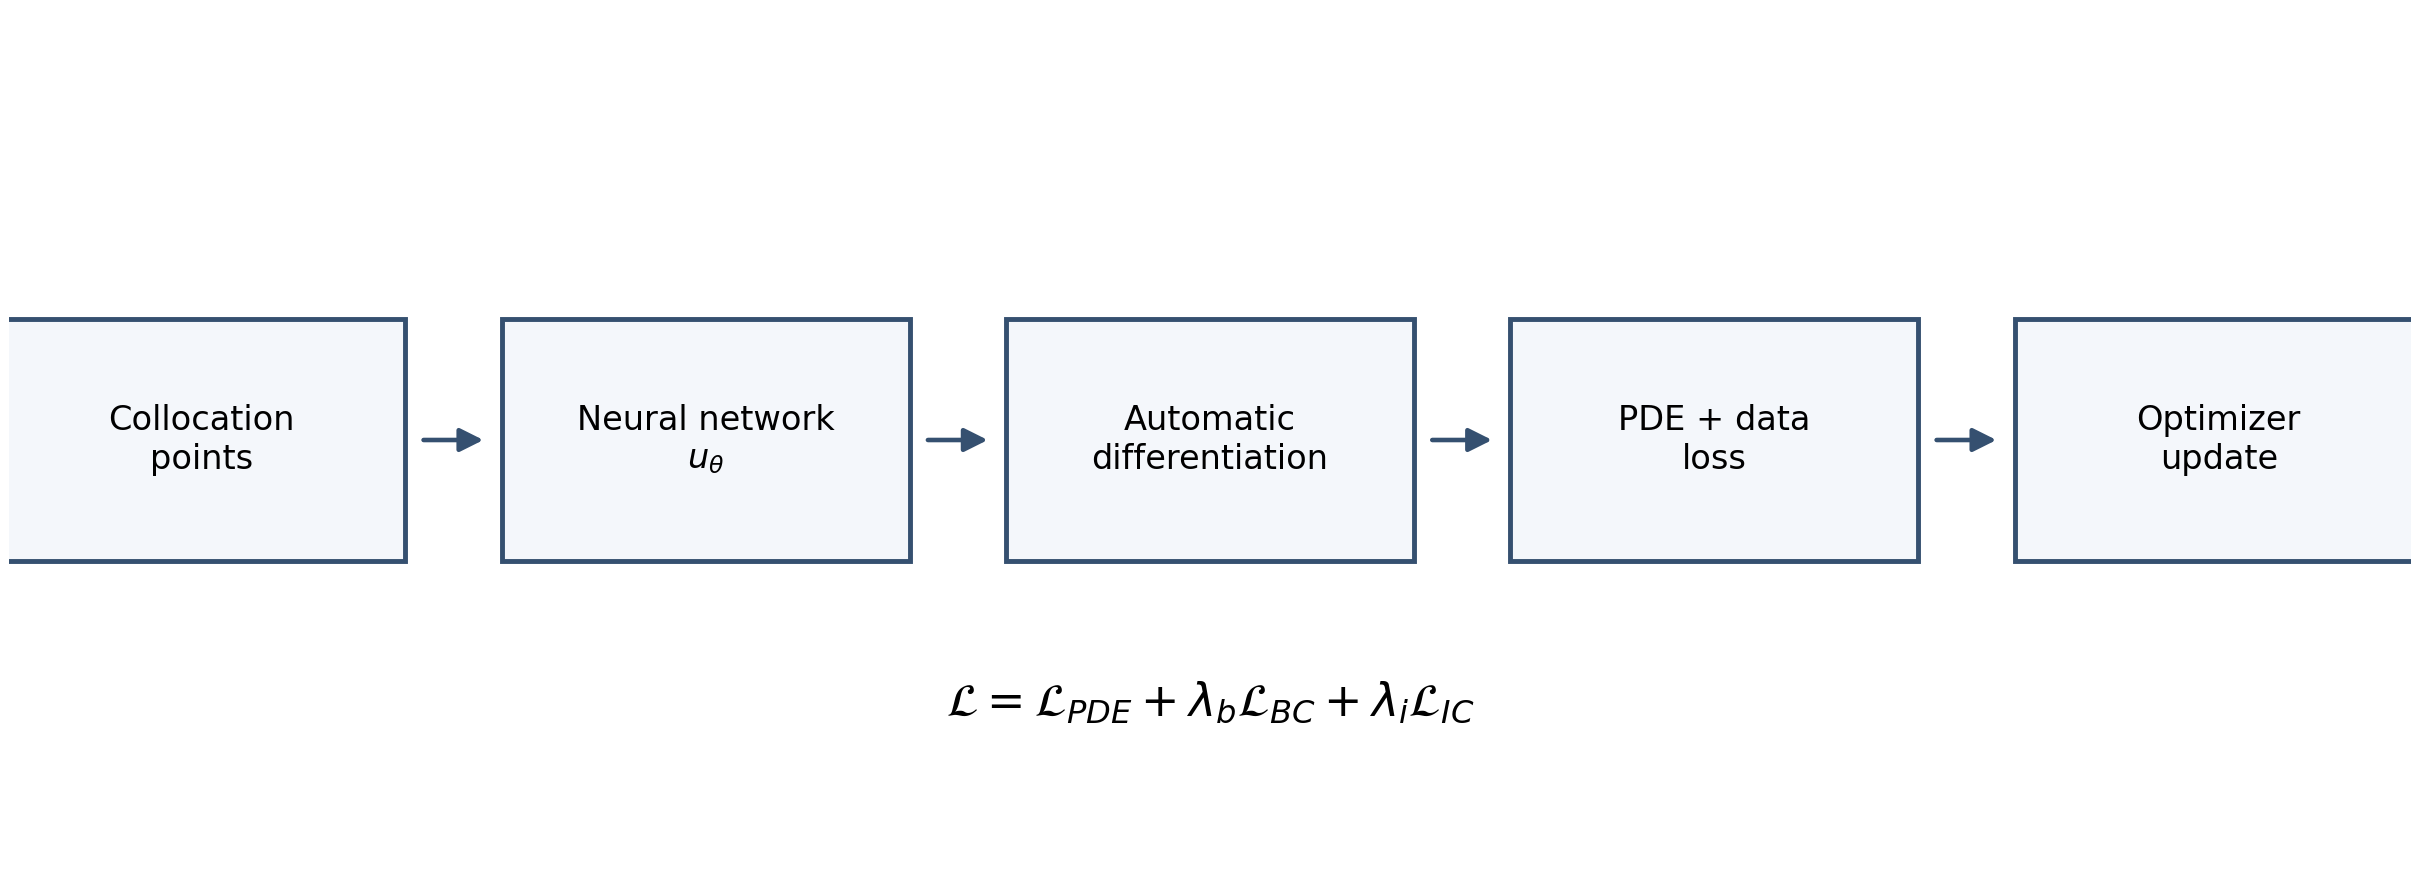

report_figures/bloch_sphere.png


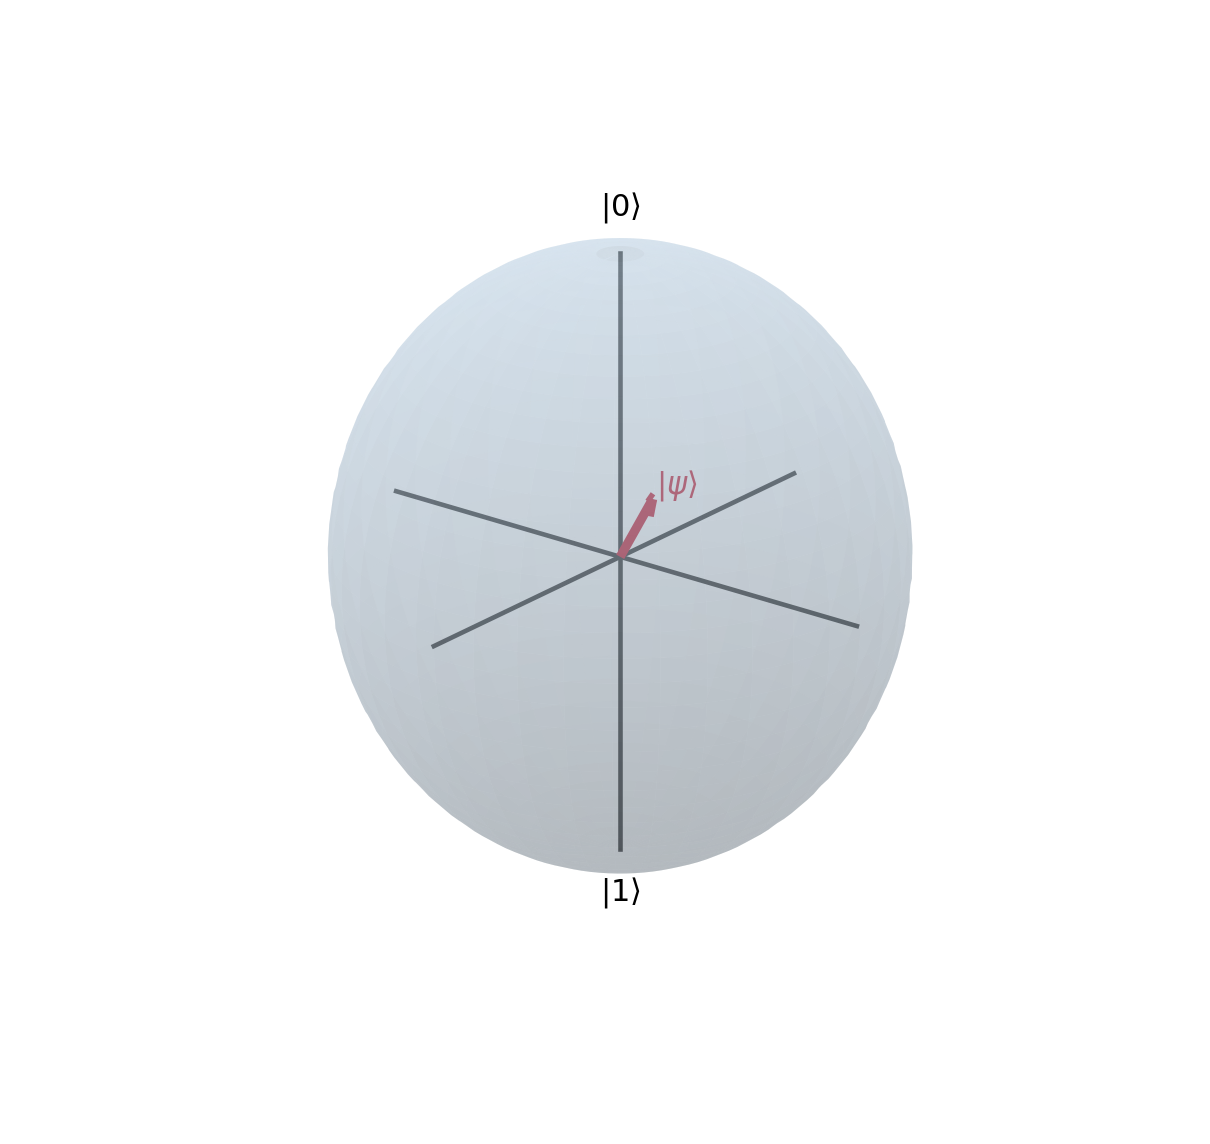

report_figures/qapinn_circuit.png


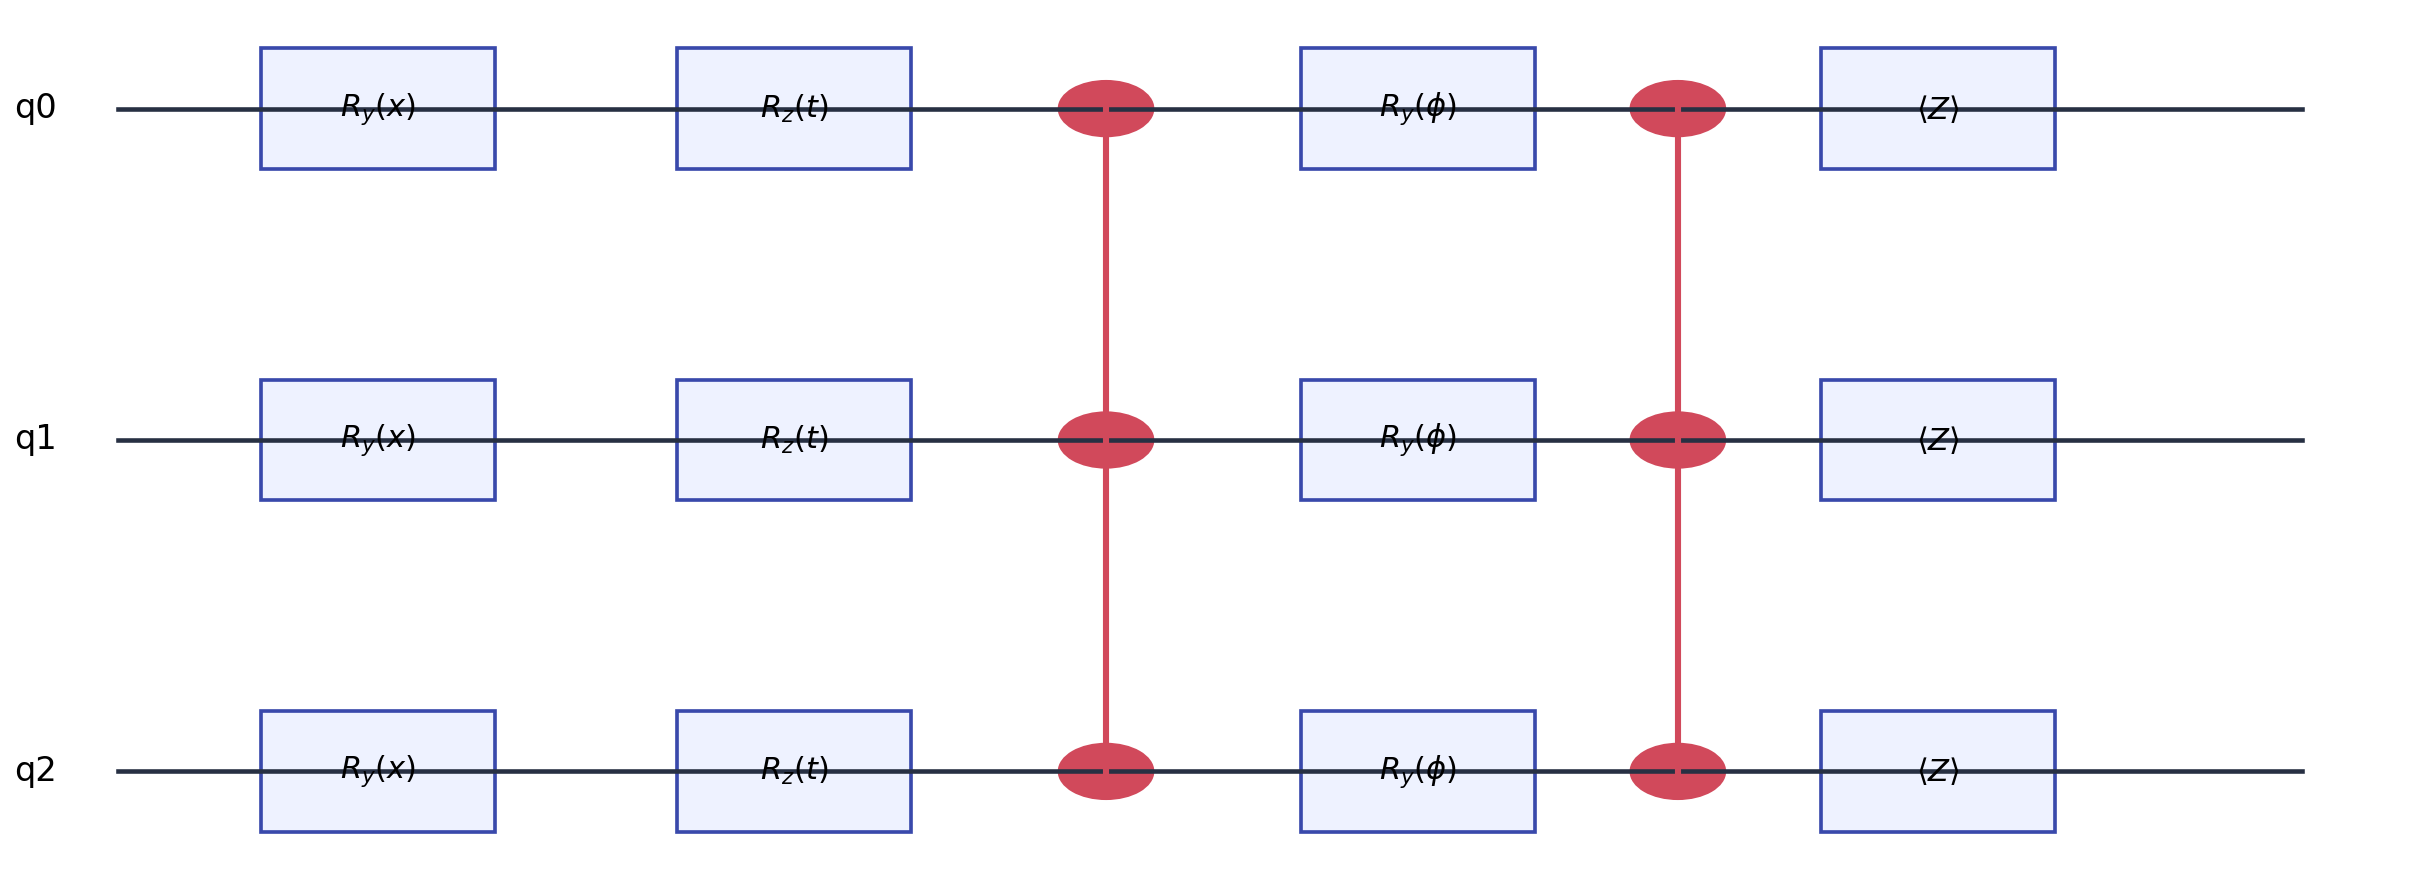

report_figures/xpinn_splits.png


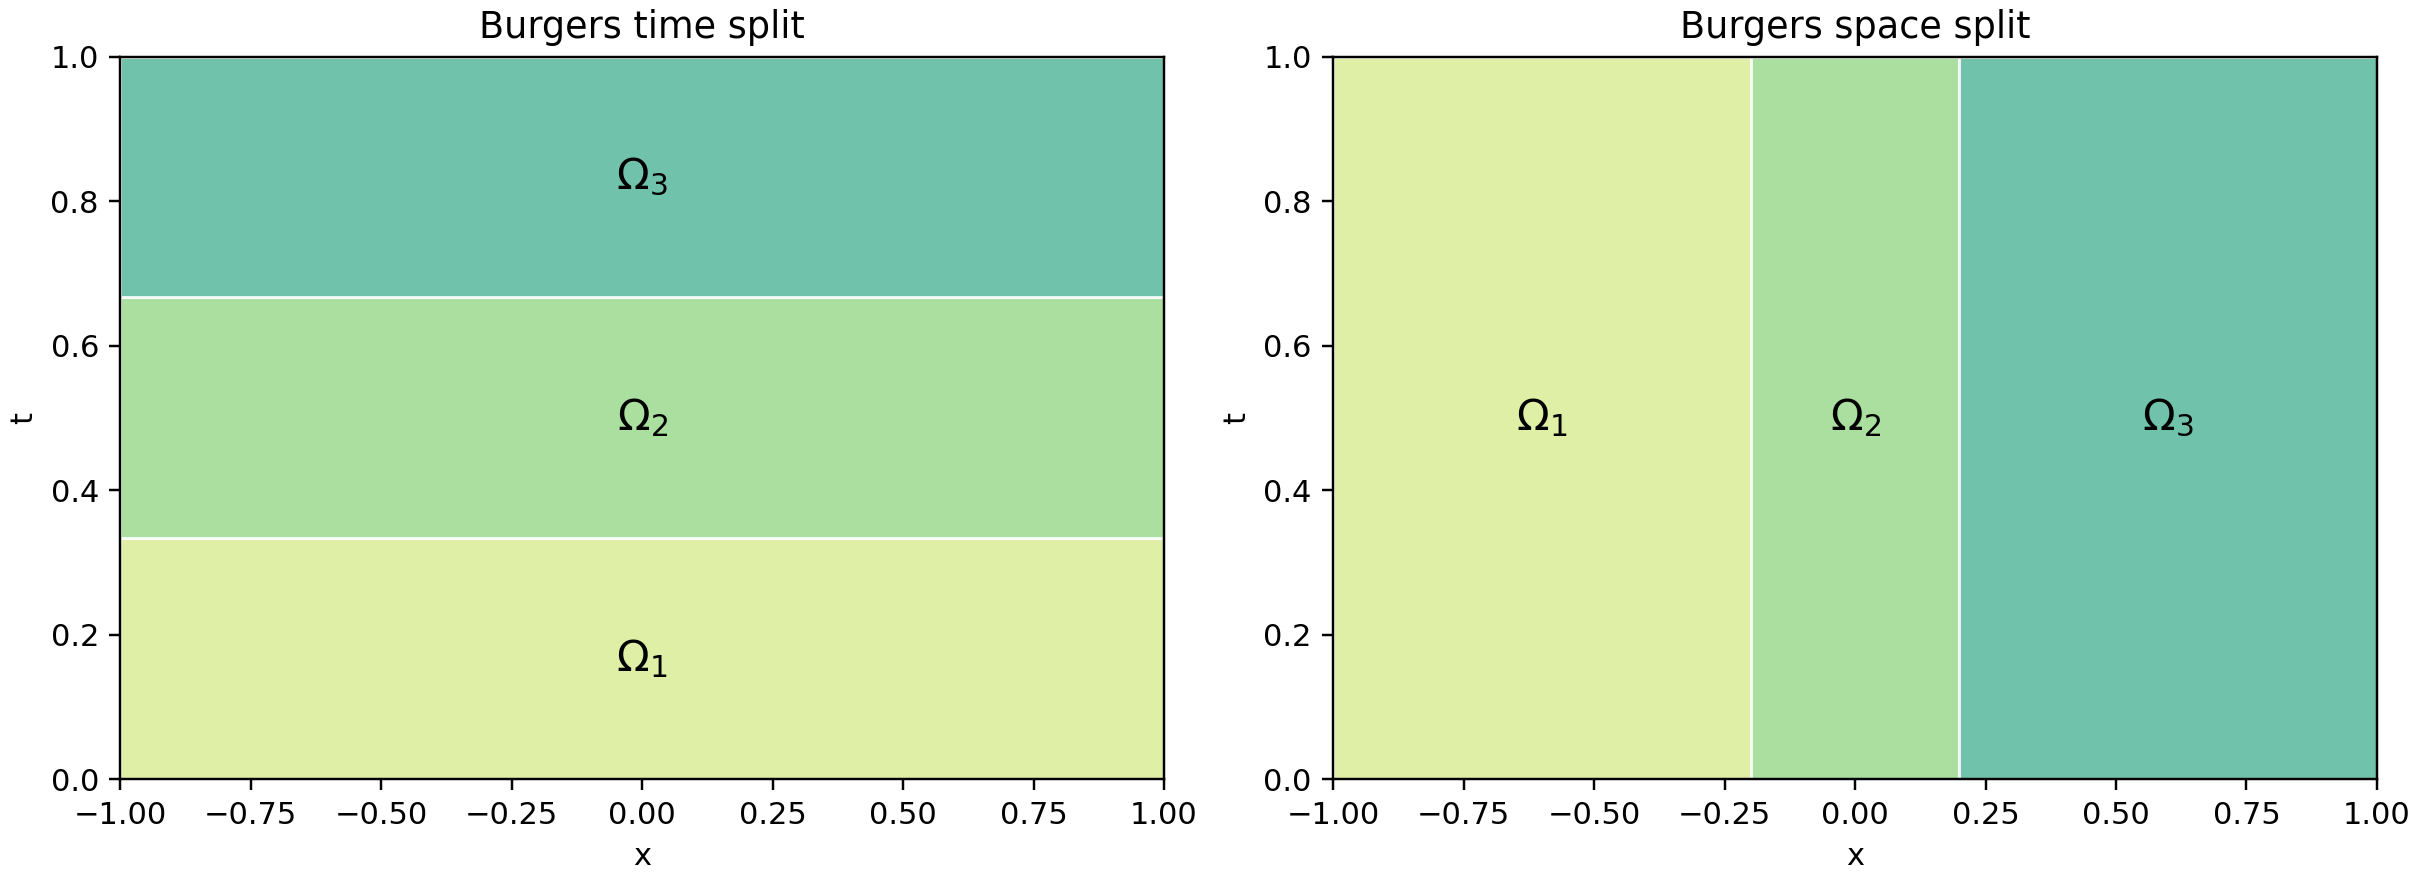

results_five/figures/time_slice_comparison.png


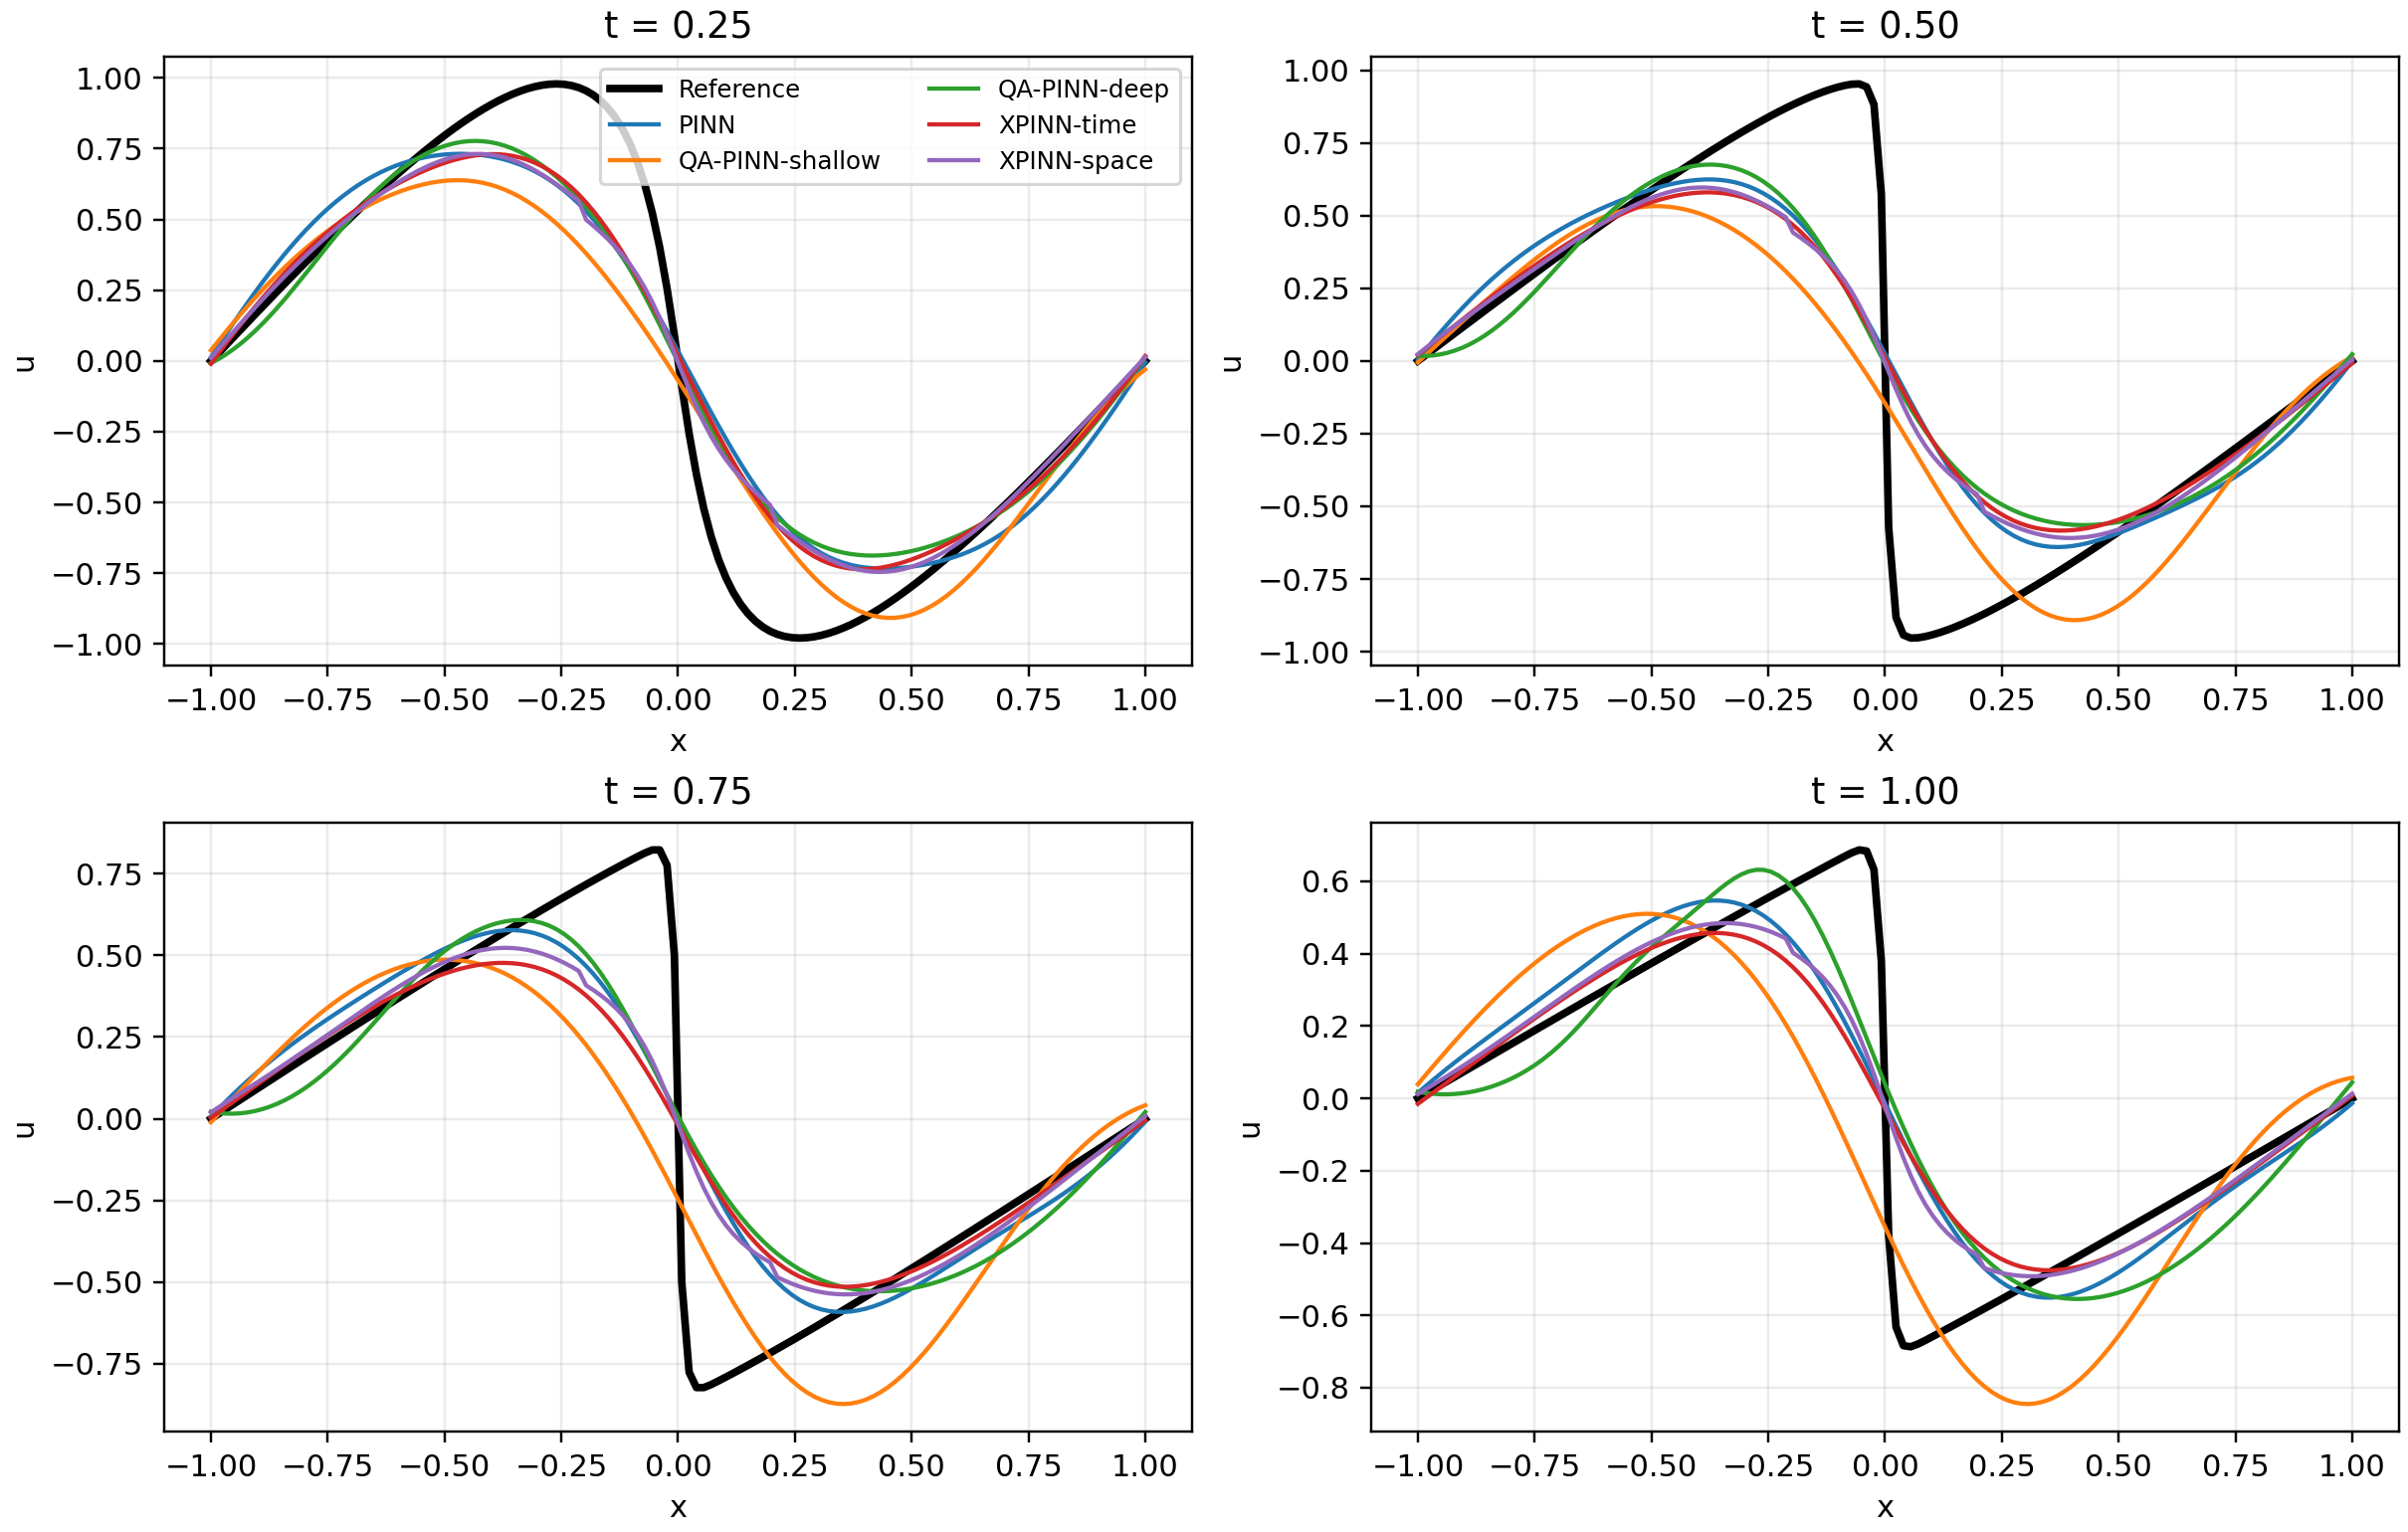

results_five/figures/pinn_field_error.png


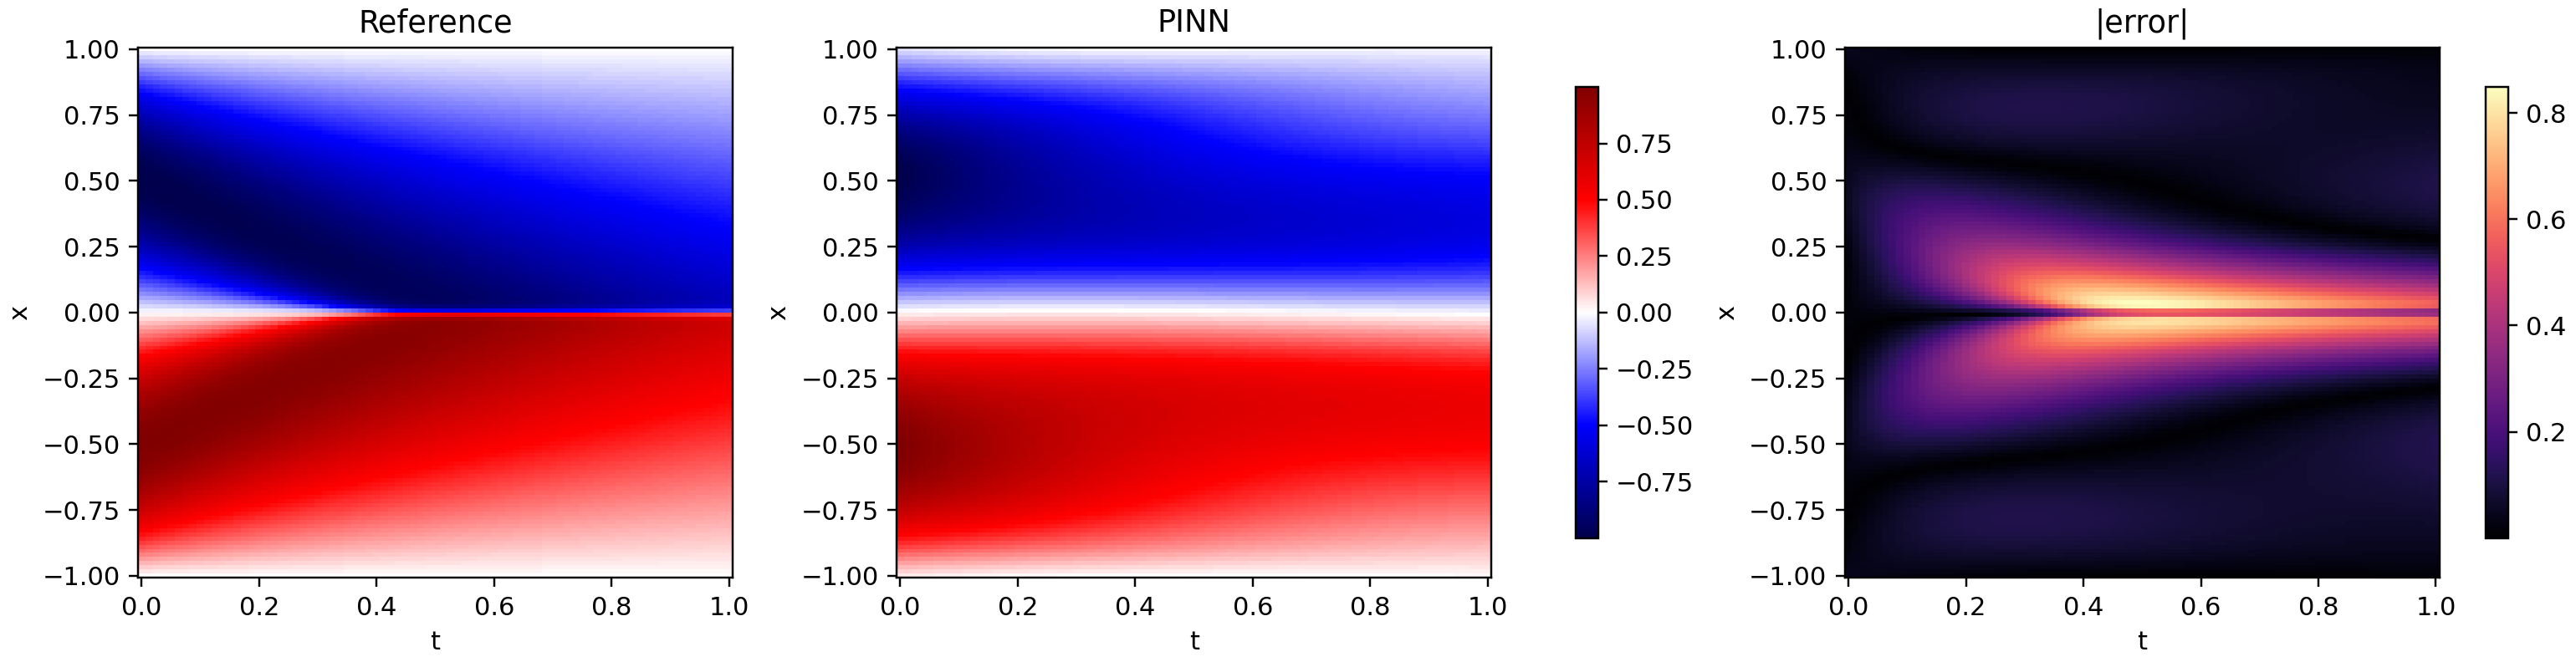

results_five/figures/qa-pinn-shallow_field_error.png


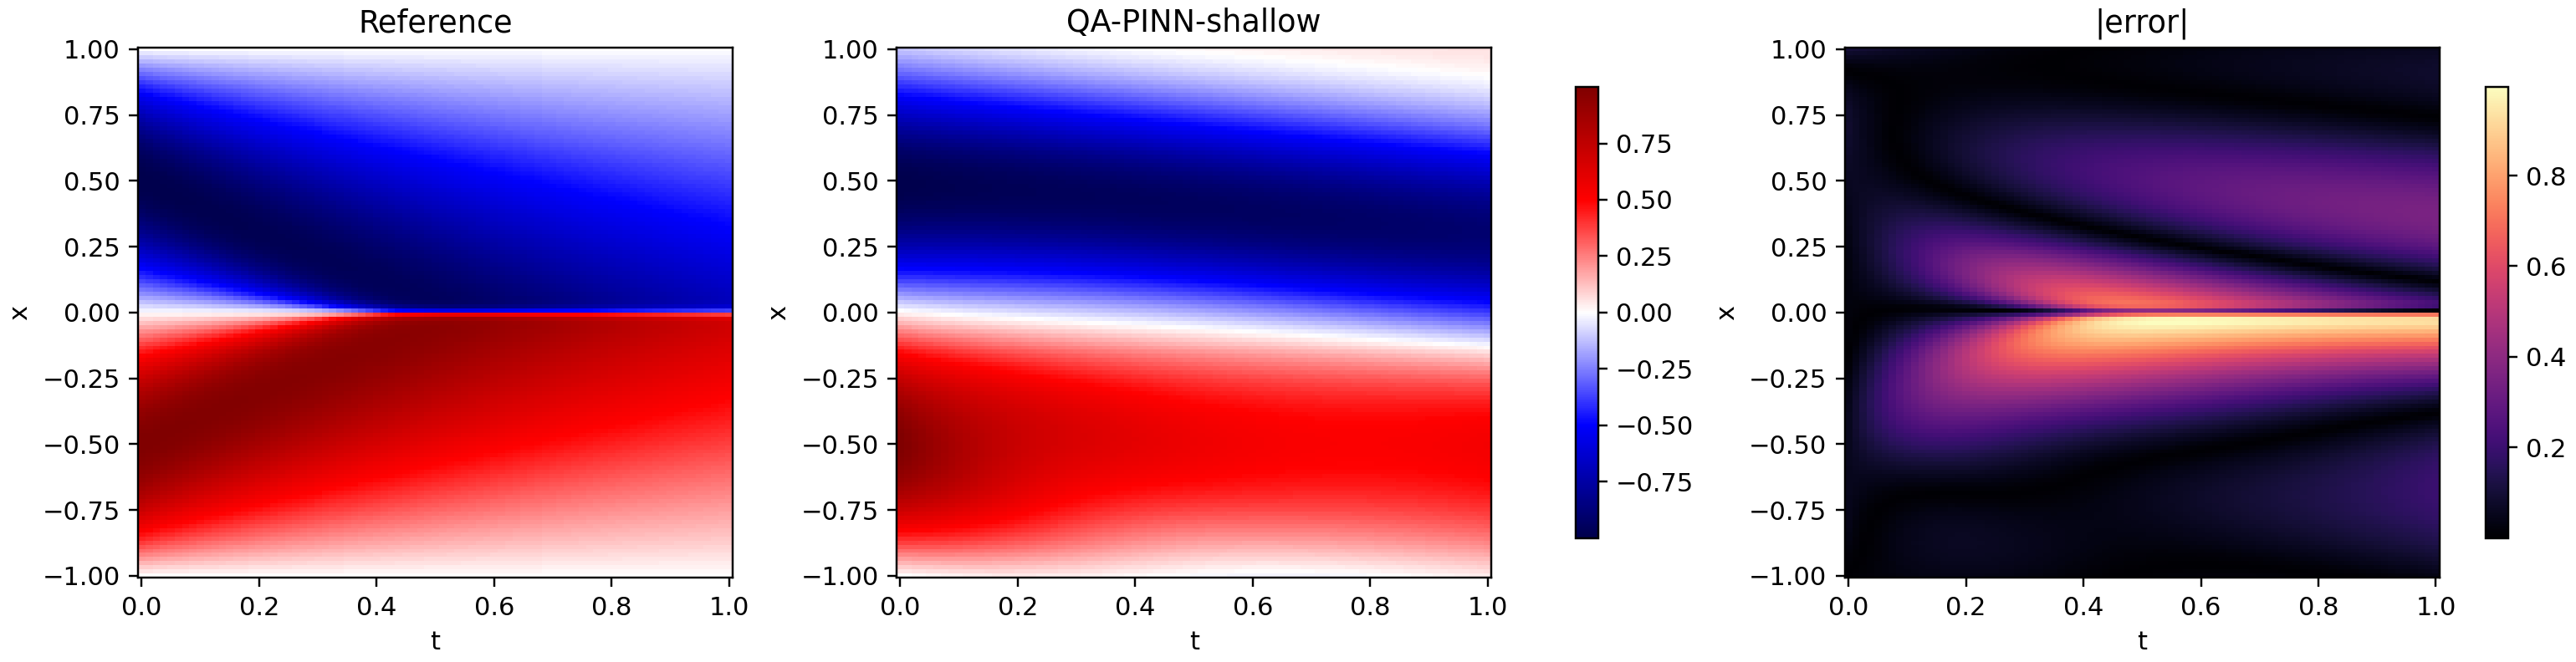

results_five/figures/qa-pinn-deep_field_error.png


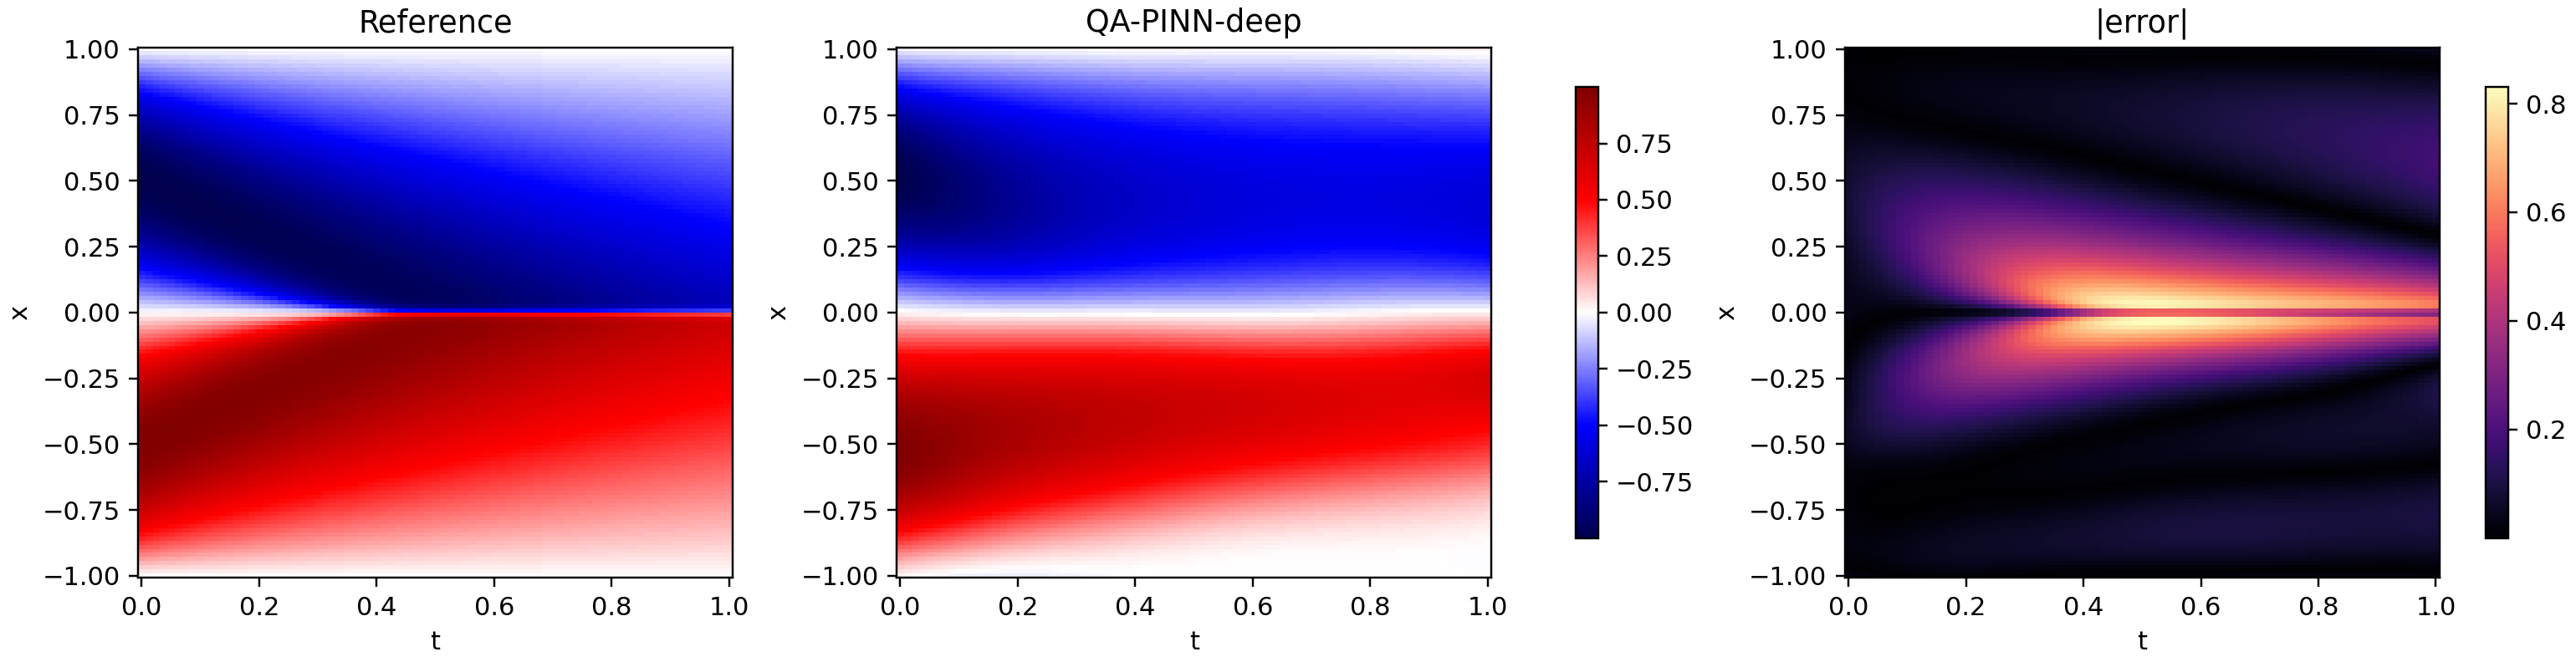

results_five/figures/xpinn-time_field_error.png


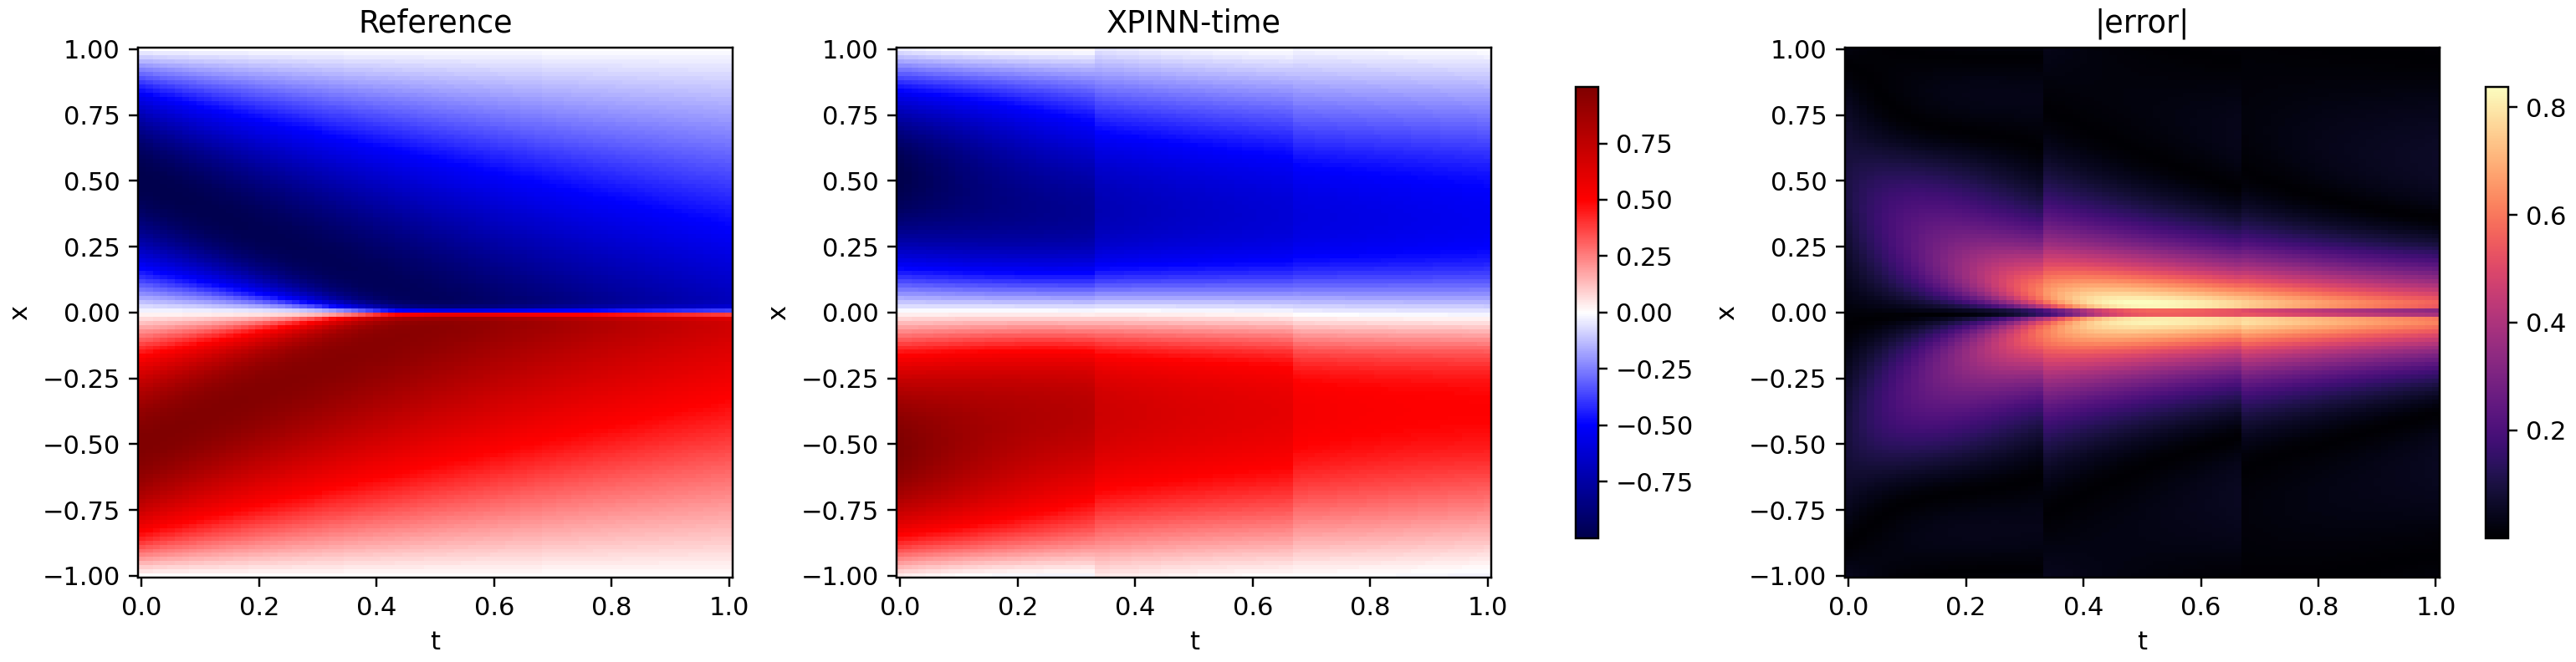

results_five/figures/xpinn-space_field_error.png


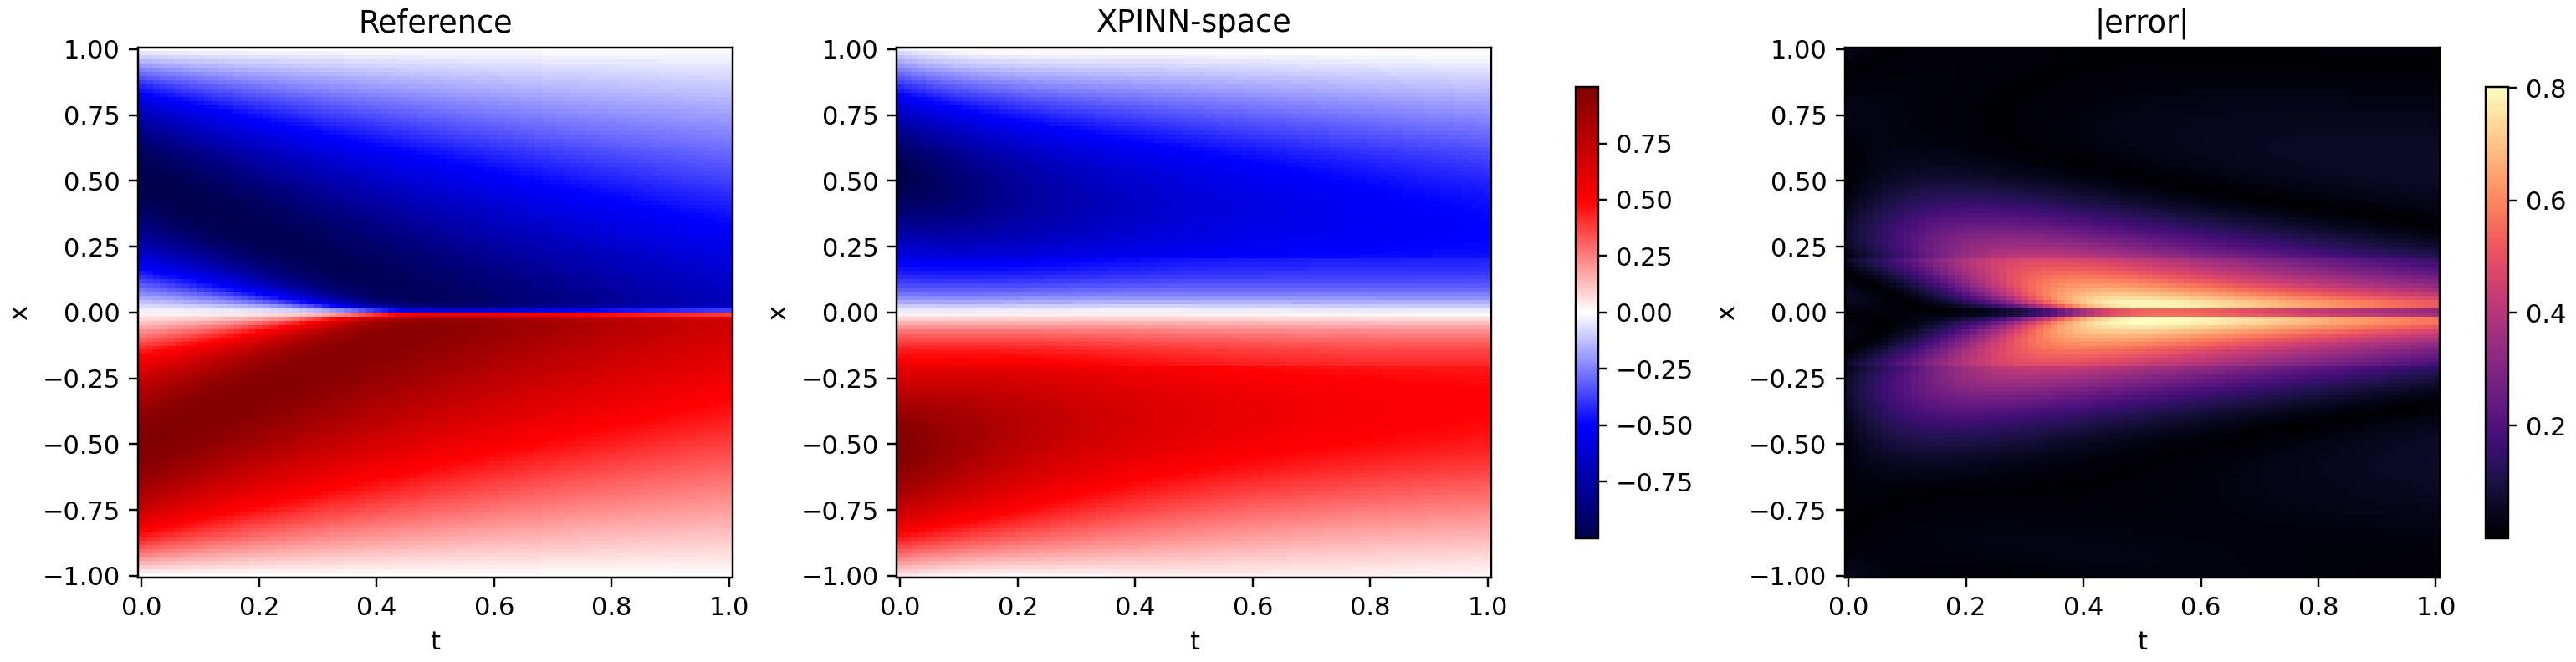

results_five/figures/prediction_montage.png


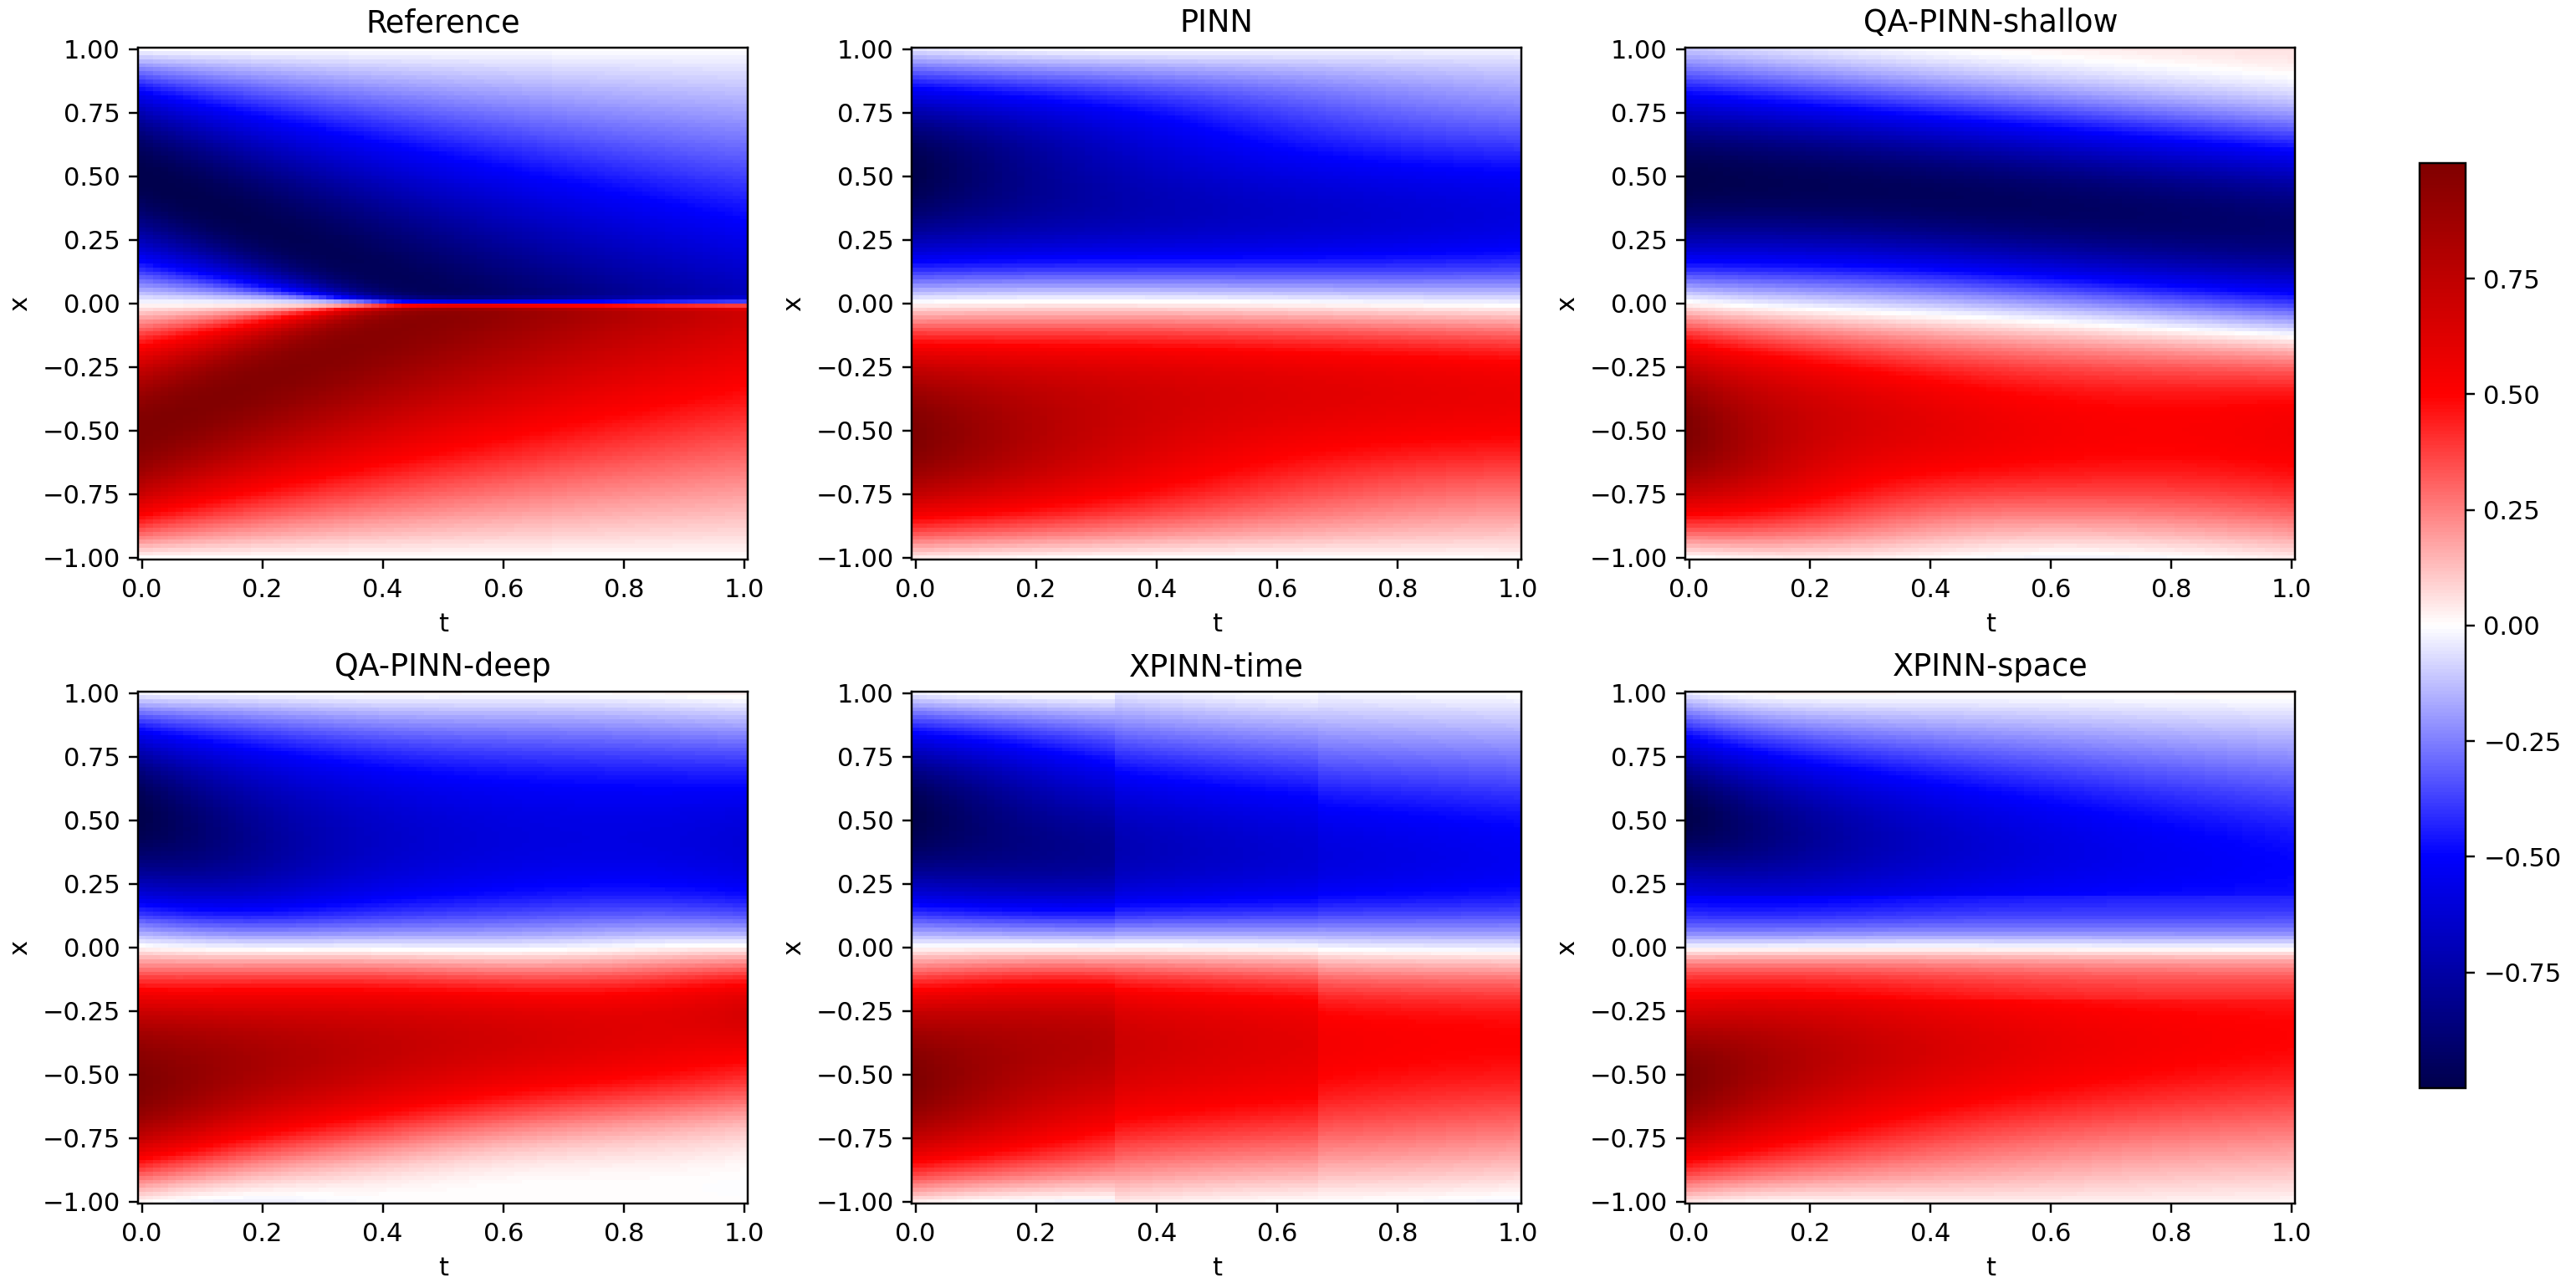

results_five/figures/loss_comparison.png


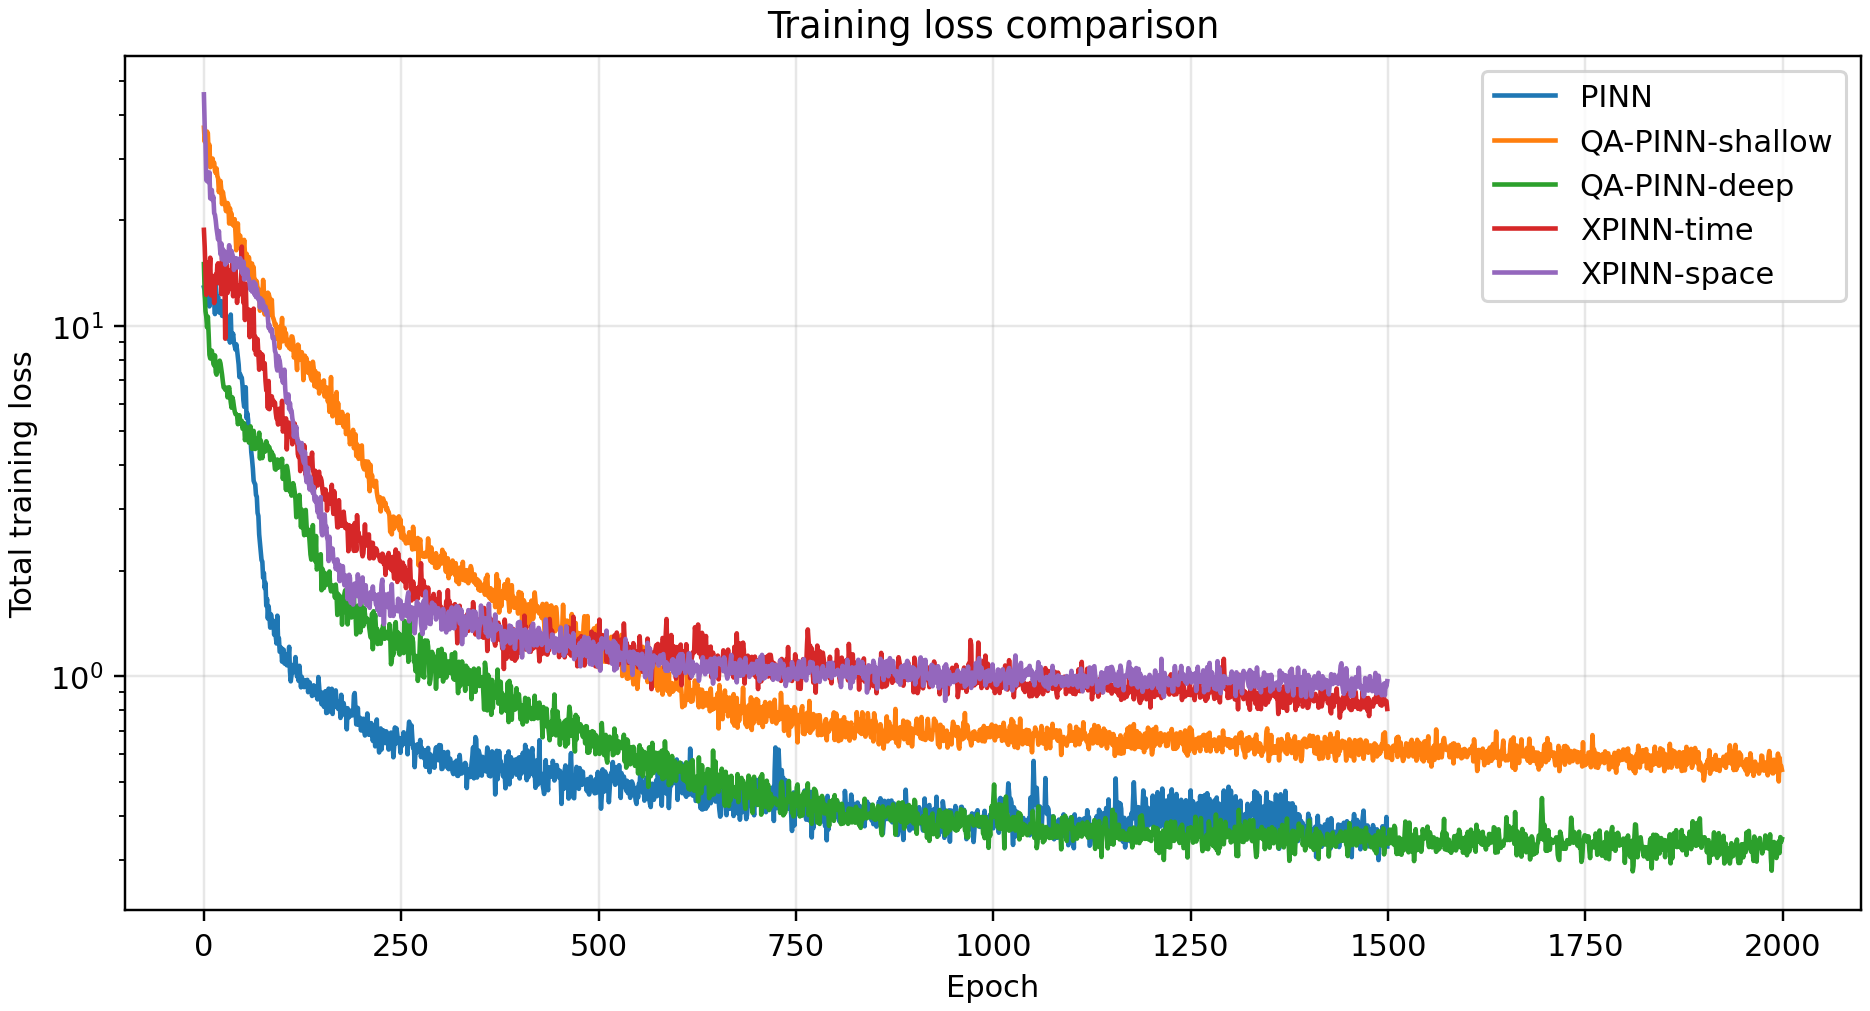

results_five/figures/all_error_metrics_bar.png


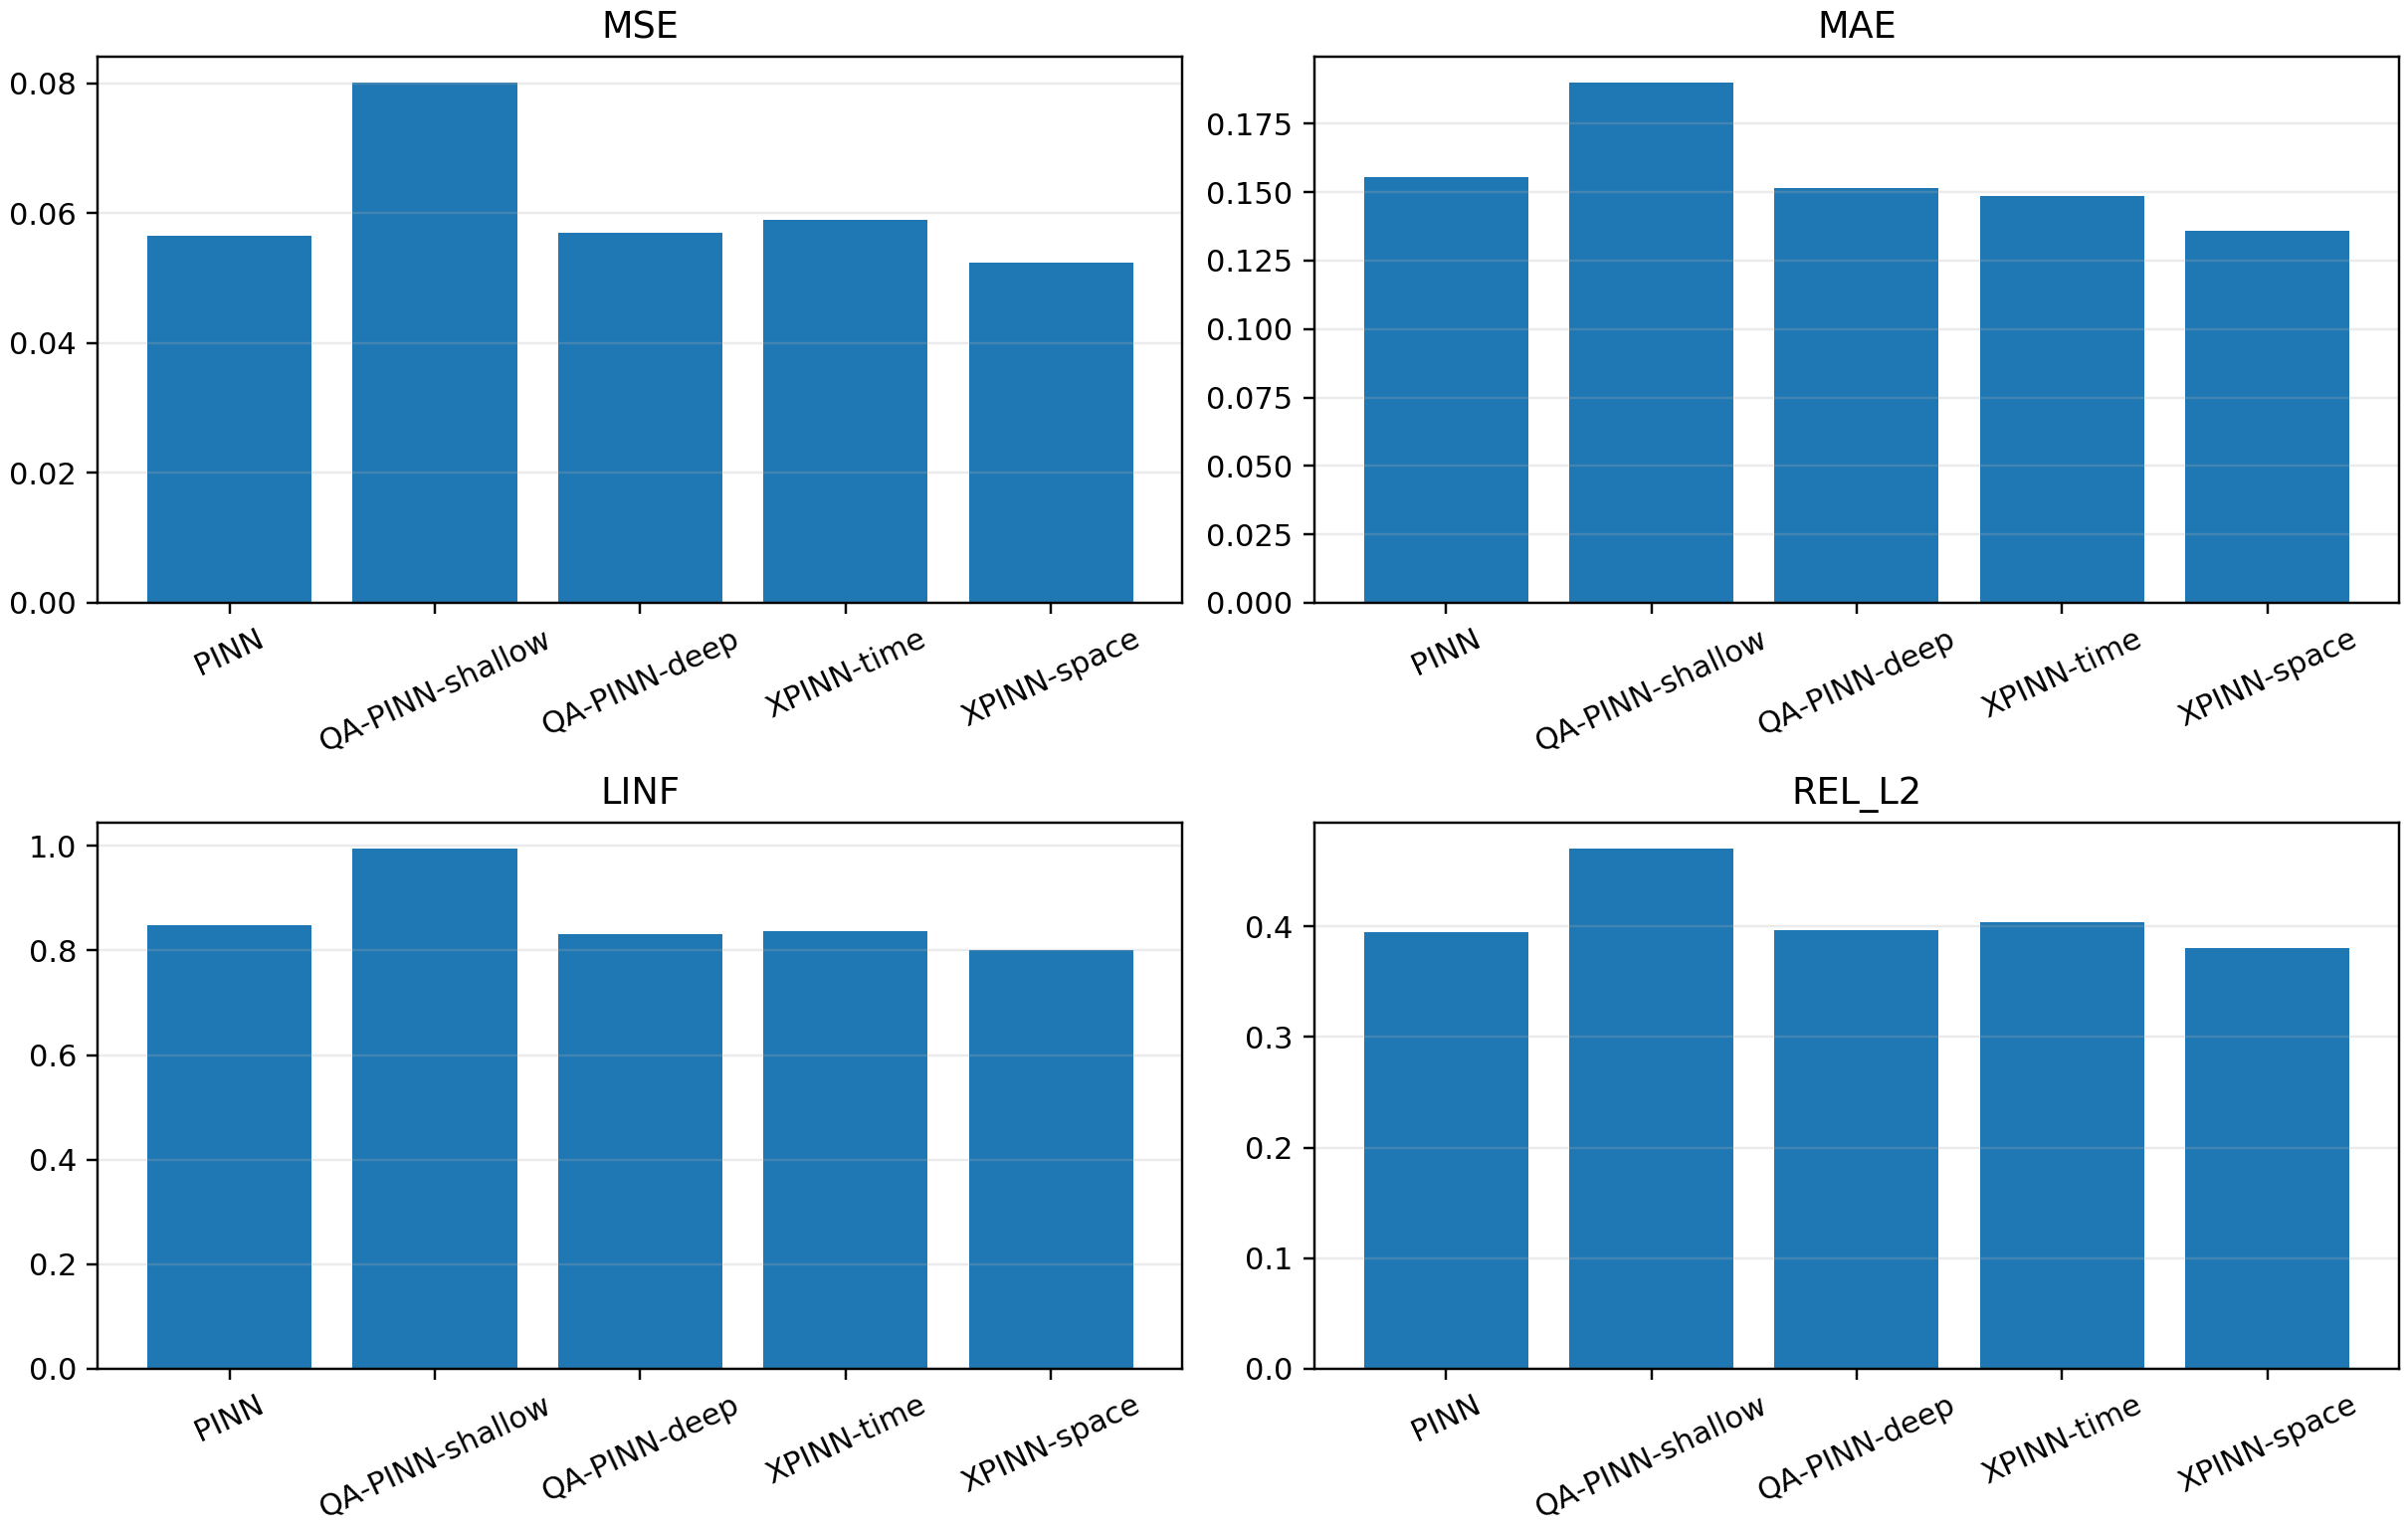

results_five/figures/mse_vs_time.png


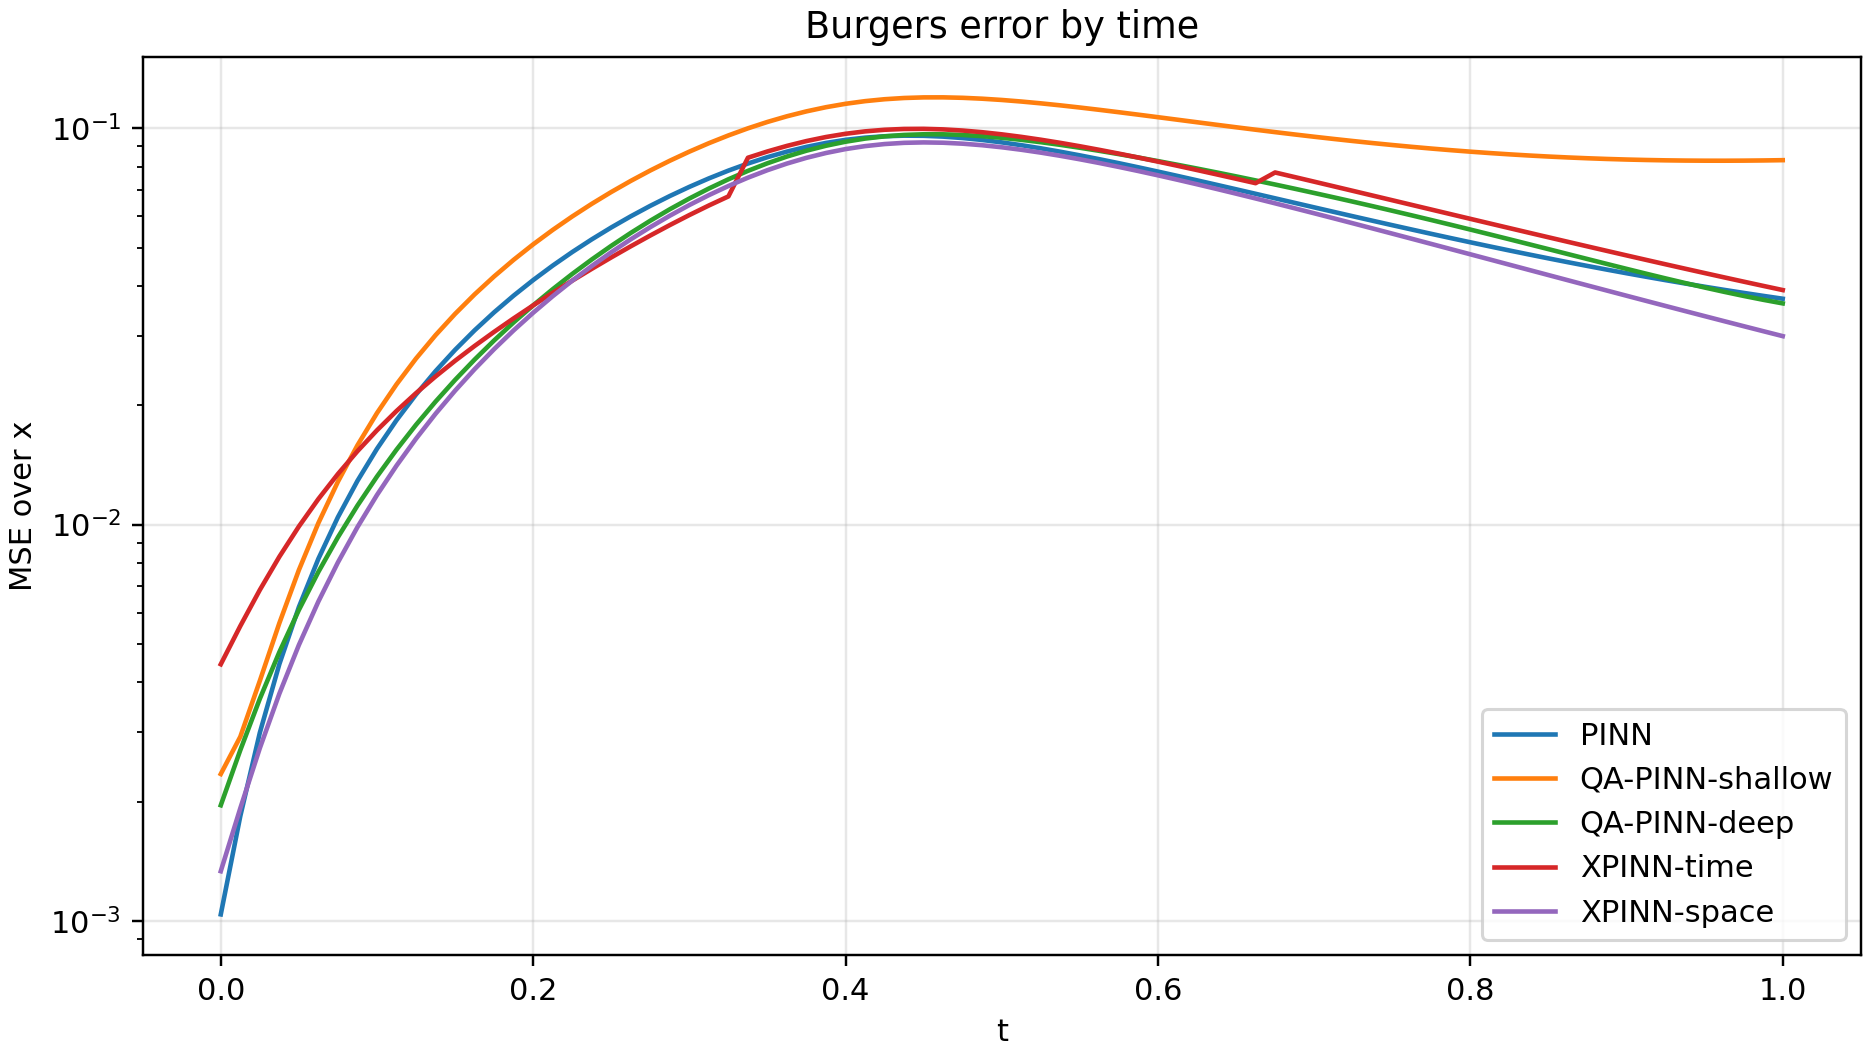

results_five/figures/cost_comparison.png


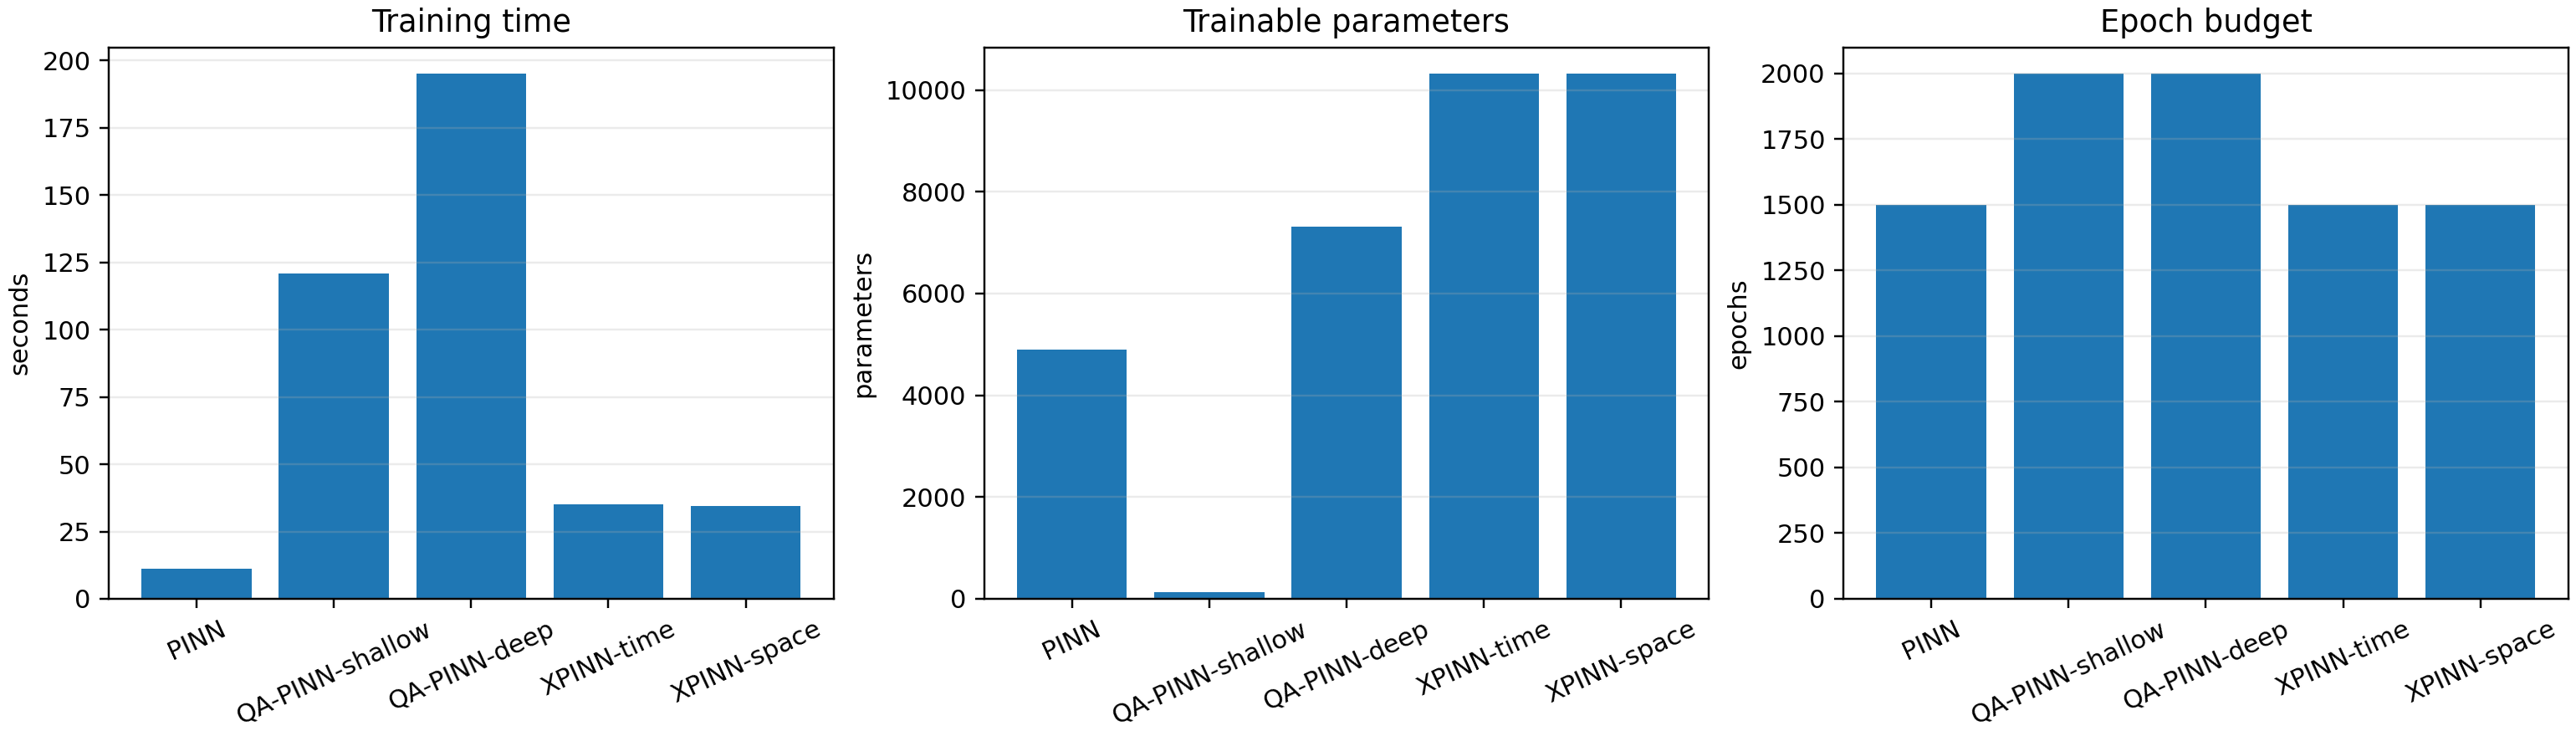

results_five/figures/relative_l2_bar.png


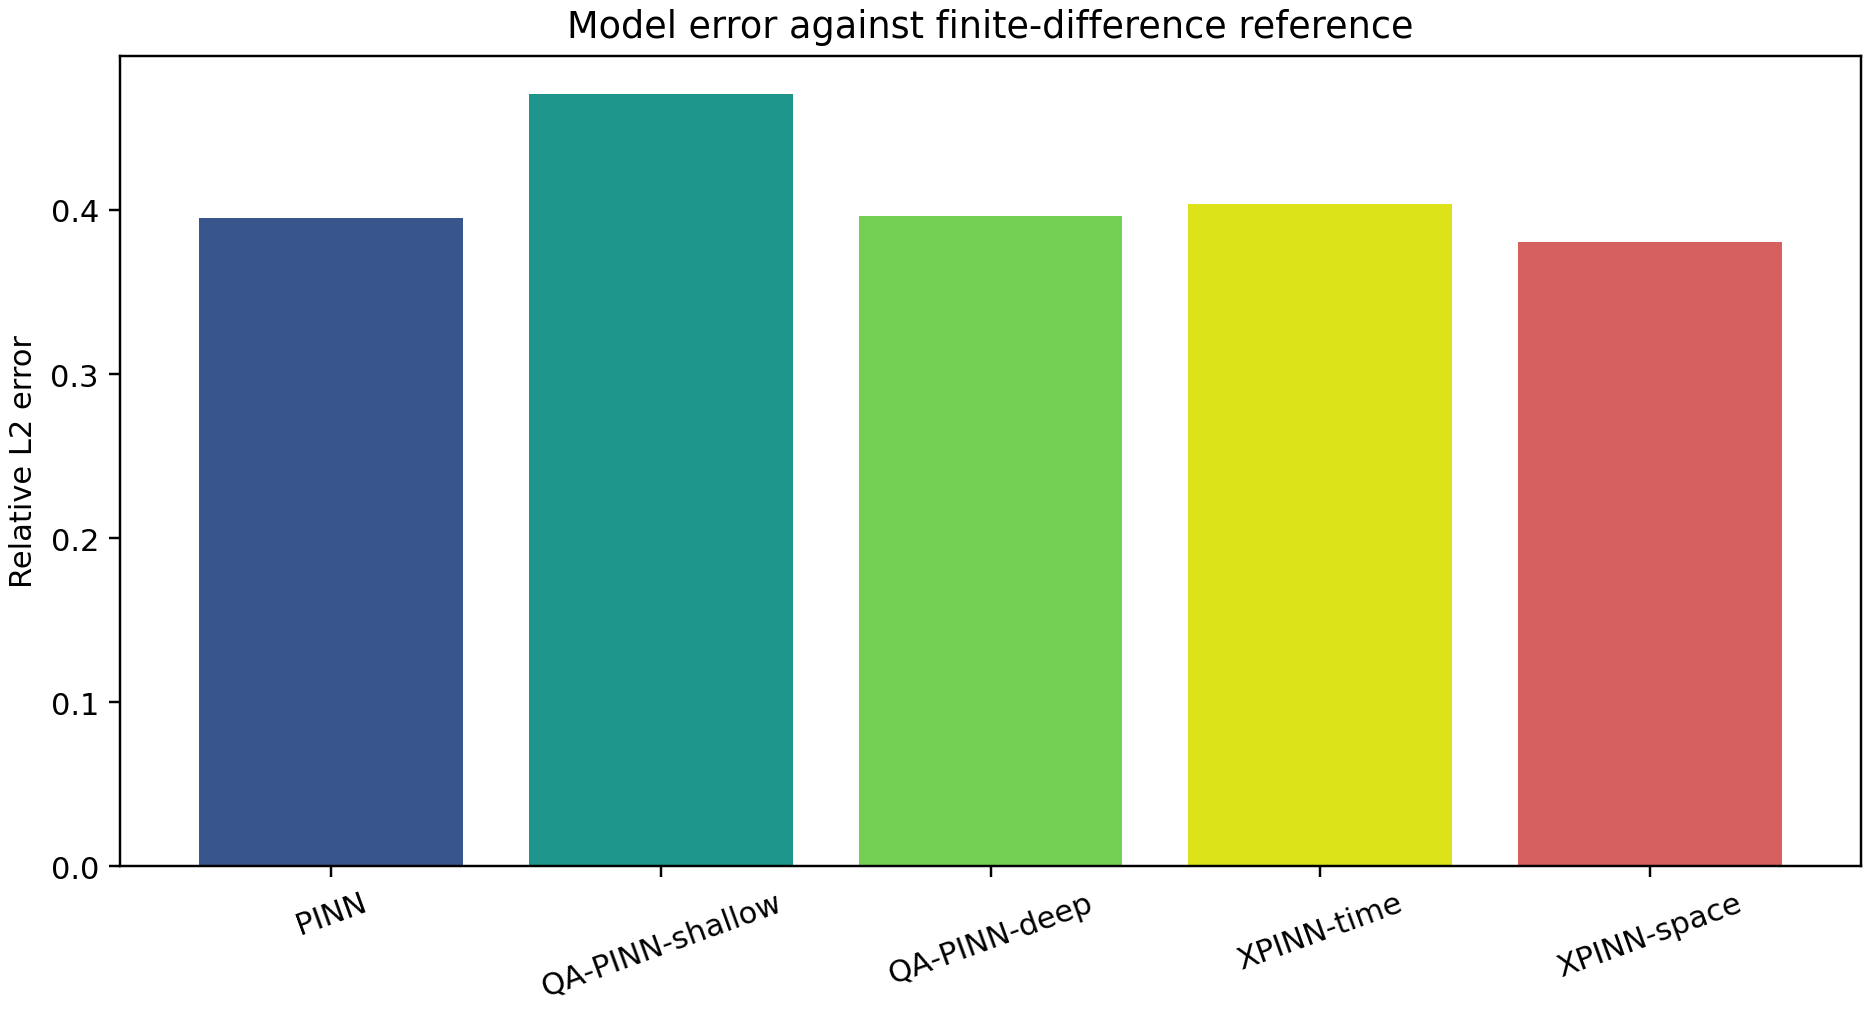

results_five/figures/summary_table.png


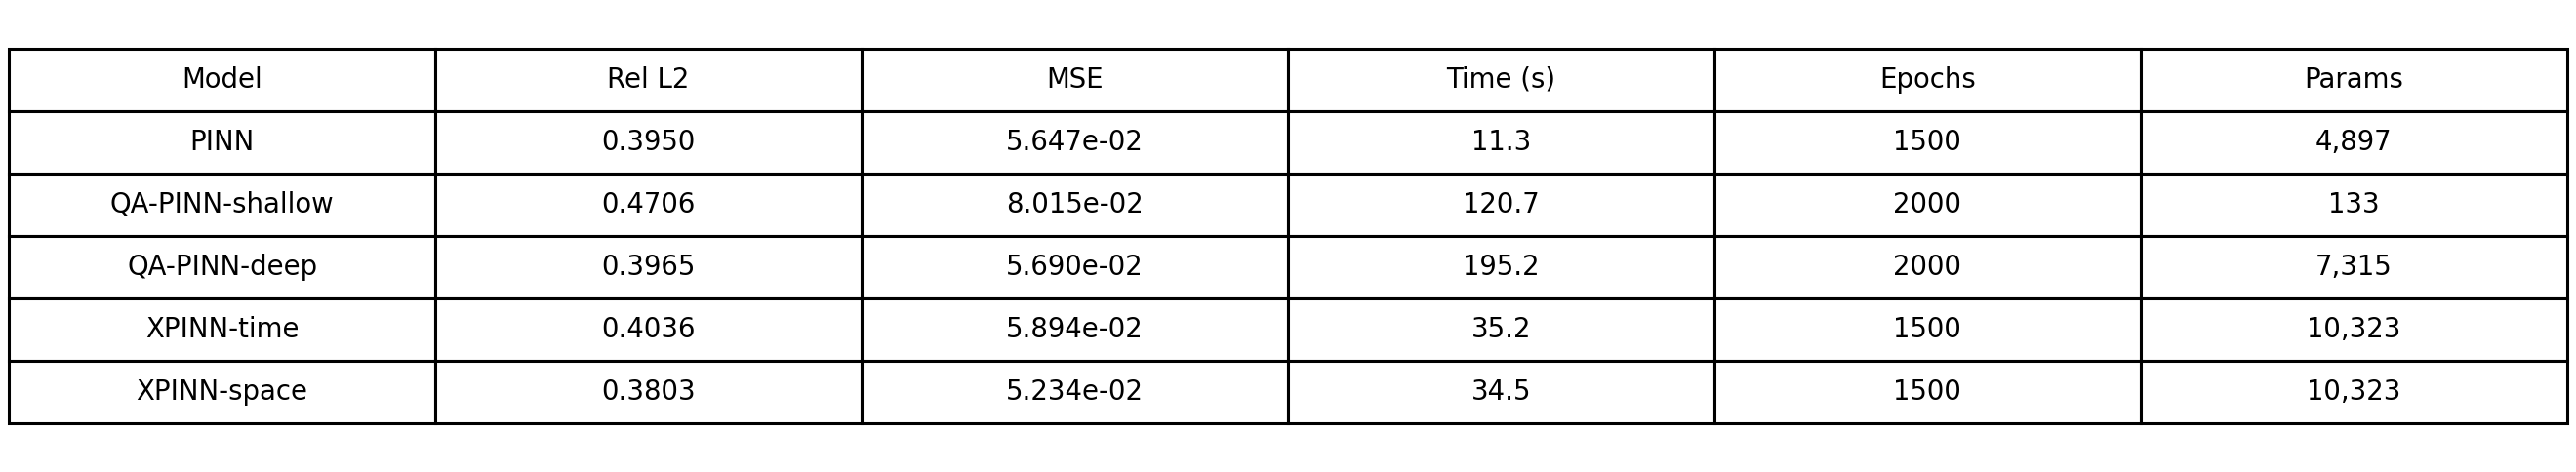

poisson_results_five/figures/prediction_montage.png


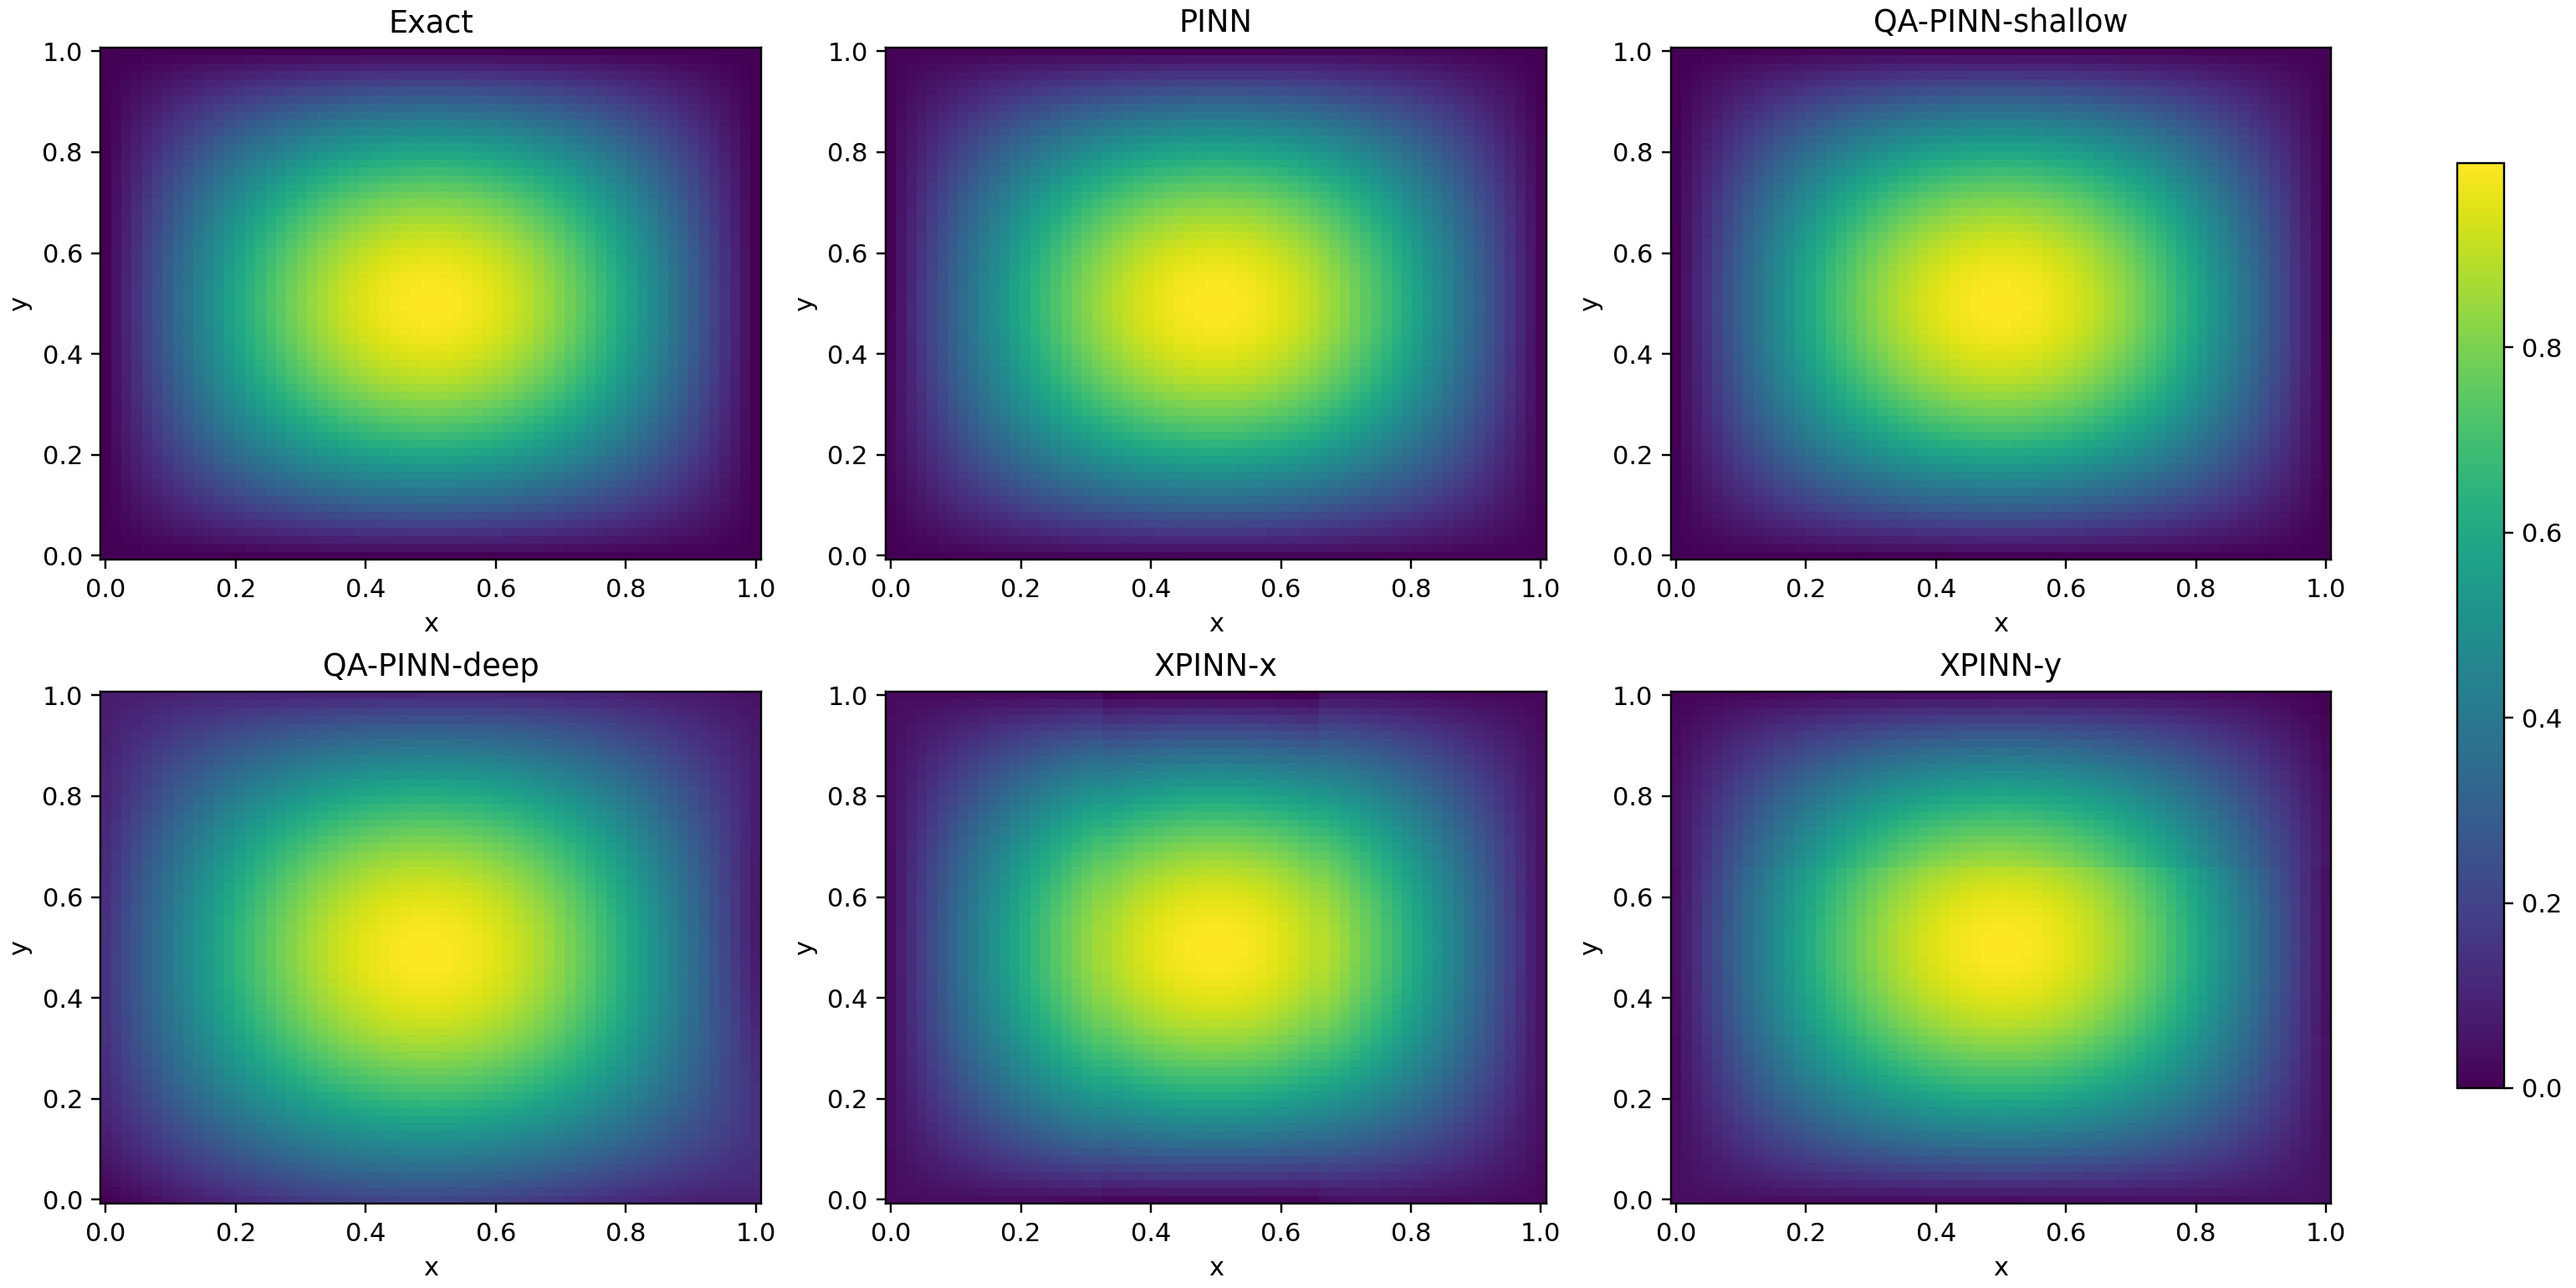

poisson_results_five/figures/qa_pinn_shallow_field_error.png


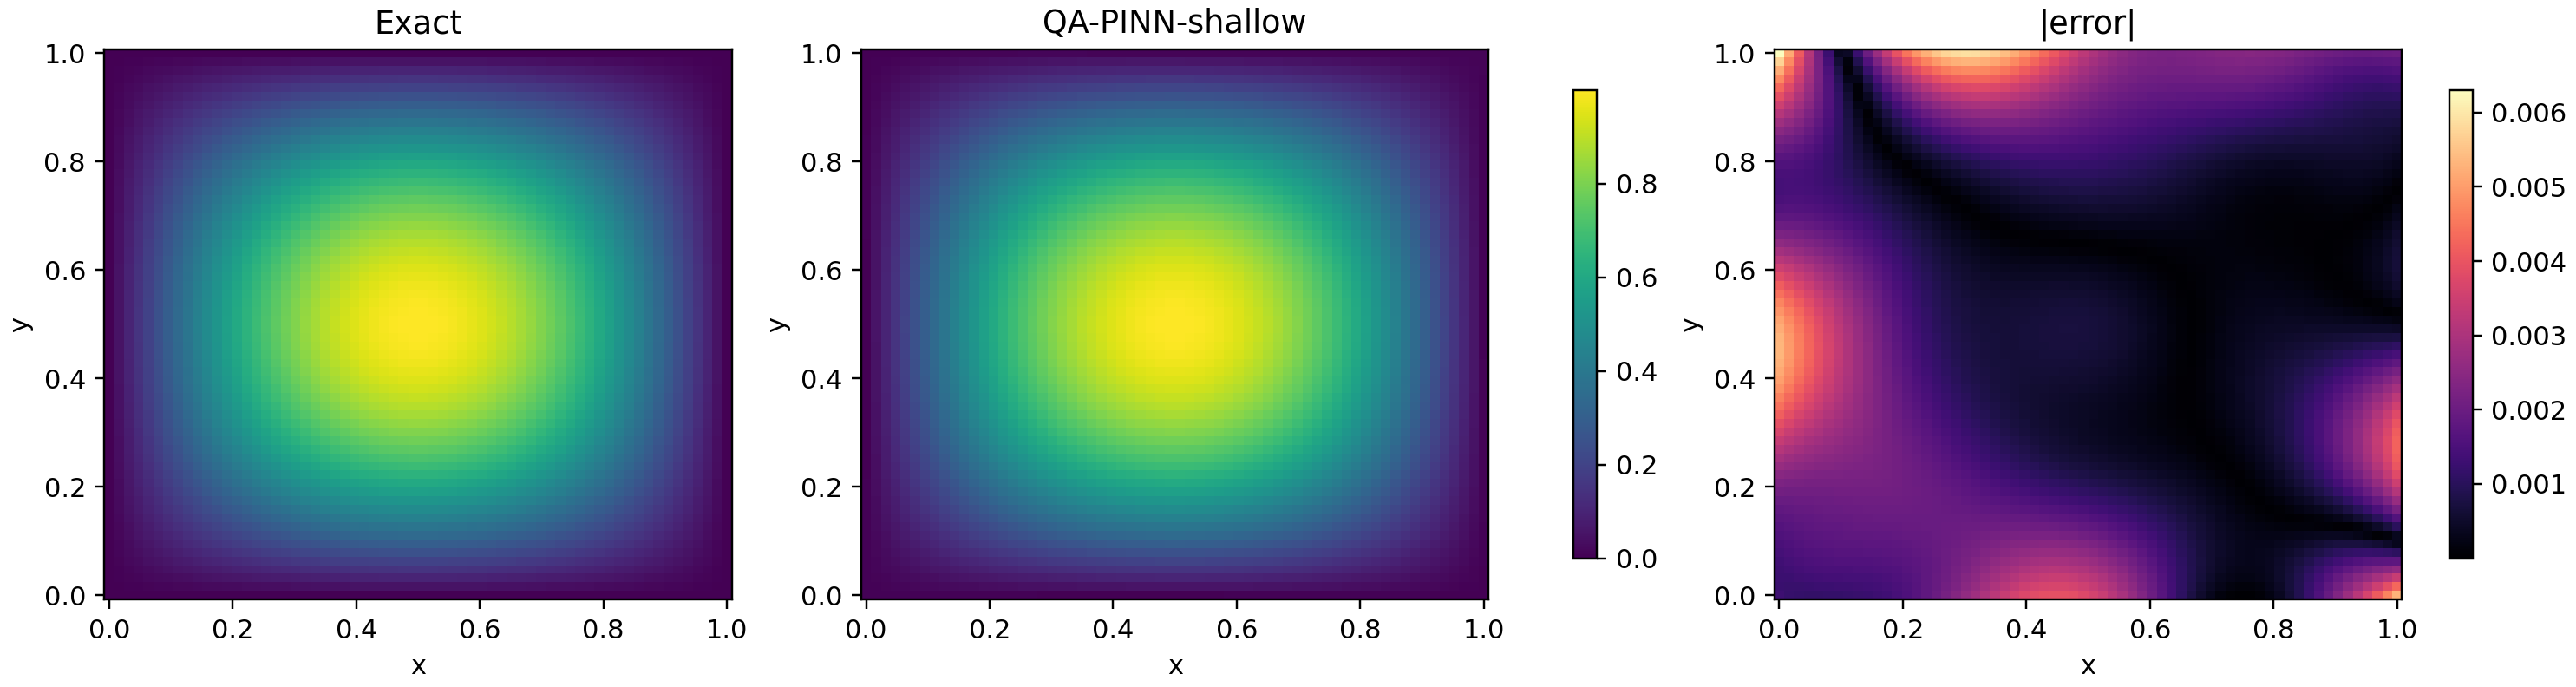

poisson_results_five/figures/pinn_field_error.png


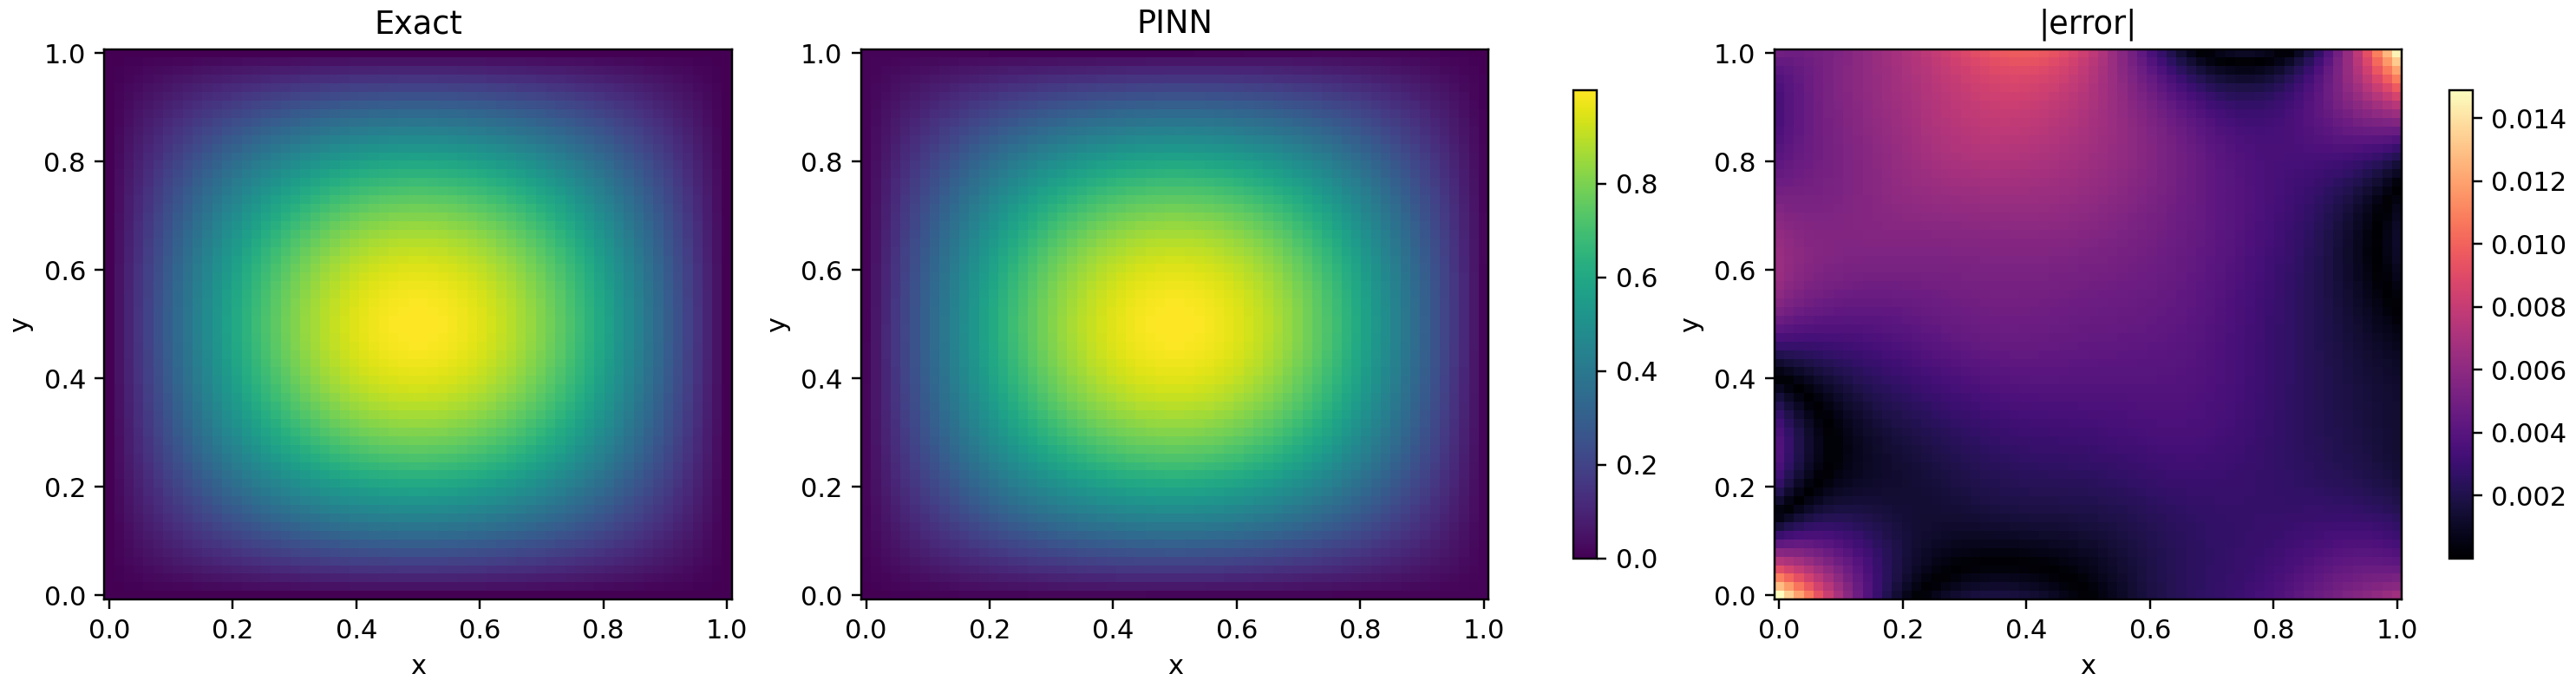

poisson_results_five/figures/loss_comparison.png


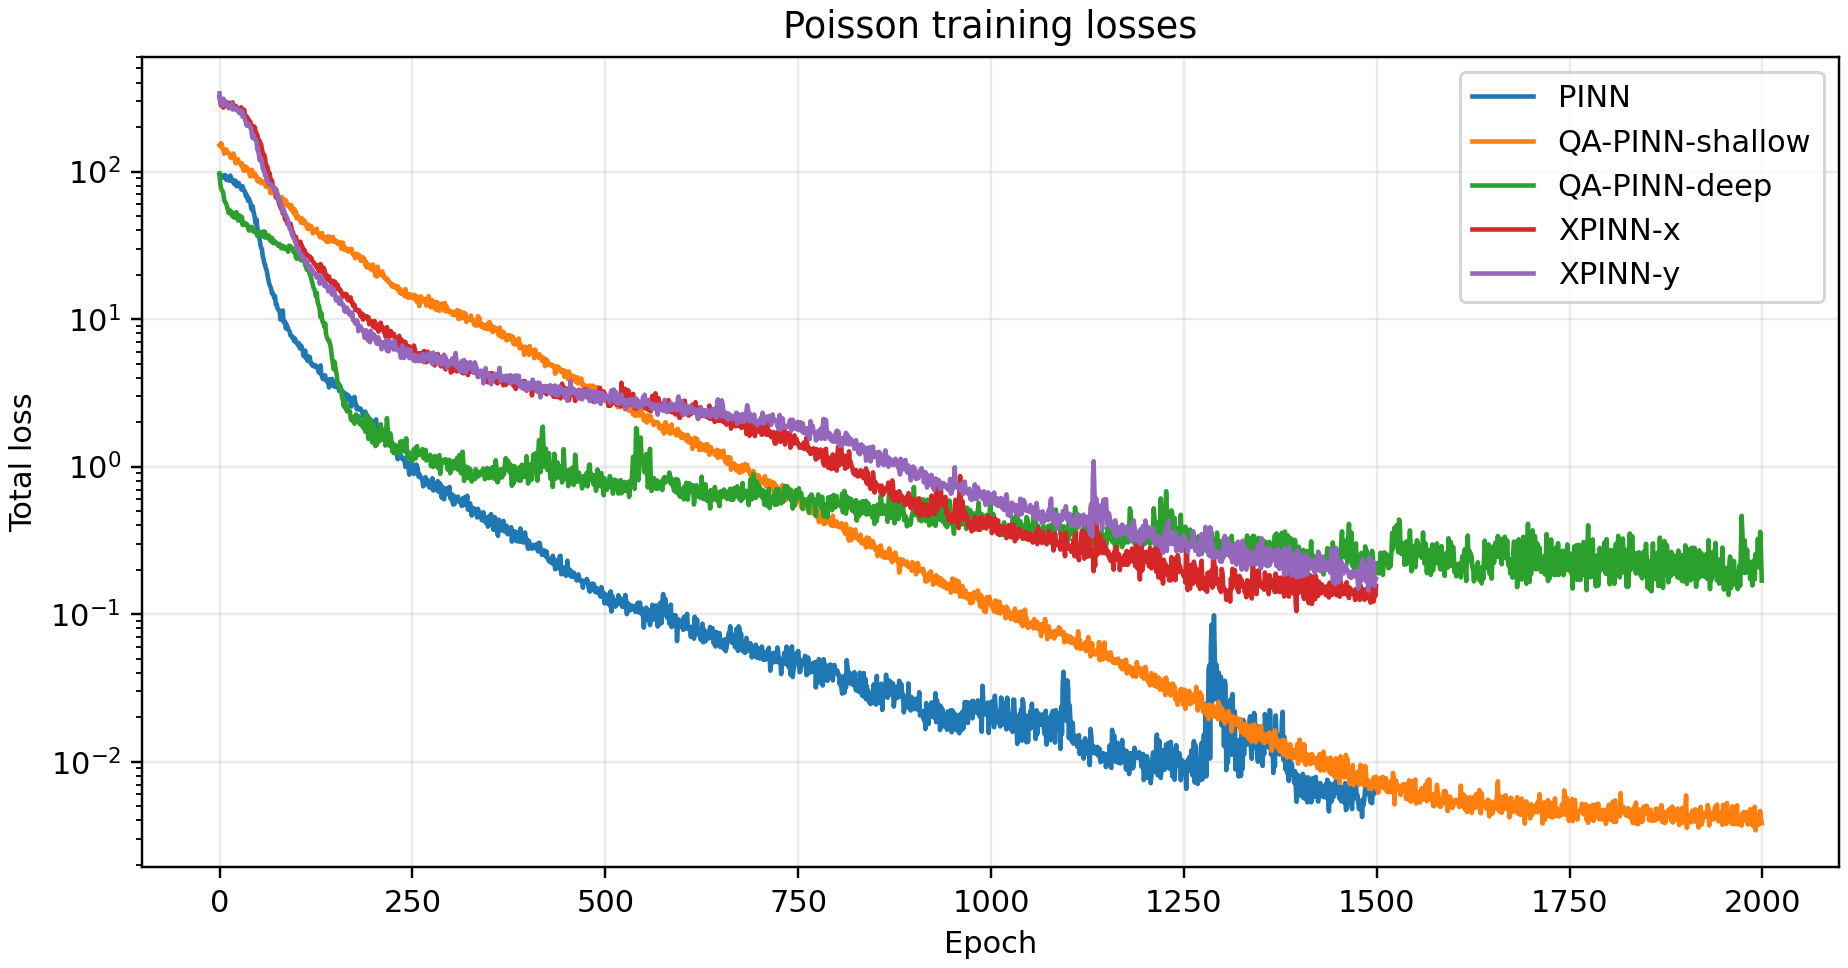

poisson_results_five/figures/all_error_metrics_bar.png


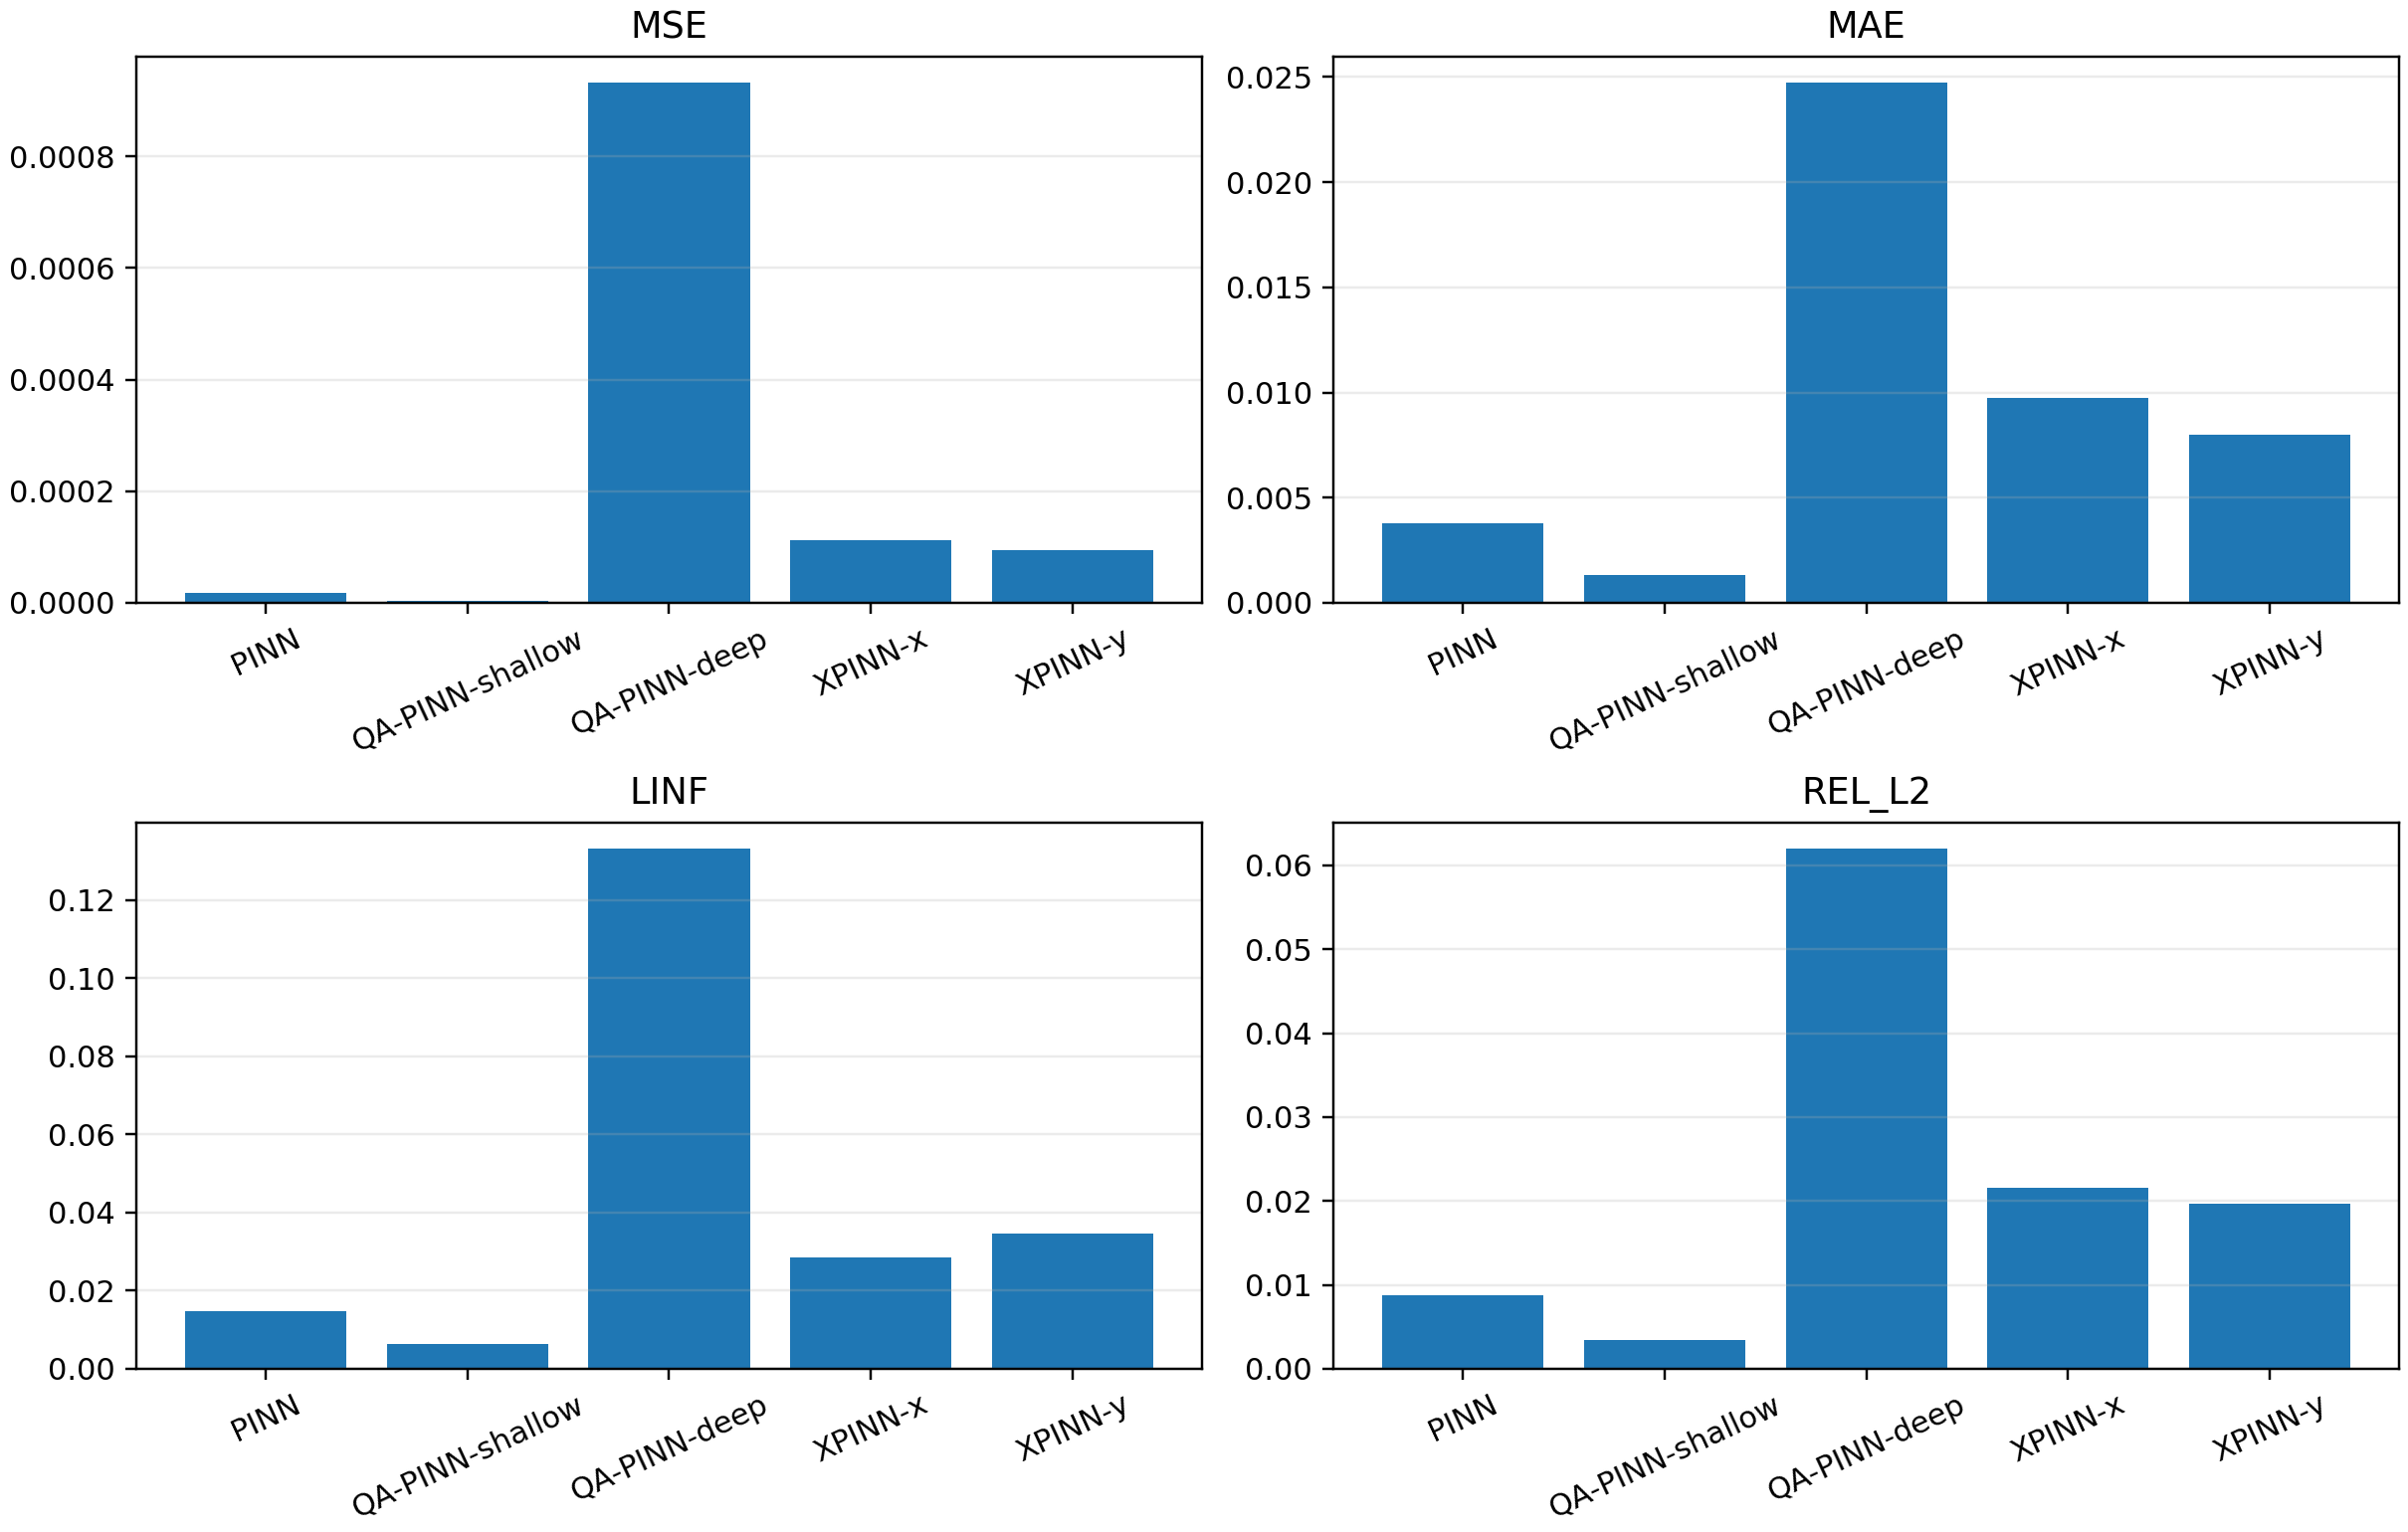

poisson_results_five/figures/cost_comparison.png


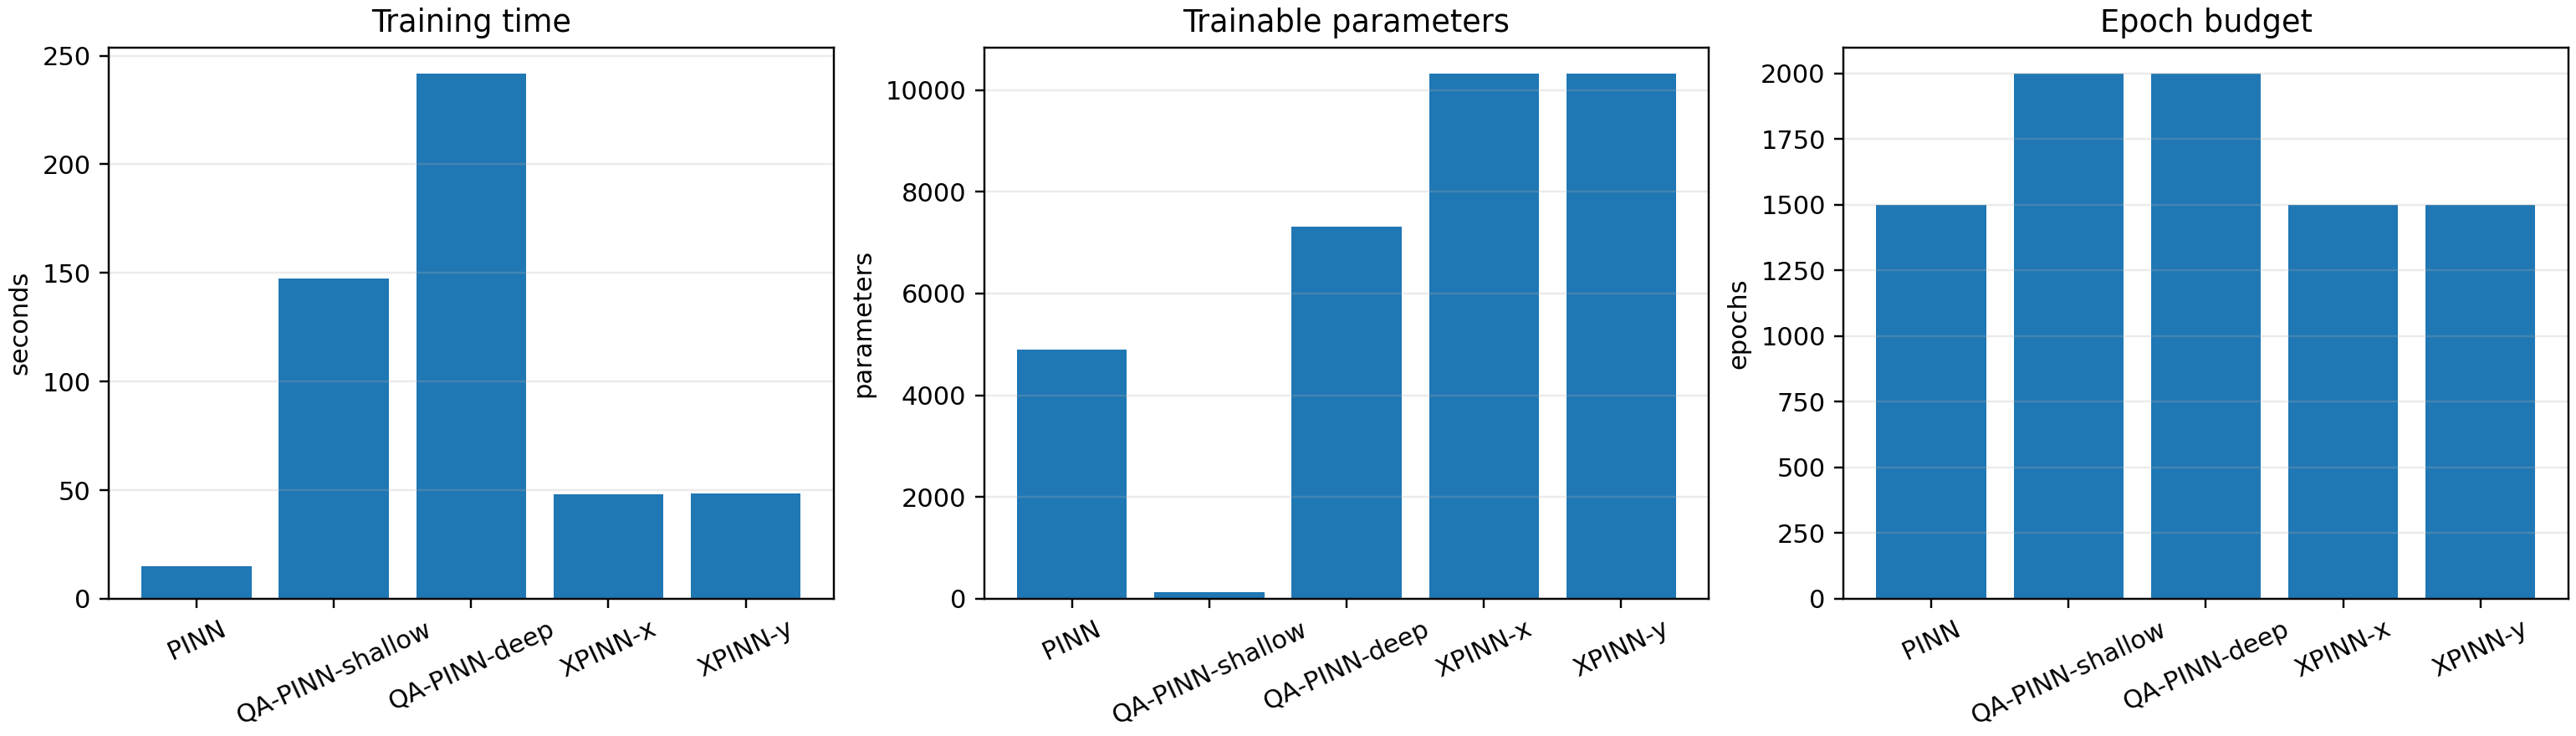

poisson_results_five/figures/relative_l2_bar.png


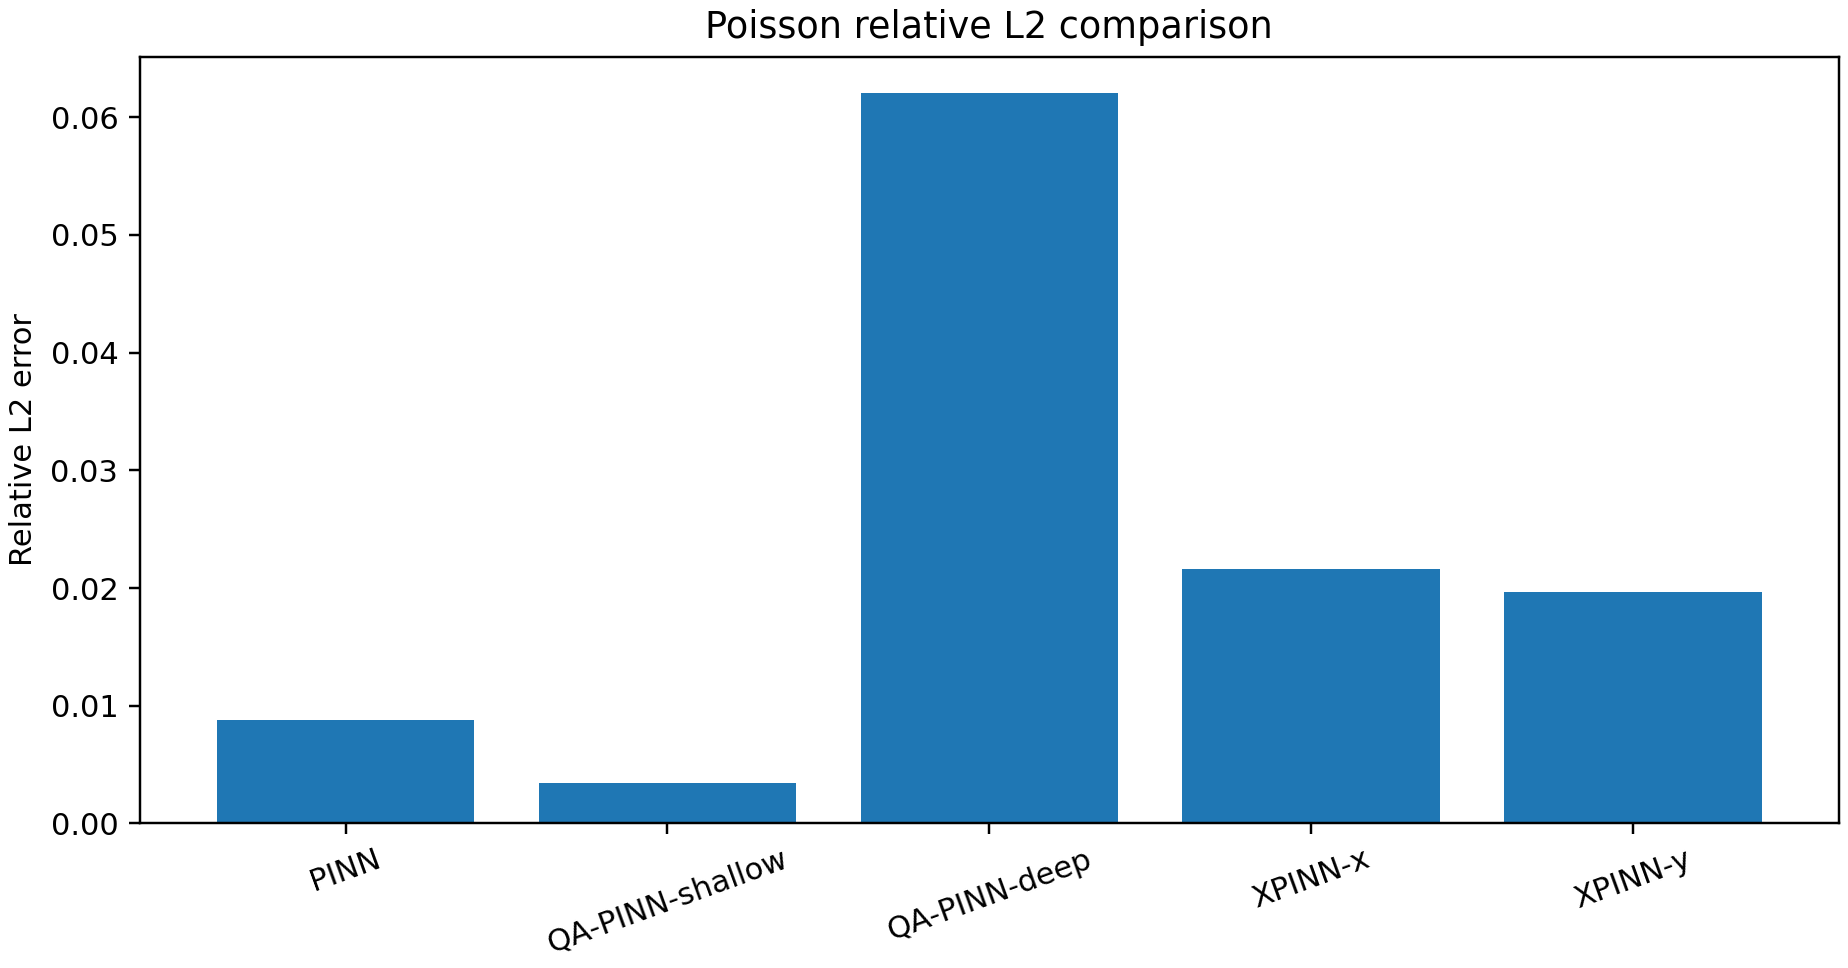

poisson_results_five/figures/centerline_comparison.png


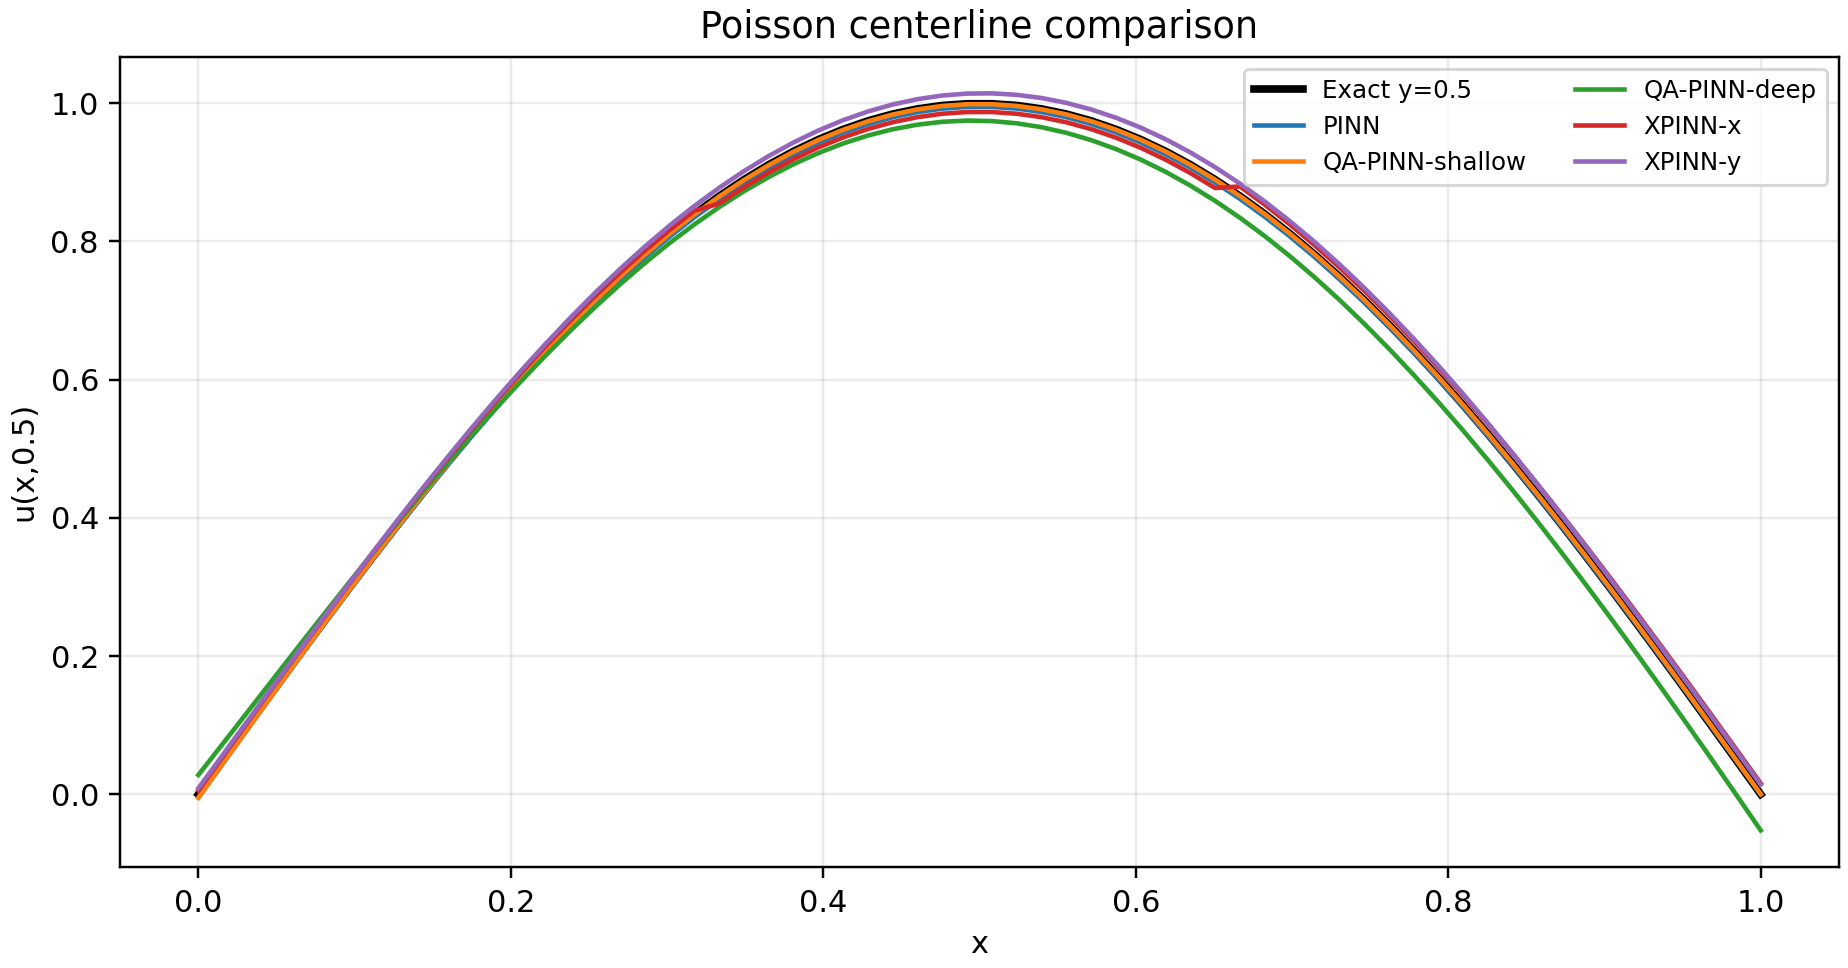

poisson_results_five/figures/centerline_error.png


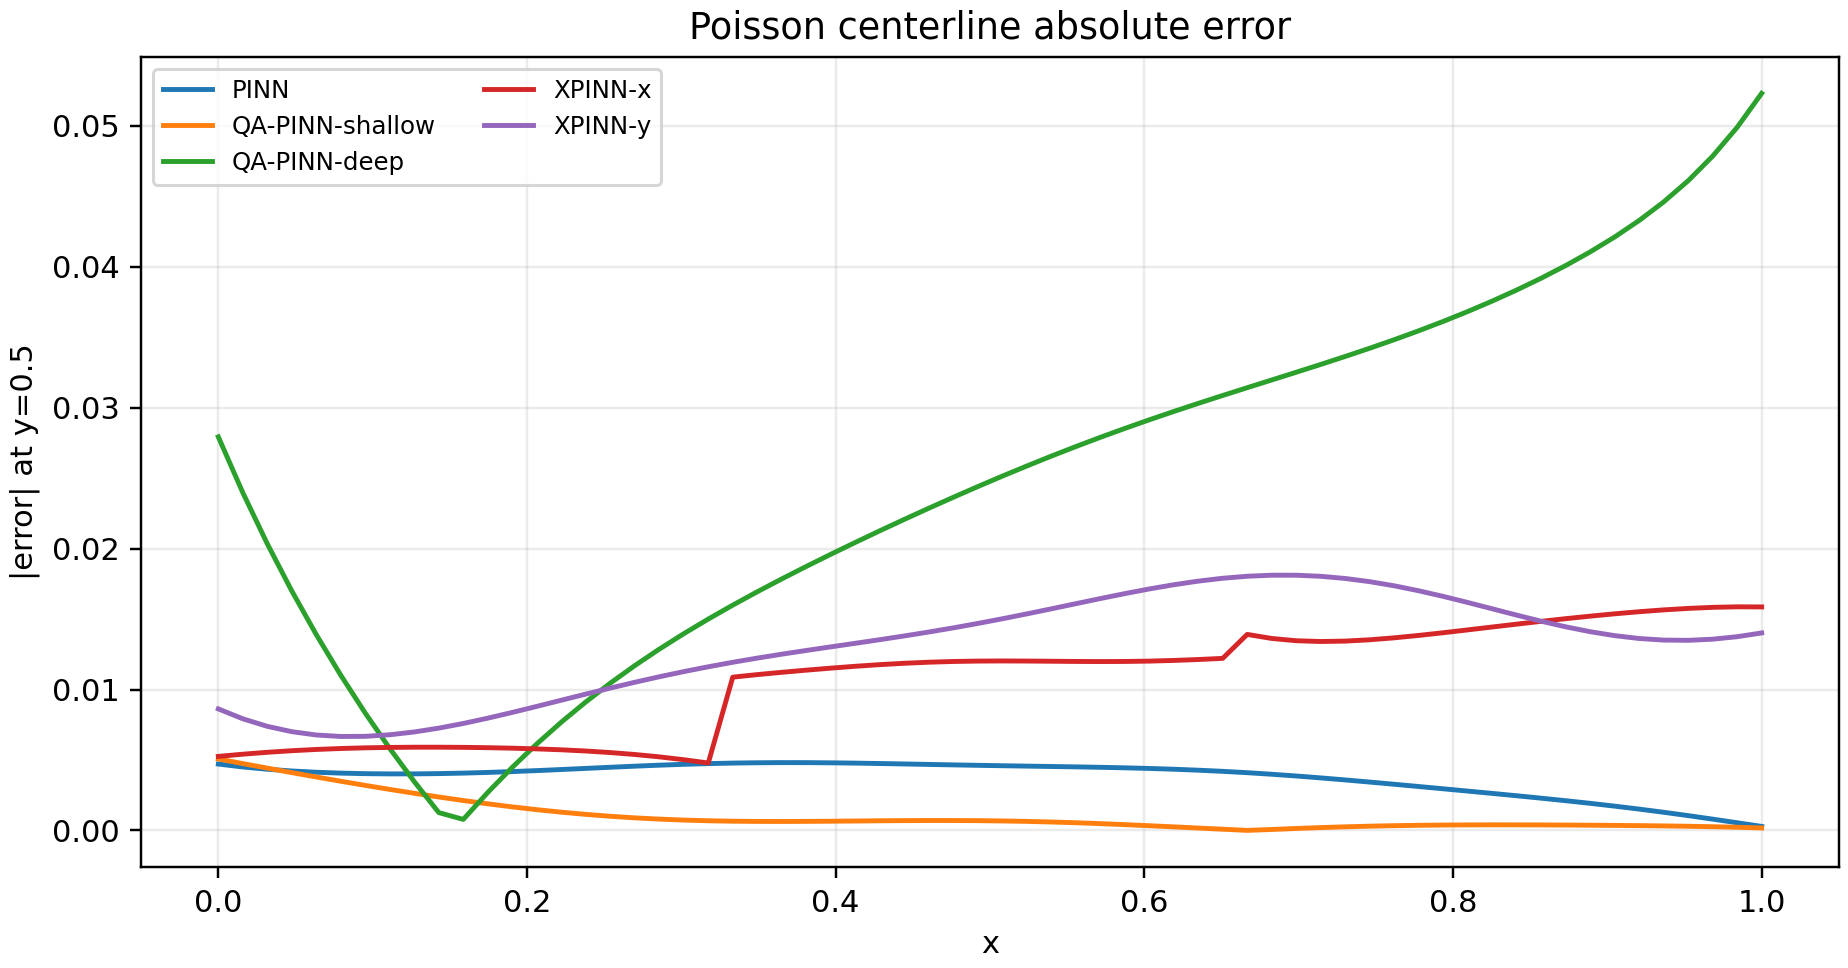

poisson_results_five/figures/summary_table.png


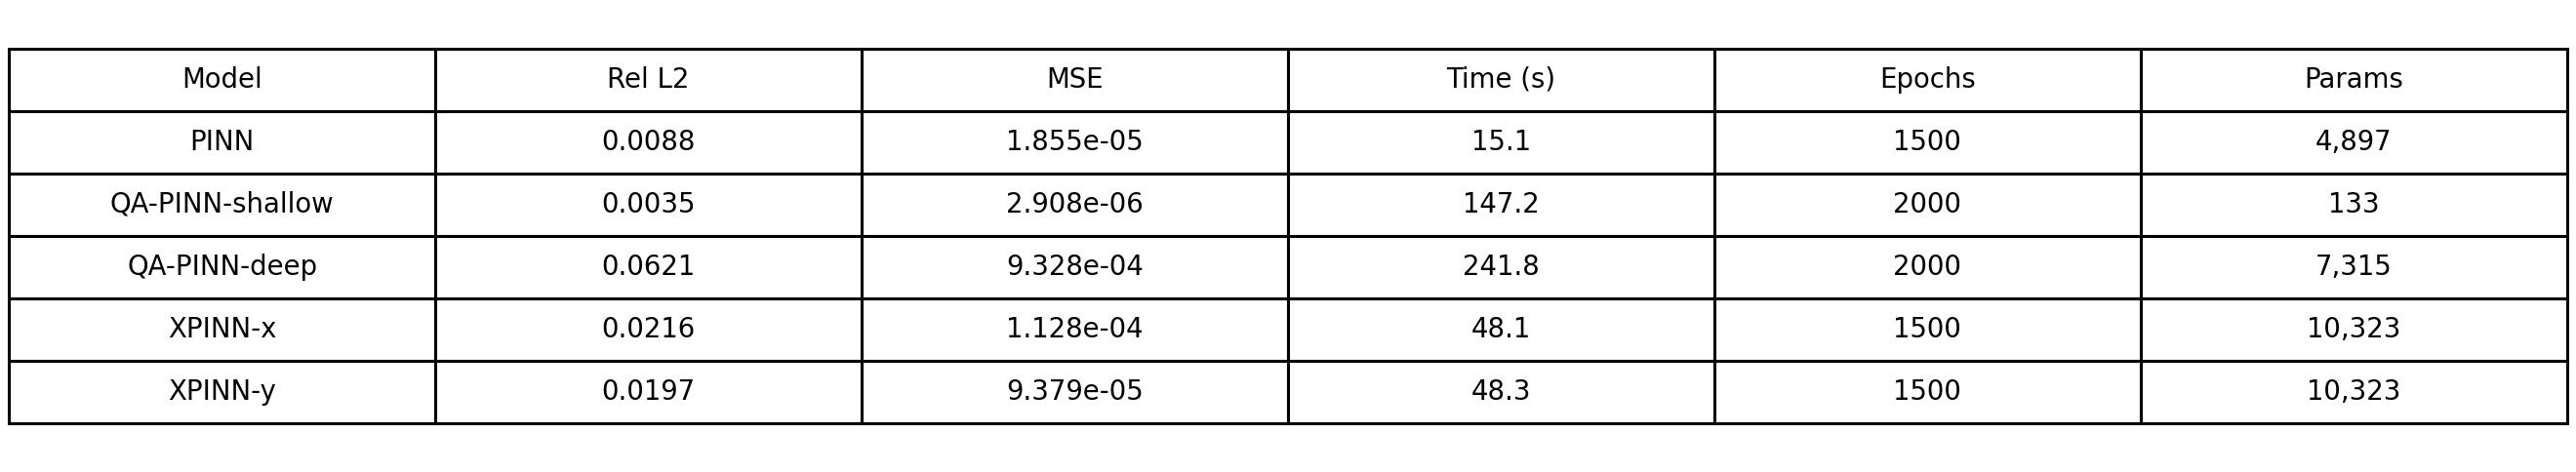

In [11]:
from IPython.display import Image, display
from pathlib import Path

plot_files = [
    'report_figures/pinn_workflow.png',
    'report_figures/bloch_sphere.png',
    'report_figures/qapinn_circuit.png',
    'report_figures/xpinn_splits.png',
    'results_five/figures/time_slice_comparison.png',
    'results_five/figures/pinn_field_error.png',
    'results_five/figures/qa-pinn-shallow_field_error.png',
    'results_five/figures/qa-pinn-deep_field_error.png',
    'results_five/figures/xpinn-time_field_error.png',
    'results_five/figures/xpinn-space_field_error.png',
    'results_five/figures/prediction_montage.png',
    'results_five/figures/loss_comparison.png',
    'results_five/figures/all_error_metrics_bar.png',
    'results_five/figures/mse_vs_time.png',
    'results_five/figures/cost_comparison.png',
    'results_five/figures/relative_l2_bar.png',
    'results_five/figures/summary_table.png',
    'poisson_results_five/figures/prediction_montage.png',
    'poisson_results_five/figures/qa_pinn_shallow_field_error.png',
    'poisson_results_five/figures/pinn_field_error.png',
    'poisson_results_five/figures/loss_comparison.png',
    'poisson_results_five/figures/all_error_metrics_bar.png',
    'poisson_results_five/figures/cost_comparison.png',
    'poisson_results_five/figures/relative_l2_bar.png',
    'poisson_results_five/figures/centerline_comparison.png',
    'poisson_results_five/figures/centerline_error.png',
    'poisson_results_five/figures/summary_table.png',
]

for file in plot_files:
    p = Path(file)
    if p.exists():
        print(file)
        display(Image(filename=str(p)))
    else:
        print(f'Missing: {file}')
